# Sydney Air Quality Forecasting with ML and XAI

## Research objective
Predict **Rozelle PM2.5 one hour ahead** and test whether additional spatial and traffic context improves forecasting.

## Scenarios
- **A:** Rozelle local air-quality, meteorology, time and historical features.
- **B:** Scenario A + neighbouring-station air-quality context.
- **C:** Scenario B + reliable traffic features that pass the TRAIN-period coverage rule.

## Methodology
The notebook follows:

```text
EDA → leakage-safe preprocessing → feature engineering
→ A/B/C comparison → tuning → final evaluation → SHAP
```

Missing-value and extreme-value decisions are supported by TRAIN/VALIDATION evidence rather than assumed in advance.

## 1. Setup and reproducibility

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

HAS_XGBOOST = True
XGBOOST_ERROR = None
try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except Exception as error:
    HAS_XGBOOST = False
    XGBOOST_ERROR = error

HAS_TF = True
TENSORFLOW_ERROR = None
try:
    import tensorflow as tf
    from keras import Sequential
    from keras.layers import Input, LSTM, GRU, Dense, Dropout
    from keras.callbacks import EarlyStopping
except Exception as error:
    HAS_TF = False
    TENSORFLOW_ERROR = error

HAS_SHAP = True
try:
    import shap
except Exception:
    HAS_SHAP = False

HAS_SCIPY = True
try:
    from scipy.stats import ttest_rel, wilcoxon
except Exception:
    HAS_SCIPY = False

print("XGBoost available:", HAS_XGBOOST)
print("TensorFlow available:", HAS_TF)
if not HAS_TF:
    print("TensorFlow error:", repr(TENSORFLOW_ERROR))
print("SHAP available:", HAS_SHAP)
print("SciPy available:", HAS_SCIPY)

XGBoost available: True
TensorFlow available: True
SHAP available: True
SciPy available: True


## 2. Project configuration

In [2]:
base_dir = Path(".")
processed_dir = base_dir / "data" / "processed"
traffic_dir = base_dir / "data" / "context" / "traffic" / "processed"
exports_dir = base_dir / "data" / "exports" / "research_final_all_predictors"
exports_dir.mkdir(parents=True, exist_ok=True)

TARGET_STATION = "ROZELLE"
NEIGHBOUR_STATIONS = [
    "RANDWICK",
    "LIVERPOOL",
    "ST_MARYS",
    "BRINGELLY",
    "RICHMOND",
]

ALL_STATIONS = [TARGET_STATION] + NEIGHBOUR_STATIONS

RAW_PREDICTOR_VARS = [
    "PM25", "PM10", "NO2", "O3", "CO",
    "TEMP", "HUMID", "WSP", "WDR", "RAIN", "SOLAR",
]

# IQR screening is limited to pollutants + ordinary meteorology.
# WDR is circular; RAIN/SOLAR are strongly zero/season-structured,
# so they use validity + missingness checks instead of the same IQR rule.
IQR_AUDIT_VARS = ["PM25", "PM10", "NO2", "O3", "CO", "TEMP", "HUMID", "WSP"]

STATION_FILES = {
    "ROZELLE": "ROZELLE_2019_2024.csv",
    "RANDWICK": "RANDWICK_2019_2024.csv",
    "LIVERPOOL": "LIVERPOOL_2019_2024.csv",
    "ST_MARYS": "ST_MARYS_2019_2024.csv",
    "BRINGELLY": "BRINGELLY_2019_2024.csv",
    "RICHMOND": "RICHMOND_2019_2024.csv",
}

CORE_VARS = [
    "PM25",
    "PM10",
    "NO2",
    "O3",
    "TEMP",
    "HUMID",
    "WSP",
    "WDR",
]

TARGET_VAR = "PM25"
TARGET_RAW_COL = f"{TARGET_STATION}_{TARGET_VAR}"
FORECAST_HORIZON = 1

LAG_SET = [1, 3, 6, 12, 24]
ROLL_SET = [3, 6, 12, 24]

TRAIN_END = pd.Timestamp("2022-12-31 23:00:00")
VAL_END = pd.Timestamp("2023-12-31 23:00:00")

# ---------------------------------------------------------------------
# Reproducibility / repeated runs
# ---------------------------------------------------------------------

# Final paper: RF/XGBoost results use 30 independent random-seed runs.
# Set PAPER_MODE=False only for a shorter development run.
FINAL_PAPER_RUNS = 30
PAPER_MODE = True

SEEDS = (
    list(range(1, FINAL_PAPER_RUNS + 1))
    if PAPER_MODE
    else [7, 21, 42, 77, 99]
)

# ---------------------------------------------------------------------
# Missing-data handling
# ---------------------------------------------------------------------

SHORT_GAP_METHOD = "ffill"
SHORT_GAP_LIMIT_HOURS = 3

HIGH_MISSING_THRESHOLD = 0.40

# Scenario C only keeps traffic locations with at least this much
# observed hourly data.
# This is a data-quality rule, not a manual choice based on performance.
TRAFFIC_MIN_COVERAGE = 0.80

# Remaining missing X values:
# "seasonal" = hour-of-week training median
# "median"   = global training median
IMPUTATION_STRATEGY = "seasonal"

# ---------------------------------------------------------------------
# Feature redundancy
# ---------------------------------------------------------------------

APPLY_CORRELATION_PRUNING = True
HIGH_CORRELATION_THRESHOLD = 0.98


# ---------------------------------------------------------------------
# Extreme-event audit
# ---------------------------------------------------------------------

# 1.5 × IQR is used only to FLAG candidate extremes for investigation.
# It is not an automatic deletion rule.
EXTREME_IQR_FACTOR = 1.5
EXTREME_EVENT_PLOTS = 3
EXTREME_EVENT_WINDOW_HOURS = 6

# High-PM2.5 regression diagnostic uses a threshold learned from TRAIN only.
HIGH_PM25_EVAL_QUANTILE = 0.95

# NSW one-hour PM2.5 threshold for the Poor-or-worse air-quality category.
NSW_PM25_ALERT_THRESHOLD = 50.0
NSW_AQC_SOURCE_URL = (
    "https://www.airquality.nsw.gov.au/health-advice/"
    "air-quality-categories"
)

# ---------------------------------------------------------------------
# Isolated-extreme treatment sensitivity
# ---------------------------------------------------------------------

# The treatment is chosen before hyperparameter tuning.
# Same fixed RF, same seeds, same 2023 validation; only preprocessing changes.
OUTLIER_SENSITIVITY_SEEDS = [7, 21, 42]
OUTLIER_SENSITIVITY_RF = {
    "n_estimators": 200,
    "max_depth": 12,
    "min_samples_leaf": 2,
}

# ---------------------------------------------------------------------
# Deep-learning scaling sensitivity
# ---------------------------------------------------------------------

# Large valid pollution peaks may influence mean/std scaling.
# StandardScaler vs RobustScaler is therefore selected using VALIDATION evidence.
DEEP_SCALER_CANDIDATES = ["standard", "robust"]
DEEP_SCALER = "standard"

# ---------------------------------------------------------------------
# Hybrid model
# ---------------------------------------------------------------------

# Paper-aligned architecture:
# Random Forest forecast -> residual -> ARIMA residual correction.
RUN_HYBRID_MODEL = True
HYBRID_ARIMA_ORDERS = [
    (1, 0, 0), (1, 0, 1), (2, 0, 0), (2, 0, 1),
    (1, 1, 0), (1, 1, 1), (2, 1, 0), (2, 1, 1),
]

# ---------------------------------------------------------------------
# Tree-model hyperparameter tuning
# ---------------------------------------------------------------------

# Hyperparameter tuning is performed on TRAIN -> VALIDATION only.
# 2024 test data are not used to select model settings.
RUN_HYPERPARAMETER_TUNING = True
TUNING_SEED = 42

# Small, transparent search grids.
RF_PARAM_GRID = {
    "n_estimators": [200, 300],
    "max_depth": [12, 16],
    "min_samples_leaf": [1, 2],
}

XGB_PARAM_GRID = {
    "n_estimators": [300, 450],
    "learning_rate": [0.03, 0.05],
    "max_depth": [4, 6],
}

# Fixed settings that are not searched.
RF_MAX_FEATURES = 0.7

XGB_SUBSAMPLE = 0.9
XGB_COLSAMPLE = 0.9

# ---------------------------------------------------------------------
# Deep learning
# ---------------------------------------------------------------------

RUN_DEEP_LEARNING = HAS_TF

# 24-hour sequence is kept fixed because it is supported by:
# - the Rozelle ACF analysis
# - the reference neighbouring-air-quality study
SEQUENCE_LENGTH = 24

# Maximum training epochs.
# EarlyStopping may stop before this.
DEEP_EPOCHS = 30

# Fallback only if deep hyperparameter tuning is disabled.
DEEP_BATCH_SIZE = 128

# Final LSTM / GRU repeated runs.
# The same seeds are used across A/B/C so scenario comparisons are paired.
DEEP_FINAL_RUNS = 30

DEEP_SEEDS = (
    list(range(1, DEEP_FINAL_RUNS + 1))
    if PAPER_MODE
    else [7, 21, 42]
)

# Persistent checkpoints. exports_dir must point to Google Drive.
DEEP_CHECKPOINT_DIR = exports_dir / "deep_30_seed_checkpoints"
DEEP_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DEEP_RESULTS_FILE = DEEP_CHECKPOINT_DIR / "deep_model_runs.csv"
DEEP_HISTORY_FILE = DEEP_CHECKPOINT_DIR / "deep_training_histories.csv"
DEEP_PREDICTION_DIR = DEEP_CHECKPOINT_DIR / "predictions"
DEEP_PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

print("Deep-learning seeds:", DEEP_SEEDS)
print("Deep checkpoint directory:", DEEP_CHECKPOINT_DIR.resolve())

# ---------------------------------------------------------------------
# Deep-learning hyperparameter tuning
# ---------------------------------------------------------------------

# Tune LSTM and GRU using TRAIN -> VALIDATION only.
# Test data are never used to select neural-network parameters.
RUN_DEEP_HYPERPARAMETER_TUNING = True

# 2 units
# × 2 dropout values
# × 2 learning rates
# × 2 batch sizes
# = 16 candidates per model
DEEP_PARAM_GRID = {
    "units": [32, 64],
    "dropout": [0.1, 0.2],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [64, 128],
}

# Keep dense layer fixed so the search remains practical.
DEEP_DENSE_UNITS = 32

# Stop if validation loss does not improve for this many epochs.
DEEP_PATIENCE = 5

# Use one fixed seed during tuning so candidate architectures
# are compared under the same random initialization condition.
DEEP_TUNING_SEED = 42

# ---------------------------------------------------------------------
# Learning-curve / SHAP robustness
# ---------------------------------------------------------------------

# Learning curves and SHAP are expensive.
# Development mode uses fewer seeds.
LEARNING_CURVE_SEEDS = (
    SEEDS
    if PAPER_MODE
    else [7, 21, 42]
)

SHAP_SEEDS = (
    SEEDS
    if PAPER_MODE
    else [7, 21, 42]
)

Deep-learning seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Deep checkpoint directory: C:\Users\MSI\Desktop\Research Perp\Code\data\exports\research_final_all_predictors\deep_30_seed_checkpoints


## 3. Data preparation helpers

In [3]:
def clean_col_name(name: str) -> str:
    name = str(name).strip().upper()
    name = re.sub(r"\s+", "_", name)
    for ch in ["/", "-", "(", ")", "[", "]", ".", "°"]:
        name = name.replace(ch, "_" if ch in ["/", "-"] else "")
    return name

def normalise_station_label(text: str) -> str:
    text = str(text).upper().strip()
    text = text.replace("ST MARYS", "ST_MARYS")
    text = text.replace("ST._MARYS", "ST_MARYS")
    text = text.replace("ST-MARYS", "ST_MARYS")
    return text

def canonical_var_name(col: str, station: str):
    c = normalise_station_label(clean_col_name(col))
    s = normalise_station_label(station)
    if s in c:
        c = c.replace(s, "")
    c = c.strip("_")
    patterns = [
        (r"PM25|PM2_5", "PM25"), (r"PM10", "PM10"), (r"NO2", "NO2"),
        (r"(^|_)O3($|_)|OZONE", "O3"),
        (r"TEMP|TEMPERATURE|AIR_TEMPERATURE", "TEMP"),
        (r"HUMID|RELATIVE_HUMIDITY", "HUMID"),
        (r"WSP|WIND_SPEED", "WSP"), (r"WDR|WIND_DIRECTION", "WDR"),
        (r"(^|_)CO($|_)|CARBON_MONOXIDE", "CO"),
        (r"RAIN|RAINFALL", "RAIN"), (r"SOLAR|GLOBAL_SOLAR_RADIATION", "SOLAR"),
    ]
    for pattern, canonical in patterns:
        if re.search(pattern, c):
            return canonical
    return None

def load_station_csv(station: str, file_path: Path) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    df.columns = [clean_col_name(c) for c in df.columns]
    if "DATETIME" in df.columns:
        df["DATETIME"] = pd.to_datetime(df["DATETIME"], errors="coerce")
    elif "DATE" in df.columns and "TIME" in df.columns:
        dt_text = df["DATE"].astype(str).str.strip() + " " + df["TIME"].astype(str).str.strip()
        df["DATETIME"] = pd.to_datetime(dt_text, errors="coerce", dayfirst=True)
    else:
        raise ValueError(f"{file_path.name} must contain DATETIME or DATE + TIME")
    df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").drop_duplicates("DATETIME").reset_index(drop=True)
    keep = {"DATETIME"}; rename_map = {}
    for col in df.columns:
        if col in {"DATETIME", "DATE", "TIME", "STATION", "YEAR"}:
            continue
        canonical = canonical_var_name(col, station)
        if canonical is not None:
            rename_map[col] = f"{station}_{canonical}"
            keep.add(col)
    out = df[list(keep)].rename(columns=rename_map).copy()
    out["STATION"] = station
    return out

POLLUTANT_TOKENS = ("PM25", "PM10", "NO2", "O3", "_CO", "SO2")
NON_NEGATIVE_TOKENS = POLLUTANT_TOKENS + ("WSP", "RAIN", "SOLAR")

def apply_physical_validity_checks(df):
    """Convert only definitionally impossible measurements to missing."""
    out = df.copy()
    changed = {}

    for col in out.select_dtypes(include=[np.number]).columns:
        bad = pd.Series(False, index=out.index)

        if any(token in col for token in NON_NEGATIVE_TOKENS):
            bad |= out[col] < 0

        if col.endswith("_HUMID"):
            bad |= (out[col] < 0) | (out[col] > 100)

        if col.endswith("_WDR"):
            bad |= (out[col] < 0) | (out[col] > 360)

        if int(bad.sum()):
            changed[col] = int(bad.sum())
            out.loc[bad, col] = np.nan

    return out, changed

def fill_short_time_gaps(df, method="ffill", limit=3, exclude_columns=None):
    """
    Fill only complete missing runs whose length is <= limit.
    Longer gaps remain entirely missing.
    """
    out = df.sort_values("DATETIME").copy()
    exclude = set(exclude_columns or [])
    numeric_cols = [
        c for c in out.select_dtypes(include=[np.number]).columns
        if c not in exclude
    ]

    rows = []

    for col in numeric_cols:
        original = out[col].copy()
        missing = original.isna()
        groups = (missing != missing.shift()).cumsum()
        run_length = missing.groupby(groups).transform("sum")
        short_gap = missing & (run_length <= limit)

        if method == "ffill":
            candidate = original.ffill()
        elif method == "interpolate":
            candidate = (
                pd.Series(
                    original.to_numpy(),
                    index=out["DATETIME"],
                    dtype=float,
                )
                .interpolate(method="time", limit_area="inside")
                .set_axis(out.index)
            )
        elif method == "none":
            candidate = original
        else:
            raise ValueError("method must be ffill, interpolate or none")

        out.loc[short_gap, col] = candidate.loc[short_gap]

        rows.append({
            "column": col,
            "missing_before": int(missing.sum()),
            "filled_short_gaps": int(
                (original.isna() & out[col].notna()).sum()
            ),
            "missing_after": int(out[col].isna().sum()),
        })

    report = (
        pd.DataFrame(rows)
        .sort_values("missing_after", ascending=False)
        .reset_index(drop=True)
    )

    return out, report

def missing_run_lengths(series):
    is_missing = series.isna()
    groups = (is_missing != is_missing.shift()).cumsum()
    lengths = is_missing.groupby(groups).sum()
    return lengths[lengths > 0].astype(int)

def chronological_split(df, horizon=FORECAST_HORIZON):
    """Split by TARGET time so a t+1 target never crosses a data boundary."""
    target_time = df["DATETIME"] + pd.to_timedelta(
        horizon,
        unit="h",
    )

    train = df[target_time <= TRAIN_END].copy()

    val = df[
        (target_time > TRAIN_END)
        & (target_time <= VAL_END)
    ].copy()

    test = df[target_time > VAL_END].copy()

    return train, val, test


### 3.1 Feature engineering helpers

In [4]:
def add_time_features(df):
    out = df.copy(); dt = out["DATETIME"]
    out["HOUR"] = dt.dt.hour; out["DAY_OF_WEEK"] = dt.dt.dayofweek
    out["MONTH"] = dt.dt.month; out["DAY_OF_YEAR"] = dt.dt.dayofyear
    out["IS_WEEKEND"] = (dt.dt.dayofweek >= 5).astype(int)
    out["HOUR_SIN"] = np.sin(2*np.pi*out["HOUR"]/24); out["HOUR_COS"] = np.cos(2*np.pi*out["HOUR"]/24)
    out["DOW_SIN"] = np.sin(2*np.pi*out["DAY_OF_WEEK"]/7); out["DOW_COS"] = np.cos(2*np.pi*out["DAY_OF_WEEK"]/7)
    out["MONTH_SIN"] = np.sin(2*np.pi*out["MONTH"]/12); out["MONTH_COS"] = np.cos(2*np.pi*out["MONTH"]/12)
    return out

def add_wind_direction_encoding(df, stations):
    out = df.copy()
    for st in stations:
        col = f"{st}_WDR"
        if col in out.columns:
            rad = np.deg2rad(out[col] % 360)
            out[f"{st}_WDR_SIN"] = np.sin(rad); out[f"{st}_WDR_COS"] = np.cos(rad)
    return out

def add_basic_rolling(df, cols, windows):
    out = df.copy()
    for col in cols:
        if col not in out.columns: continue
        for w in windows:
            # Window ends at t; it never uses t+1.
            out[f"{col}_ROLL_MEAN_{w}"] = out[col].rolling(w, min_periods=1).mean()
            out[f"{col}_ROLL_STD_{w}"] = out[col].rolling(w, min_periods=2).std()
    return out

def add_lags(df, cols, lags):
    out = df.copy()
    for col in cols:
        if col not in out.columns: continue
        for lag in lags:
            out[f"{col}_LAG_{lag}"] = out[col].shift(lag)
    return out

def add_neighbour_aggregates(df, neighbours, vars_to_use):
    out = df.copy()
    for v in vars_to_use:
        cols = [f"{st}_{v}" for st in neighbours if f"{st}_{v}" in out.columns]
        if cols:
            out[f"NEIGHBOR_MEAN_{v}"] = out[cols].mean(axis=1)
            out[f"NEIGHBOR_MAX_{v}"] = out[cols].max(axis=1)
            out[f"NEIGHBOR_MIN_{v}"] = out[cols].min(axis=1)
            out[f"NEIGHBOR_STD_{v}"] = out[cols].std(axis=1)
    return out

def add_wind_conditioned_neighbour_features(df):
    out = df.copy()
    if "NEIGHBOR_MEAN_PM25" in out.columns and "ROZELLE_WSP" in out.columns:
        out["NEIGHBOR_PM25_X_ROZELLE_WSP"] = out["NEIGHBOR_MEAN_PM25"] * out["ROZELLE_WSP"]
    if "NEIGHBOR_MEAN_PM25" in out.columns and "ROZELLE_WDR_SIN" in out.columns:
        out["NEIGHBOR_PM25_X_ROZELLE_WDR_SIN"] = out["NEIGHBOR_MEAN_PM25"] * out["ROZELLE_WDR_SIN"]
    if "NEIGHBOR_MEAN_PM25" in out.columns and "ROZELLE_WDR_COS" in out.columns:
        out["NEIGHBOR_PM25_X_ROZELLE_WDR_COS"] = out["NEIGHBOR_MEAN_PM25"] * out["ROZELLE_WDR_COS"]
    return out

def add_target(df, observed_target_col, horizon=1):
    out = df.copy(); out["TARGET_T_PLUS_1"] = out[observed_target_col].shift(-horizon); return out

### 3.2 Training-only per-feature imputation

Each predictor uses either a global median or an hour-of-week median. Section 6.1 selects the lower validation reconstruction RMSE separately for each feature.

All medians are fitted on **2019–2022 TRAIN only** and then applied to 2023 validation and 2024 test data. The target is never imputed.


In [5]:
class PerFeatureMedianImputer(BaseEstimator, TransformerMixin):
    """
    Fill each feature with the validation-selected method:
      - median
      - hour-of-week median

    Derived features inherit the method of their raw source when possible.
    """
    def __init__(self, strategy_by_feature=None, fallback="median"):
        self.strategy_by_feature = strategy_by_feature or {}
        self.fallback = fallback

    def fit(self, X, y=None):
        X = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        self.columns_ = list(X.columns)
        self.global_medians_ = X.median(numeric_only=True)
        self.group_medians_ = {}

        if {"HOUR", "DAY_OF_WEEK"}.issubset(X.columns):
            key = X["DAY_OF_WEEK"] * 24 + X["HOUR"]
            for col in self.columns_:
                if pd.api.types.is_numeric_dtype(X[col]):
                    self.group_medians_[col] = X[col].groupby(key).median()

        return self

    def _strategy_for(self, col):
        if col in self.strategy_by_feature:
            return self.strategy_by_feature[col]

        # Lag/rolling features inherit the raw predictor's selected method.
        matches = [
            raw for raw in self.strategy_by_feature
            if col.startswith(raw + "_")
        ]
        if matches:
            return self.strategy_by_feature[max(matches, key=len)]

        return self.fallback

    def transform(self, X):
        out = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.columns_)

        key = None
        if {"HOUR", "DAY_OF_WEEK"}.issubset(out.columns):
            key = out["DAY_OF_WEEK"] * 24 + out["HOUR"]

        for col in self.columns_:
            if col not in out.columns or not pd.api.types.is_numeric_dtype(out[col]):
                continue

            if (
                self._strategy_for(col) == "seasonal"
                and key is not None
                and col in self.group_medians_
            ):
                out[col] = out[col].fillna(key.map(self.group_medians_[col]))

            out[col] = out[col].fillna(self.global_medians_.get(col, np.nan))

        return out


def build_imputer(strategy=None):
    """Return the selected imputer without using 2024 test information."""
    if strategy == "seasonal":
        return PerFeatureMedianImputer({}, fallback="seasonal")
    if strategy == "median":
        return PerFeatureMedianImputer({}, fallback="median")

    selected = globals().get("SELECTED_IMPUTATION_BY_FEATURE", {})
    fallback = globals().get("GLOBAL_FALLBACK_IMPUTATION", IMPUTATION_STRATEGY)

    return PerFeatureMedianImputer(
        strategy_by_feature=selected,
        fallback=fallback,
    )

## 4. Load data

In [6]:
station_data = {}; availability_rows = []
for station, filename in STATION_FILES.items():
    path = processed_dir / filename
    if not path.exists(): raise FileNotFoundError(f"Missing station file: {path}")
    df = load_station_csv(station, path); station_data[station] = df
    for col in df.columns:
        if col in {"DATETIME","STATION"}: continue
        availability_rows.append({"station":station,"feature":col,"missing_pct":df[col].isna().mean()*100,"start":df["DATETIME"].min(),"end":df["DATETIME"].max()})
    print(f"{station}: {len(df):,} rows | {df['DATETIME'].min()} to {df['DATETIME'].max()}")
availability_df = pd.DataFrame(availability_rows)
availability_df.to_csv(exports_dir / "raw_station_availability.csv", index=False)

ROZELLE: 50,416 rows | 2019-01-01 01:00:00 to 2024-12-31 23:00:00
RANDWICK: 50,416 rows | 2019-01-01 01:00:00 to 2024-12-31 23:00:00
LIVERPOOL: 50,416 rows | 2019-01-01 01:00:00 to 2024-12-31 23:00:00
ST_MARYS: 50,416 rows | 2019-01-01 01:00:00 to 2024-12-31 23:00:00
BRINGELLY: 50,416 rows | 2019-01-01 01:00:00 to 2024-12-31 23:00:00
RICHMOND: 50,416 rows | 2019-01-01 01:00:00 to 2024-12-31 23:00:00


## 5. Data visualisation and analysis — BEFORE preprocessing

### Why this section comes first
Before filling, removing or transforming anything, we first look at what the sensors actually recorded.

This helps us answer simple but important questions:

- Which variables are often missing?
- Are the missing values only short gaps, or are there long periods with no data?
- Does PM2.5 change by hour, month or season?
- Are very large PM2.5 values genuine pollution events or obvious sensor errors?
- Which variables move together?
- Which variables appear related to next-hour Rozelle PM2.5?

Doing this **before preprocessing** makes later decisions easier to justify in the research paper instead of choosing a method only because it is common.

In [7]:
master_raw = station_data[TARGET_STATION].drop(columns=["STATION"]).copy()
for station in NEIGHBOUR_STATIONS:
    master_raw = master_raw.merge(station_data[station].drop(columns=["STATION"]), on="DATETIME", how="left")
master_raw = master_raw.sort_values("DATETIME").reset_index(drop=True)
ORIGINAL_TARGET_COL = f"{TARGET_STATION}_{TARGET_VAR}_ORIGINAL"
master_raw[ORIGINAL_TARGET_COL] = master_raw[f"{TARGET_STATION}_{TARGET_VAR}"]
print("Raw master:", master_raw.shape)

Raw master: (50416, 64)


### 5.1 Missingness audit

,missing_pct
ST_MARYS_CO,100.000000
RICHMOND_CO,100.000000
ST_MARYS_SOLAR,100.000000
BRINGELLY_CO,100.000000
LIVERPOOL_SOLAR,100.000000
RICHMOND_SOLAR,100.000000
RANDWICK_RAIN,63.047445
LIVERPOOL_RAIN,44.989686
BRINGELLY_NO2,10.655348
LIVERPOOL_CO,9.491035


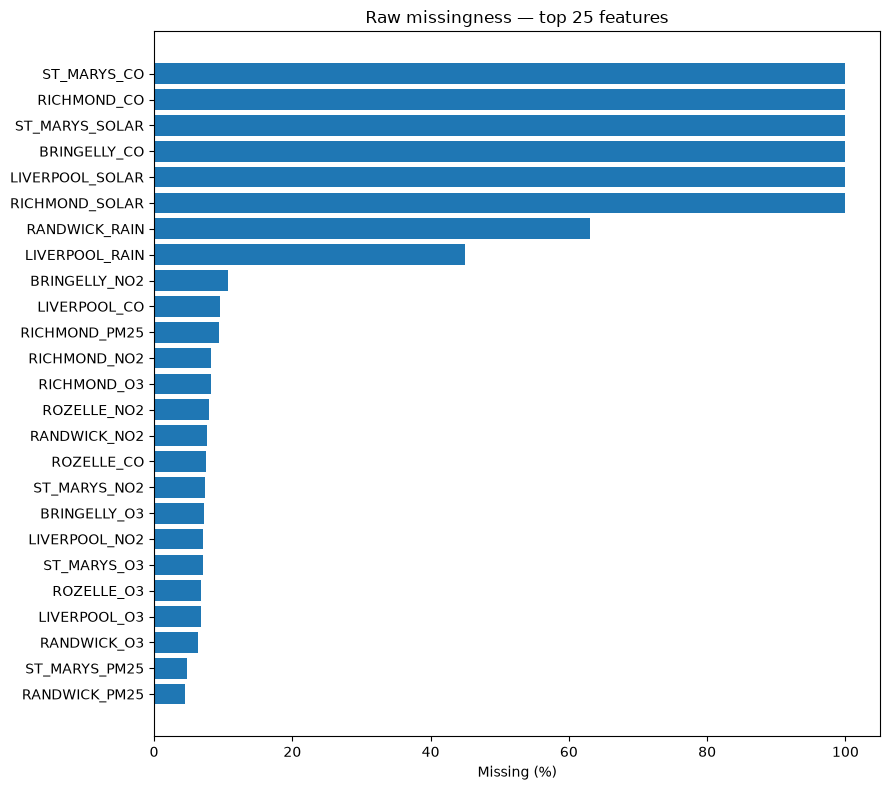

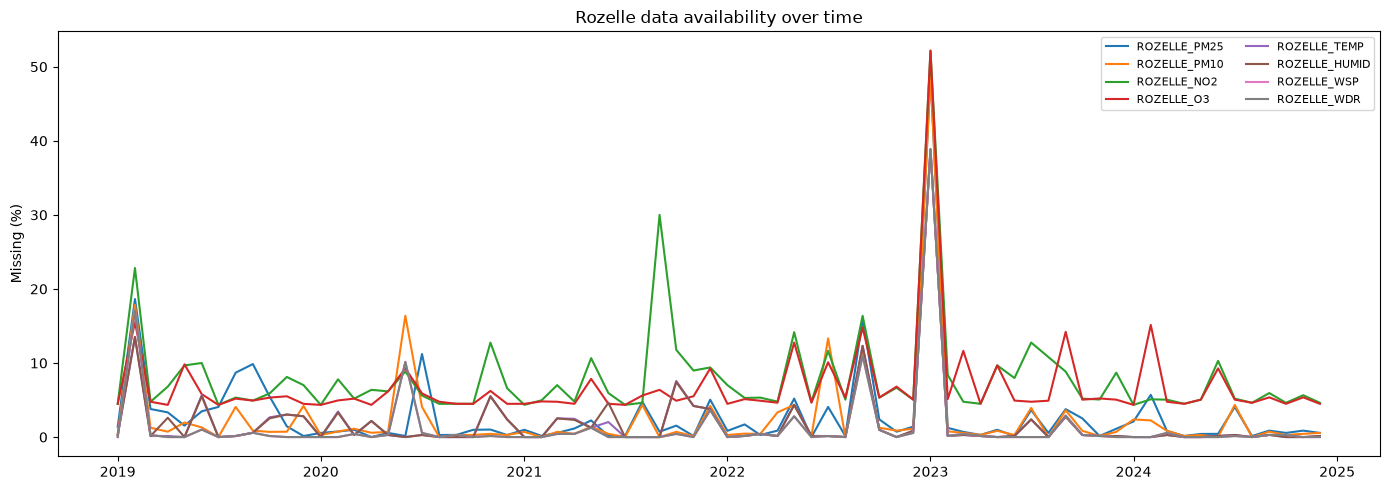

In [8]:
raw_missing = master_raw.drop(columns=["DATETIME"]).isna().mean().mul(100).sort_values(ascending=False).to_frame("missing_pct")
display(raw_missing.head(30))
raw_missing.to_csv(exports_dir / "raw_missingness_overall.csv")
plot_df = raw_missing.head(25).sort_values("missing_pct")
plt.figure(figsize=(9,8)); plt.barh(plot_df.index, plot_df["missing_pct"]); plt.xlabel("Missing (%)"); plt.title("Raw missingness — top 25 features"); plt.tight_layout(); plt.show()

monthly_missing = master_raw.set_index("DATETIME").isna().resample("MS").mean().mul(100)
core = [c for c in [f"ROZELLE_{v}" for v in CORE_VARS] if c in monthly_missing.columns]
plt.figure(figsize=(14,5))
for col in core: plt.plot(monthly_missing.index, monthly_missing[col], label=col)
plt.ylabel("Missing (%)"); plt.title("Rozelle data availability over time"); plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()

### 5.2 Missing-gap lengths — all station predictors

Gap length is checked for every available raw predictor from Rozelle and the five neighbouring stations.

This supports the preprocessing split:
- short gaps (`<= 3 h`) can be filled causally;
- longer gaps are left for the TRAIN-fitted imputer.

,feature,missing_hours,gap_count,median_gap_hours,max_gap_hours,short_gap_pct
0,LIVERPOOL_SOLAR,50416,1,50416.0,50416,0.000000
1,ST_MARYS_CO,50416,1,50416.0,50416,0.000000
2,ST_MARYS_SOLAR,50416,1,50416.0,50416,0.000000
3,BRINGELLY_CO,50416,1,50416.0,50416,0.000000
4,RICHMOND_CO,50416,1,50416.0,50416,0.000000
5,RICHMOND_SOLAR,50416,1,50416.0,50416,0.000000
6,RANDWICK_RAIN,31786,23,3.0,31431,52.173913
7,LIVERPOOL_RAIN,22682,51,1.0,22579,90.196078
8,BRINGELLY_NO2,5372,2358,1.0,580,94.020356
9,LIVERPOOL_CO,4785,2492,1.0,140,94.101124


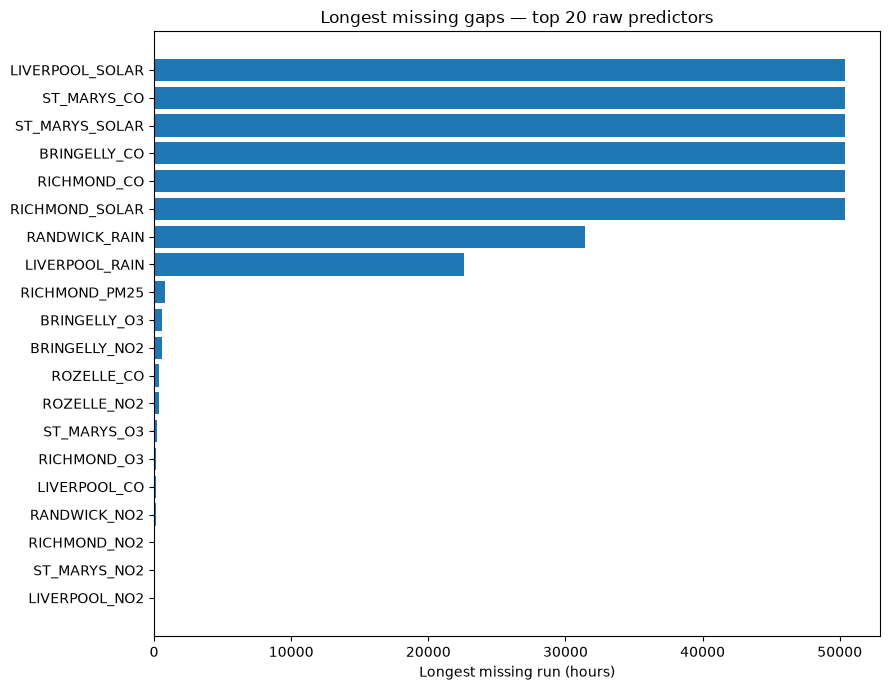

In [9]:
raw_station_predictors = [
    f"{station}_{var}"
    for station in ALL_STATIONS
    for var in RAW_PREDICTOR_VARS
    if f"{station}_{var}" in master_raw.columns
]

gap_rows = []

for col in raw_station_predictors:
    gaps = missing_run_lengths(master_raw[col])

    gap_rows.append({
        "feature": col,
        "missing_hours": int(master_raw[col].isna().sum()),
        "gap_count": int(len(gaps)),
        "median_gap_hours": float(gaps.median()) if len(gaps) else 0.0,
        "max_gap_hours": int(gaps.max()) if len(gaps) else 0,
        "short_gap_pct": float((gaps <= SHORT_GAP_LIMIT_HOURS).mean() * 100) if len(gaps) else 0.0,
    })

gap_summary = (
    pd.DataFrame(gap_rows)
    .sort_values(["missing_hours", "max_gap_hours"], ascending=False)
    .reset_index(drop=True)
)

display(gap_summary.head(30))
gap_summary.to_csv(exports_dir / "missing_gap_summary_all_predictors.csv", index=False)

plot_gap = gap_summary.head(20).sort_values("max_gap_hours")
plt.figure(figsize=(9, 7))
plt.barh(plot_gap["feature"], plot_gap["max_gap_hours"])
plt.xlabel("Longest missing run (hours)")
plt.title("Longest missing gaps — top 20 raw predictors")
plt.tight_layout()
plt.show()

### 5.3 Extreme-candidate detection — all station predictors

TRAIN-derived `1.5 × IQR` fences flag candidate extremes for available pollutants and ordinary meteorological predictors across all six stations.

This is a **screening step only**:
- pollutants are flagged on the high side;
- temperature, humidity and wind speed can be flagged on either tail;
- wind direction is circular and therefore excluded from IQR screening;
- rain/solar are not given the same IQR rule because their distributions are strongly zero/season structured.

No observation is deleted here.

,feature,station,variable,iqr_lower,iqr_upper,candidate_hours,candidate_pct
0,ROZELLE_CO,ROZELLE,CO,-0.0500,0.3500,3103,9.234295
1,ST_MARYS_PM10,ST_MARYS,PM10,-12.2000,42.2000,2083,6.198851
2,RICHMOND_PM10,RICHMOND,PM10,-9.9500,36.8500,1795,5.341785
3,LIVERPOOL_PM25,LIVERPOOL,PM25,-7.4500,22.5500,1774,5.279291
4,ROZELLE_PM25,ROZELLE,PM25,-5.5500,18.0500,1656,4.928131
5,BRINGELLY_PM10,BRINGELLY,PM10,-12.9500,43.4500,1558,4.636491
6,LIVERPOOL_PM10,LIVERPOOL,PM10,-11.0500,46.1500,1548,4.606732
7,BRINGELLY_PM25,BRINGELLY,PM25,-7.0500,21.3500,1543,4.591852
8,RICHMOND_PM25,RICHMOND,PM25,-7.8500,22.9500,1450,4.315091
9,RANDWICK_PM10,RANDWICK,PM10,-7.8500,41.3500,1393,4.145463


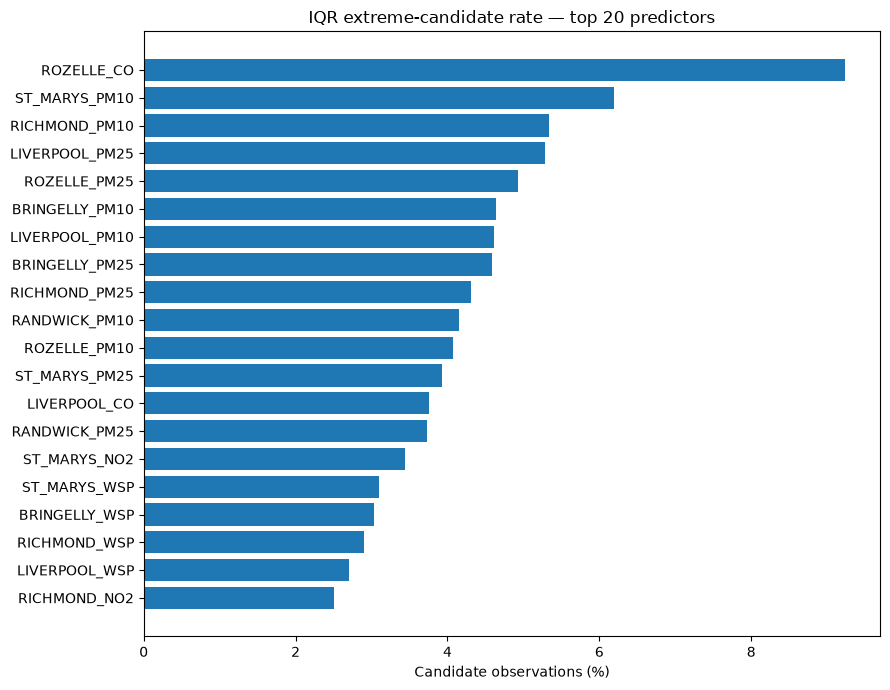

IQR flags candidates only; no value is removed here.


In [10]:
def iqr_bounds(series, factor=EXTREME_IQR_FACTOR):
    x = pd.to_numeric(series, errors="coerce").dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    return float(q1 - factor * iqr), float(q3 + factor * iqr)


def split_station_var(col):
    for station in ALL_STATIONS:
        prefix = f"{station}_"
        if col.startswith(prefix):
            return station, col[len(prefix):]
    return None, None


def extreme_direction(series, variable, bounds):
    """
    0 = not candidate
    1 = high-side candidate
   -1 = low-side candidate
    """
    lower, upper = bounds
    values = pd.to_numeric(series, errors="coerce")
    direction = pd.Series(0, index=values.index, dtype=int)

    if variable in {"PM25", "PM10", "NO2", "O3", "CO"}:
        direction.loc[values > upper] = 1
    else:
        direction.loc[values > upper] = 1
        direction.loc[values < lower] = -1

    return direction


def candidate_mask_for_column(df, col):
    if col not in EXTREME_BOUNDS:
        return pd.Series(False, index=df.index)

    _, variable = split_station_var(col)
    return extreme_direction(
        df[col],
        variable,
        EXTREME_BOUNDS[col],
    ).ne(0)


eda_extreme_source, _ = apply_physical_validity_checks(master_raw)

extreme_train_raw = (
    eda_extreme_source[
        eda_extreme_source["DATETIME"] <= TRAIN_END
    ]
    .sort_values("DATETIME")
    .reset_index(drop=True)
)

EXTREME_BOUNDS = {}
candidate_rows = []

for col in raw_station_predictors:
    station, variable = split_station_var(col)

    if variable not in IQR_AUDIT_VARS:
        continue

    observed = pd.to_numeric(
        extreme_train_raw[col],
        errors="coerce",
    ).dropna()

    if len(observed) < 50:
        continue

    bounds = iqr_bounds(observed)
    EXTREME_BOUNDS[col] = bounds
    candidate = candidate_mask_for_column(extreme_train_raw, col)

    candidate_rows.append({
        "feature": col,
        "station": station,
        "variable": variable,
        "iqr_lower": bounds[0],
        "iqr_upper": bounds[1],
        "candidate_hours": int(candidate.sum()),
        "candidate_pct": float(candidate.mean() * 100),
    })


extreme_candidate_summary = (
    pd.DataFrame(candidate_rows)
    .sort_values("candidate_pct", ascending=False)
    .reset_index(drop=True)
)

display(extreme_candidate_summary)

extreme_candidate_summary.to_csv(
    exports_dir / "extreme_candidate_summary_all_predictors.csv",
    index=False,
)

plot_candidates = (
    extreme_candidate_summary
    .head(20)
    .sort_values("candidate_pct")
)

plt.figure(figsize=(9, 7))
plt.barh(
    plot_candidates["feature"],
    plot_candidates["candidate_pct"],
)
plt.xlabel("Candidate observations (%)")
plt.title("IQR extreme-candidate rate — top 20 predictors")
plt.tight_layout()
plt.show()

print("IQR flags candidates only; no value is removed here.")

### 5.4 Temporal patterns and autocorrelation

### Why
Air quality can change with hour, month and season. We also need to know whether **previous PM2.5 values influence the next values**.

The ACF (autocorrelation function) measures the relationship between PM2.5 now and PM2.5 at earlier hourly lags. For example:

```text
lag 1  = 1 hour earlier
lag 6  = 6 hours earlier
lag 24 = 24 hours earlier
```

The plot includes the common approximate 95% white-noise boundary **±1.96/√N**. ACF bars well outside this band are clearly different from zero for descriptive purposes.

The neighbouring-air-quality study by **Ghose, Rehena & Anthopoulos (2022)** also examined ACF and reported a daily pattern around 24 hours before using the previous 24 hours to predict the next hour. We still calculate the pattern for Rozelle instead of assuming their result automatically transfers to our station.


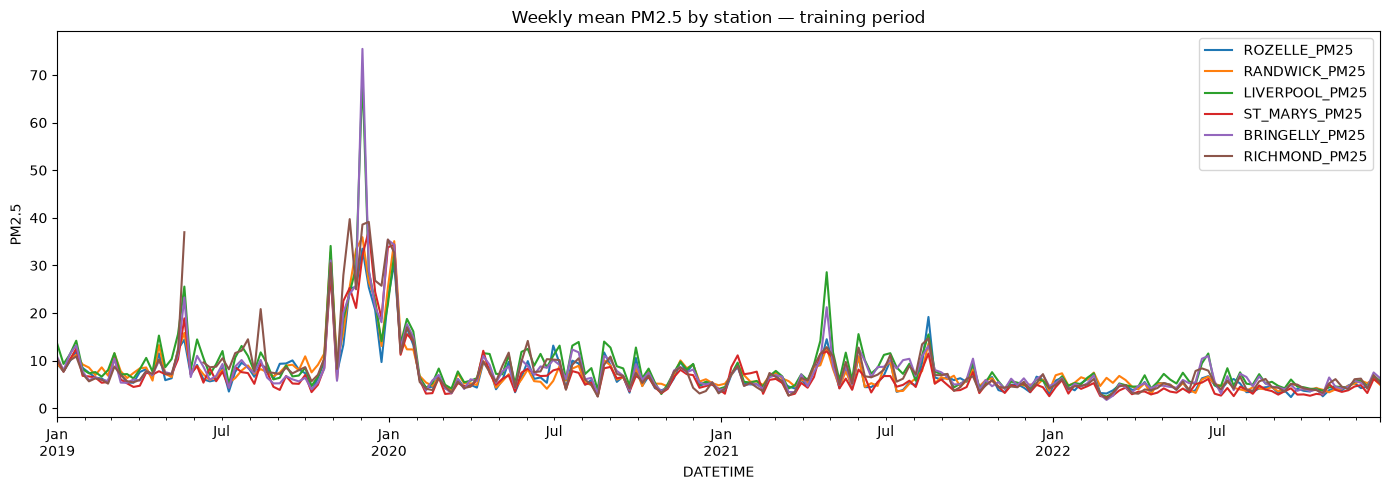

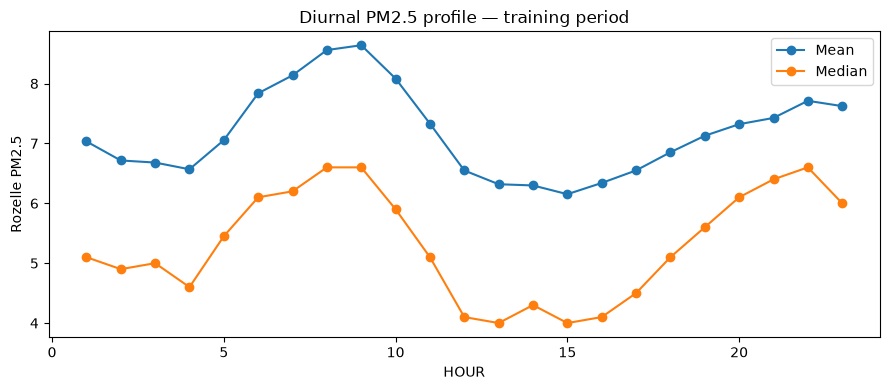

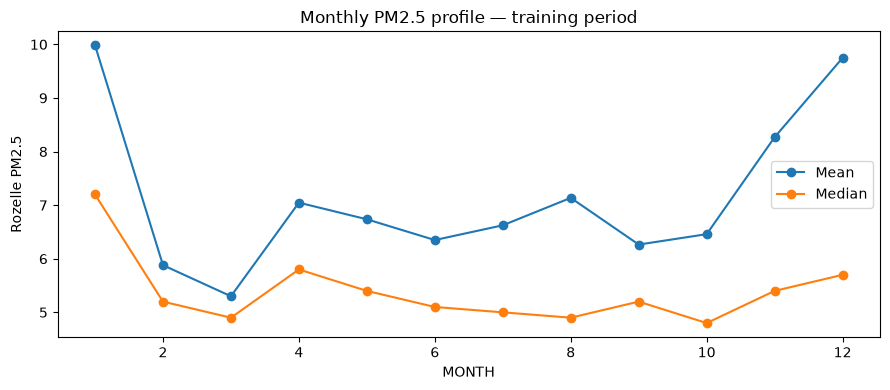

Approximate 95% ACF boundary: 0.0108


,lag_hours,acf,outside_approx_95_band
1,1,0.864644,True
3,3,0.583319,True
6,6,0.373751,True
12,12,0.249321,True
24,24,0.245853,True
48,48,0.183856,True


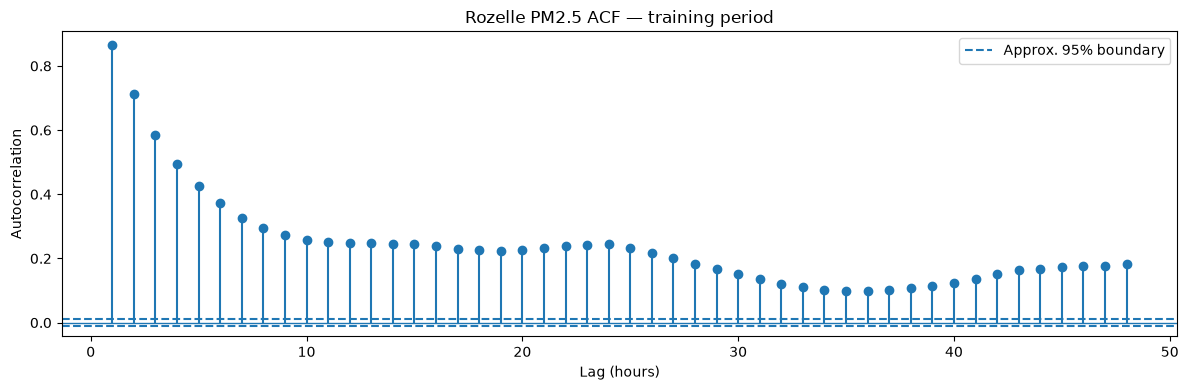

In [11]:
# Use TRAINING period for patterns that help justify modelling choices.
eda_train = master_raw[master_raw["DATETIME"] <= TRAIN_END].copy()

pm25_cols = [
    c for c in eda_train.columns
    if c.endswith("_PM25") and not c.endswith("_ORIGINAL")
]

eda_train.set_index("DATETIME")[pm25_cols].resample("7D").mean().plot(
    figsize=(14, 5),
    title="Weekly mean PM2.5 by station — training period",
)
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

eda = eda_train[["DATETIME", TARGET_RAW_COL]].dropna().copy()
eda["HOUR"] = eda["DATETIME"].dt.hour
eda["MONTH"] = eda["DATETIME"].dt.month

for group_col, title in [
    ("HOUR", "Diurnal PM2.5 profile — training period"),
    ("MONTH", "Monthly PM2.5 profile — training period"),
]:
    profile = eda.groupby(group_col)[TARGET_RAW_COL].agg(["mean", "median"])
    plt.figure(figsize=(9, 4))
    plt.plot(profile.index, profile["mean"], marker="o", label="Mean")
    plt.plot(profile.index, profile["median"], marker="o", label="Median")
    plt.xlabel(group_col)
    plt.ylabel("Rozelle PM2.5")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Keep the regular hourly timeline. Conservative missing handling preserves
# the meaning of lag = number of HOURS rather than number of observed rows.
acf_series = (
    eda_train.set_index("DATETIME")[TARGET_RAW_COL]
    .asfreq("h")
)

acf_values = acf(
    acf_series.values,
    nlags=48,
    fft=True,
    missing="conservative",
)

n_observed = int(acf_series.notna().sum())
acf_95 = 1.96 / np.sqrt(n_observed)

acf_df = pd.DataFrame({
    "lag_hours": np.arange(len(acf_values)),
    "acf": acf_values,
})
acf_df["outside_approx_95_band"] = acf_df["acf"].abs() > acf_95

print("Approximate 95% ACF boundary:", round(acf_95, 4))
display(acf_df[acf_df["lag_hours"].isin([1, 3, 6, 12, 24, 48])])

plt.figure(figsize=(12, 4))
plt.stem(acf_df["lag_hours"].iloc[1:], acf_df["acf"].iloc[1:], basefmt=" ")
plt.axhline(acf_95, linestyle="--", label="Approx. 95% boundary")
plt.axhline(-acf_95, linestyle="--")
plt.axhline(0, linewidth=1)
plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.title("Rozelle PM2.5 ACF — training period")
plt.legend()
plt.tight_layout()
plt.show()

acf_df.to_csv(exports_dir / "rozelle_pm25_acf.csv", index=False)


### 5.5 Correlation before processing

,feature,spearman_with_next_hour_pm25,abs_spearman,n_pairs
5,ROZELLE_PM25,0.782265,0.782265,32402
6,ROZELLE_PM10,0.639110,0.639110,32366
28,LIVERPOOL_PM10,0.577627,0.577627,32202
13,RANDWICK_PM10,0.522261,0.522261,32200
27,LIVERPOOL_PM25,0.521554,0.521554,31686
53,RICHMOND_PM10,0.485988,0.485988,31616
9,ROZELLE_CO,0.468291,0.468291,30605
39,BRINGELLY_PM10,0.442017,0.442017,32033
26,LIVERPOOL_CO,0.433979,0.433979,29722
38,BRINGELLY_PM25,0.426657,0.426657,31488


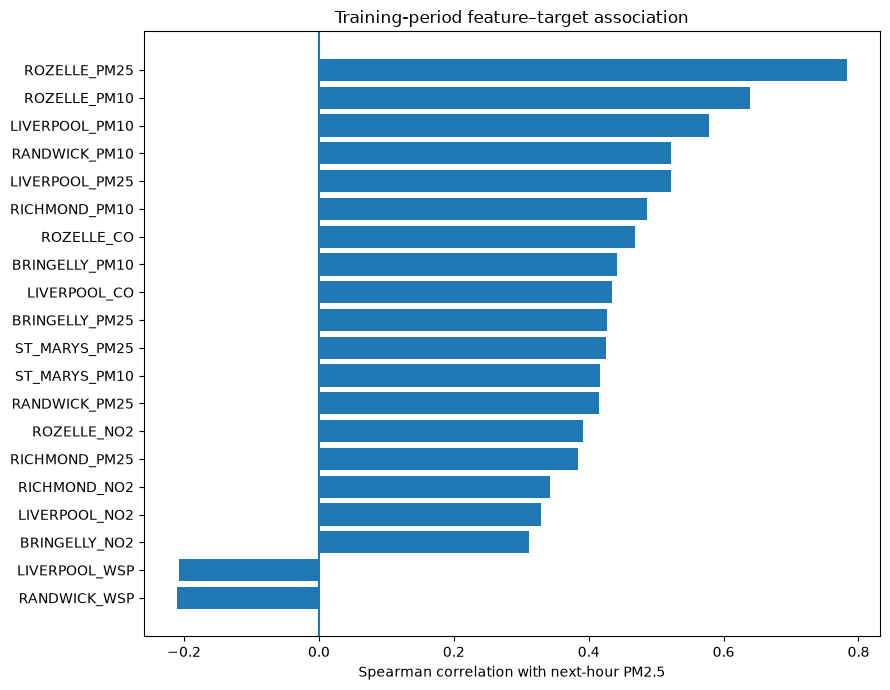

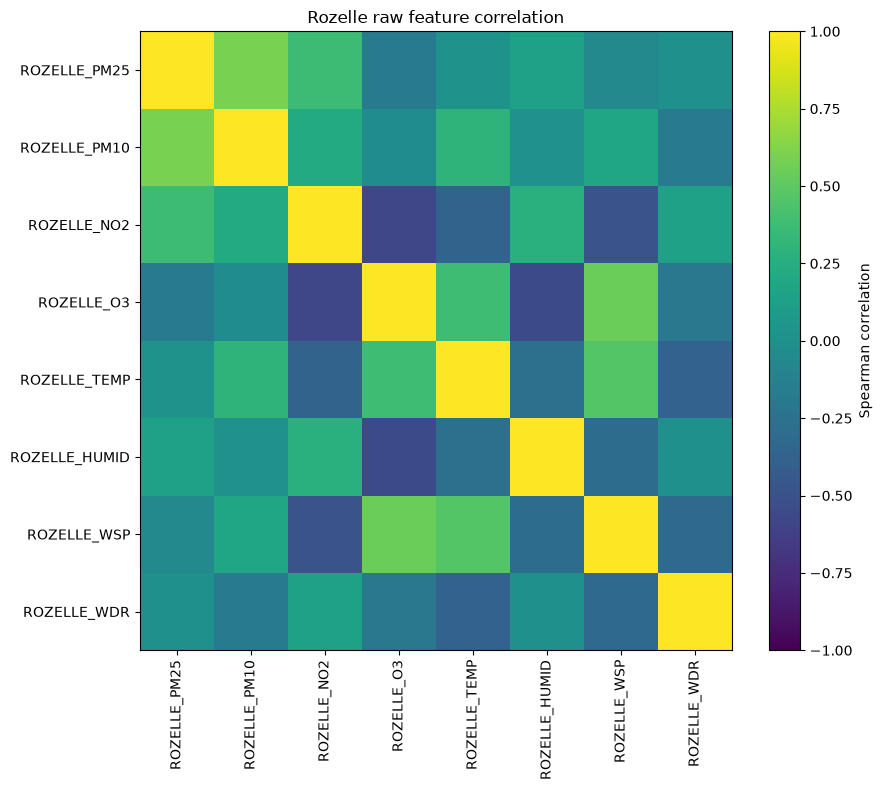

In [12]:
corr_data = master_raw.copy(); corr_data["EDA_TARGET_T_PLUS_1"] = corr_data[ORIGINAL_TARGET_COL].shift(-FORECAST_HORIZON)
train_corr = corr_data[corr_data["DATETIME"] <= TRAIN_END].copy()
numeric = [c for c in train_corr.select_dtypes(include=[np.number]).columns if c not in {ORIGINAL_TARGET_COL,"EDA_TARGET_T_PLUS_1"}]
rows=[]
for col in numeric:
    pair=train_corr[[col,"EDA_TARGET_T_PLUS_1"]].dropna()
    if len(pair)>=50:
        value=pair[col].corr(pair["EDA_TARGET_T_PLUS_1"],method="spearman")
        rows.append({"feature":col,"spearman_with_next_hour_pm25":value,"abs_spearman":abs(value),"n_pairs":len(pair)})
target_assoc_df=pd.DataFrame(rows).sort_values("abs_spearman",ascending=False)
display(target_assoc_df.head(25)); target_assoc_df.to_csv(exports_dir / "raw_feature_target_spearman.csv",index=False)
top=target_assoc_df.head(20).sort_values("spearman_with_next_hour_pm25")
plt.figure(figsize=(9,7)); plt.barh(top["feature"],top["spearman_with_next_hour_pm25"]); plt.axvline(0); plt.xlabel("Spearman correlation with next-hour PM2.5"); plt.title("Training-period feature–target association"); plt.tight_layout(); plt.show()

rozelle_core=[c for c in [f"ROZELLE_{v}" for v in CORE_VARS] if c in train_corr.columns]
rc=train_corr[rozelle_core].corr(method="spearman")
plt.figure(figsize=(9,8)); plt.imshow(rc,vmin=-1,vmax=1,aspect="auto"); plt.xticks(range(len(rc.columns)),rc.columns,rotation=90); plt.yticks(range(len(rc.index)),rc.index); plt.colorbar(label="Spearman correlation"); plt.title("Rozelle raw feature correlation"); plt.tight_layout(); plt.show()

### 5.6 Multi-variable distributions and scatter relationships

Correlation alone can hide distribution shape, nonlinearity and extreme-event influence. We therefore inspect important pollution and meteorological variables with:
- histograms for distribution shape;
- boxplots for spread and extreme candidates;
- scatterplots of each feature at time `t` against observed Rozelle PM2.5 at `t+1`.

These modelling-decision plots use the training period only, so the 2024 target cannot influence feature choices.


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ROZELLE_PM25,32699.0,7.172550,10.424342,-9.9,-2.8,-0.3,2.9,5.3,8.9,18.2,42.900,533.5
ROZELLE_PM10,32845.0,17.350550,16.184012,-10.0,1.0,4.6,9.5,14.5,21.2,36.6,71.256,854.3
ROZELLE_NO2,31027.0,0.760918,0.717978,-0.3,-0.1,0.0,0.2,0.5,1.2,2.2,2.900,9.0
ROZELLE_O3,31577.0,1.767837,1.102940,0.0,0.1,0.1,0.9,1.8,2.5,3.4,4.600,17.9
ROZELLE_CO,31226.0,0.208720,0.145189,-0.1,0.0,0.1,0.1,0.2,0.2,0.4,0.700,5.2
ROZELLE_TEMP,33005.0,17.795595,5.062180,4.6,7.2,9.4,14.2,18.0,21.2,25.9,29.900,41.3
ROZELLE_HUMID,32975.0,69.708252,17.990595,9.1,25.1,37.3,57.2,70.8,84.7,95.4,98.000,99.2
ROZELLE_WSP,33239.0,1.635356,1.320164,0.0,0.1,0.2,0.6,1.3,2.5,4.2,5.400,19.2


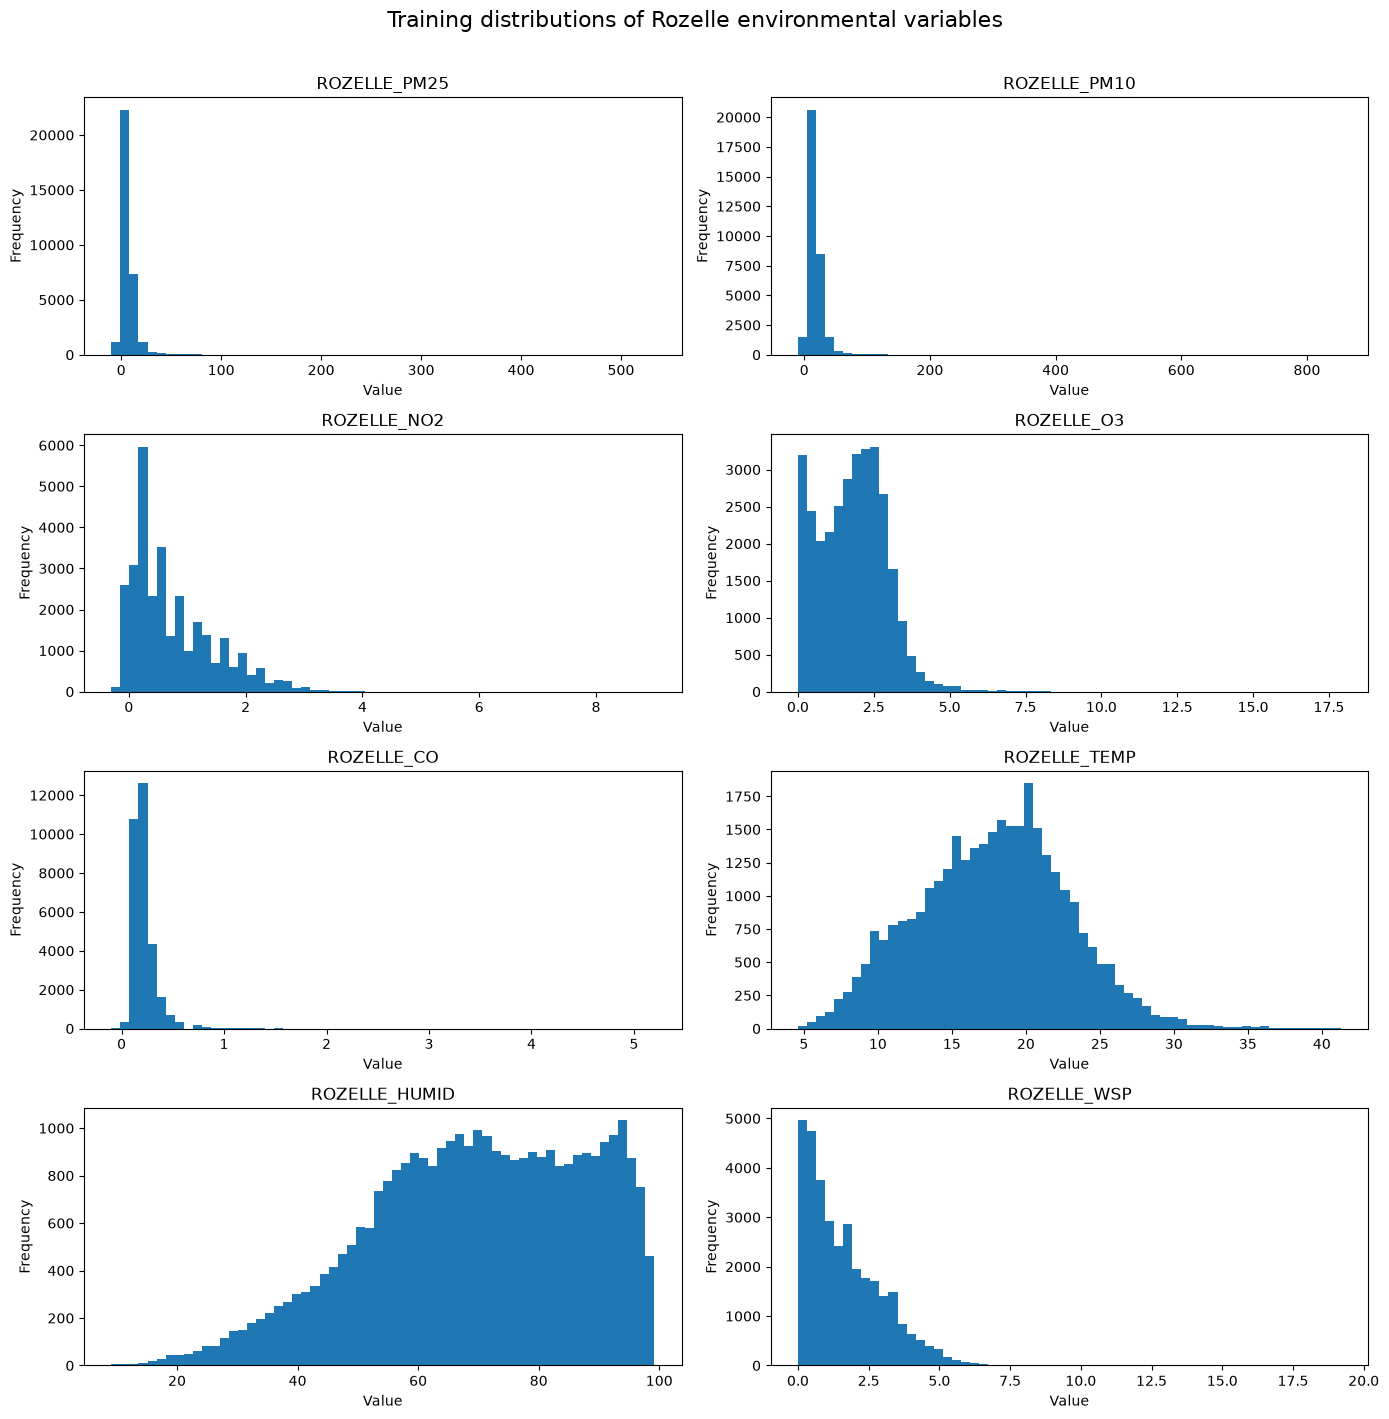

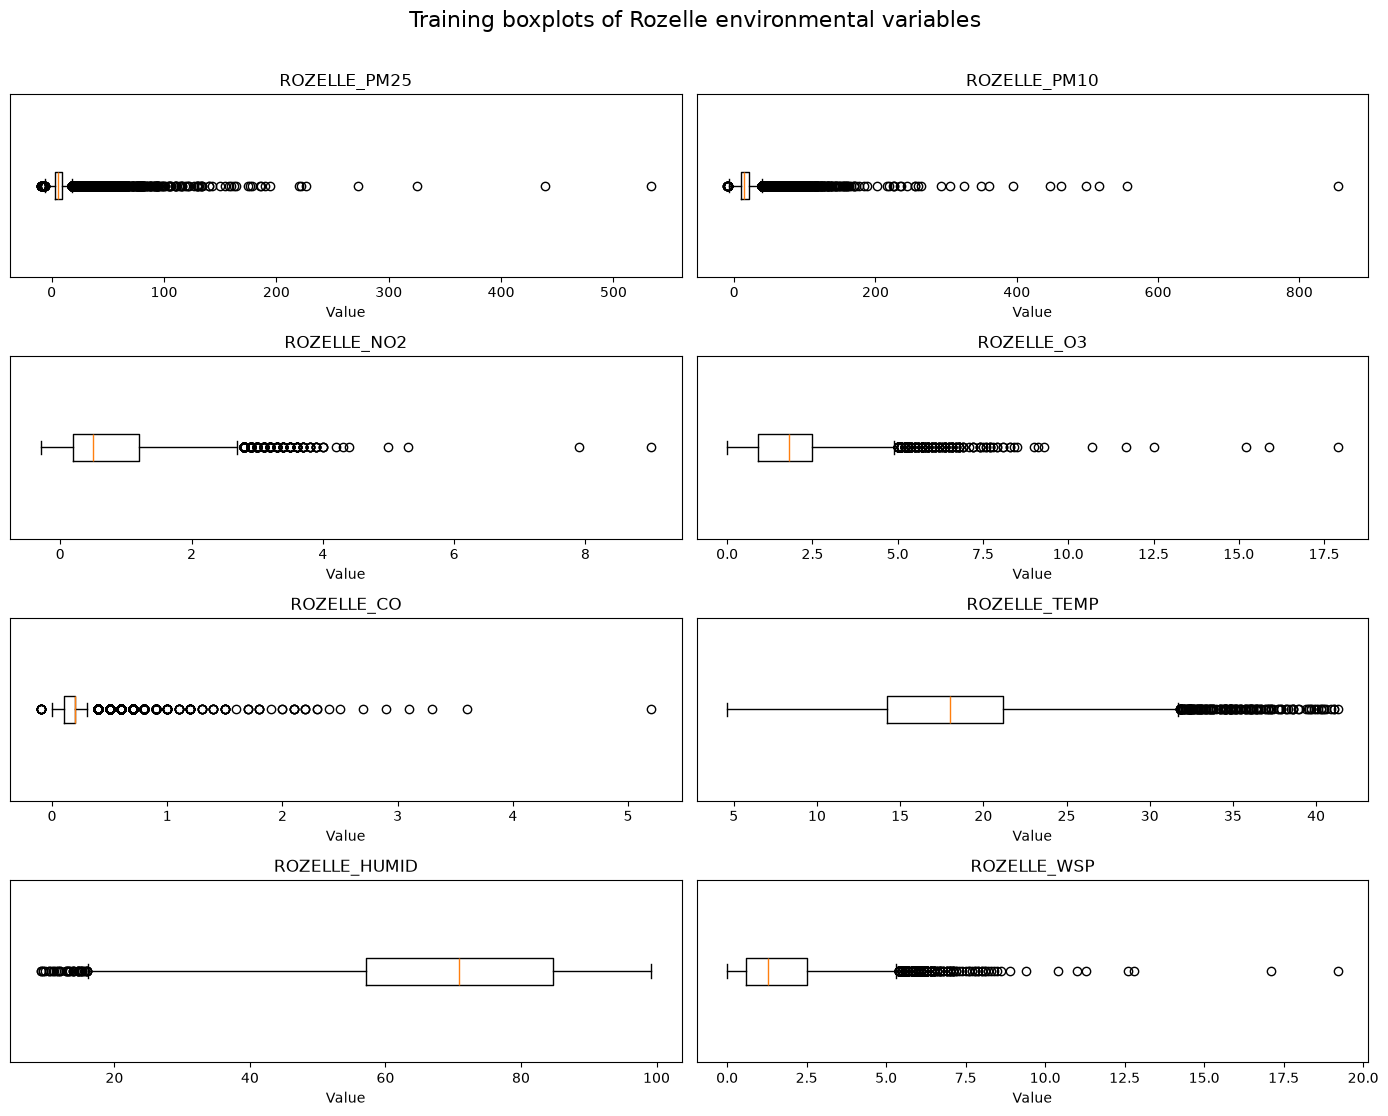

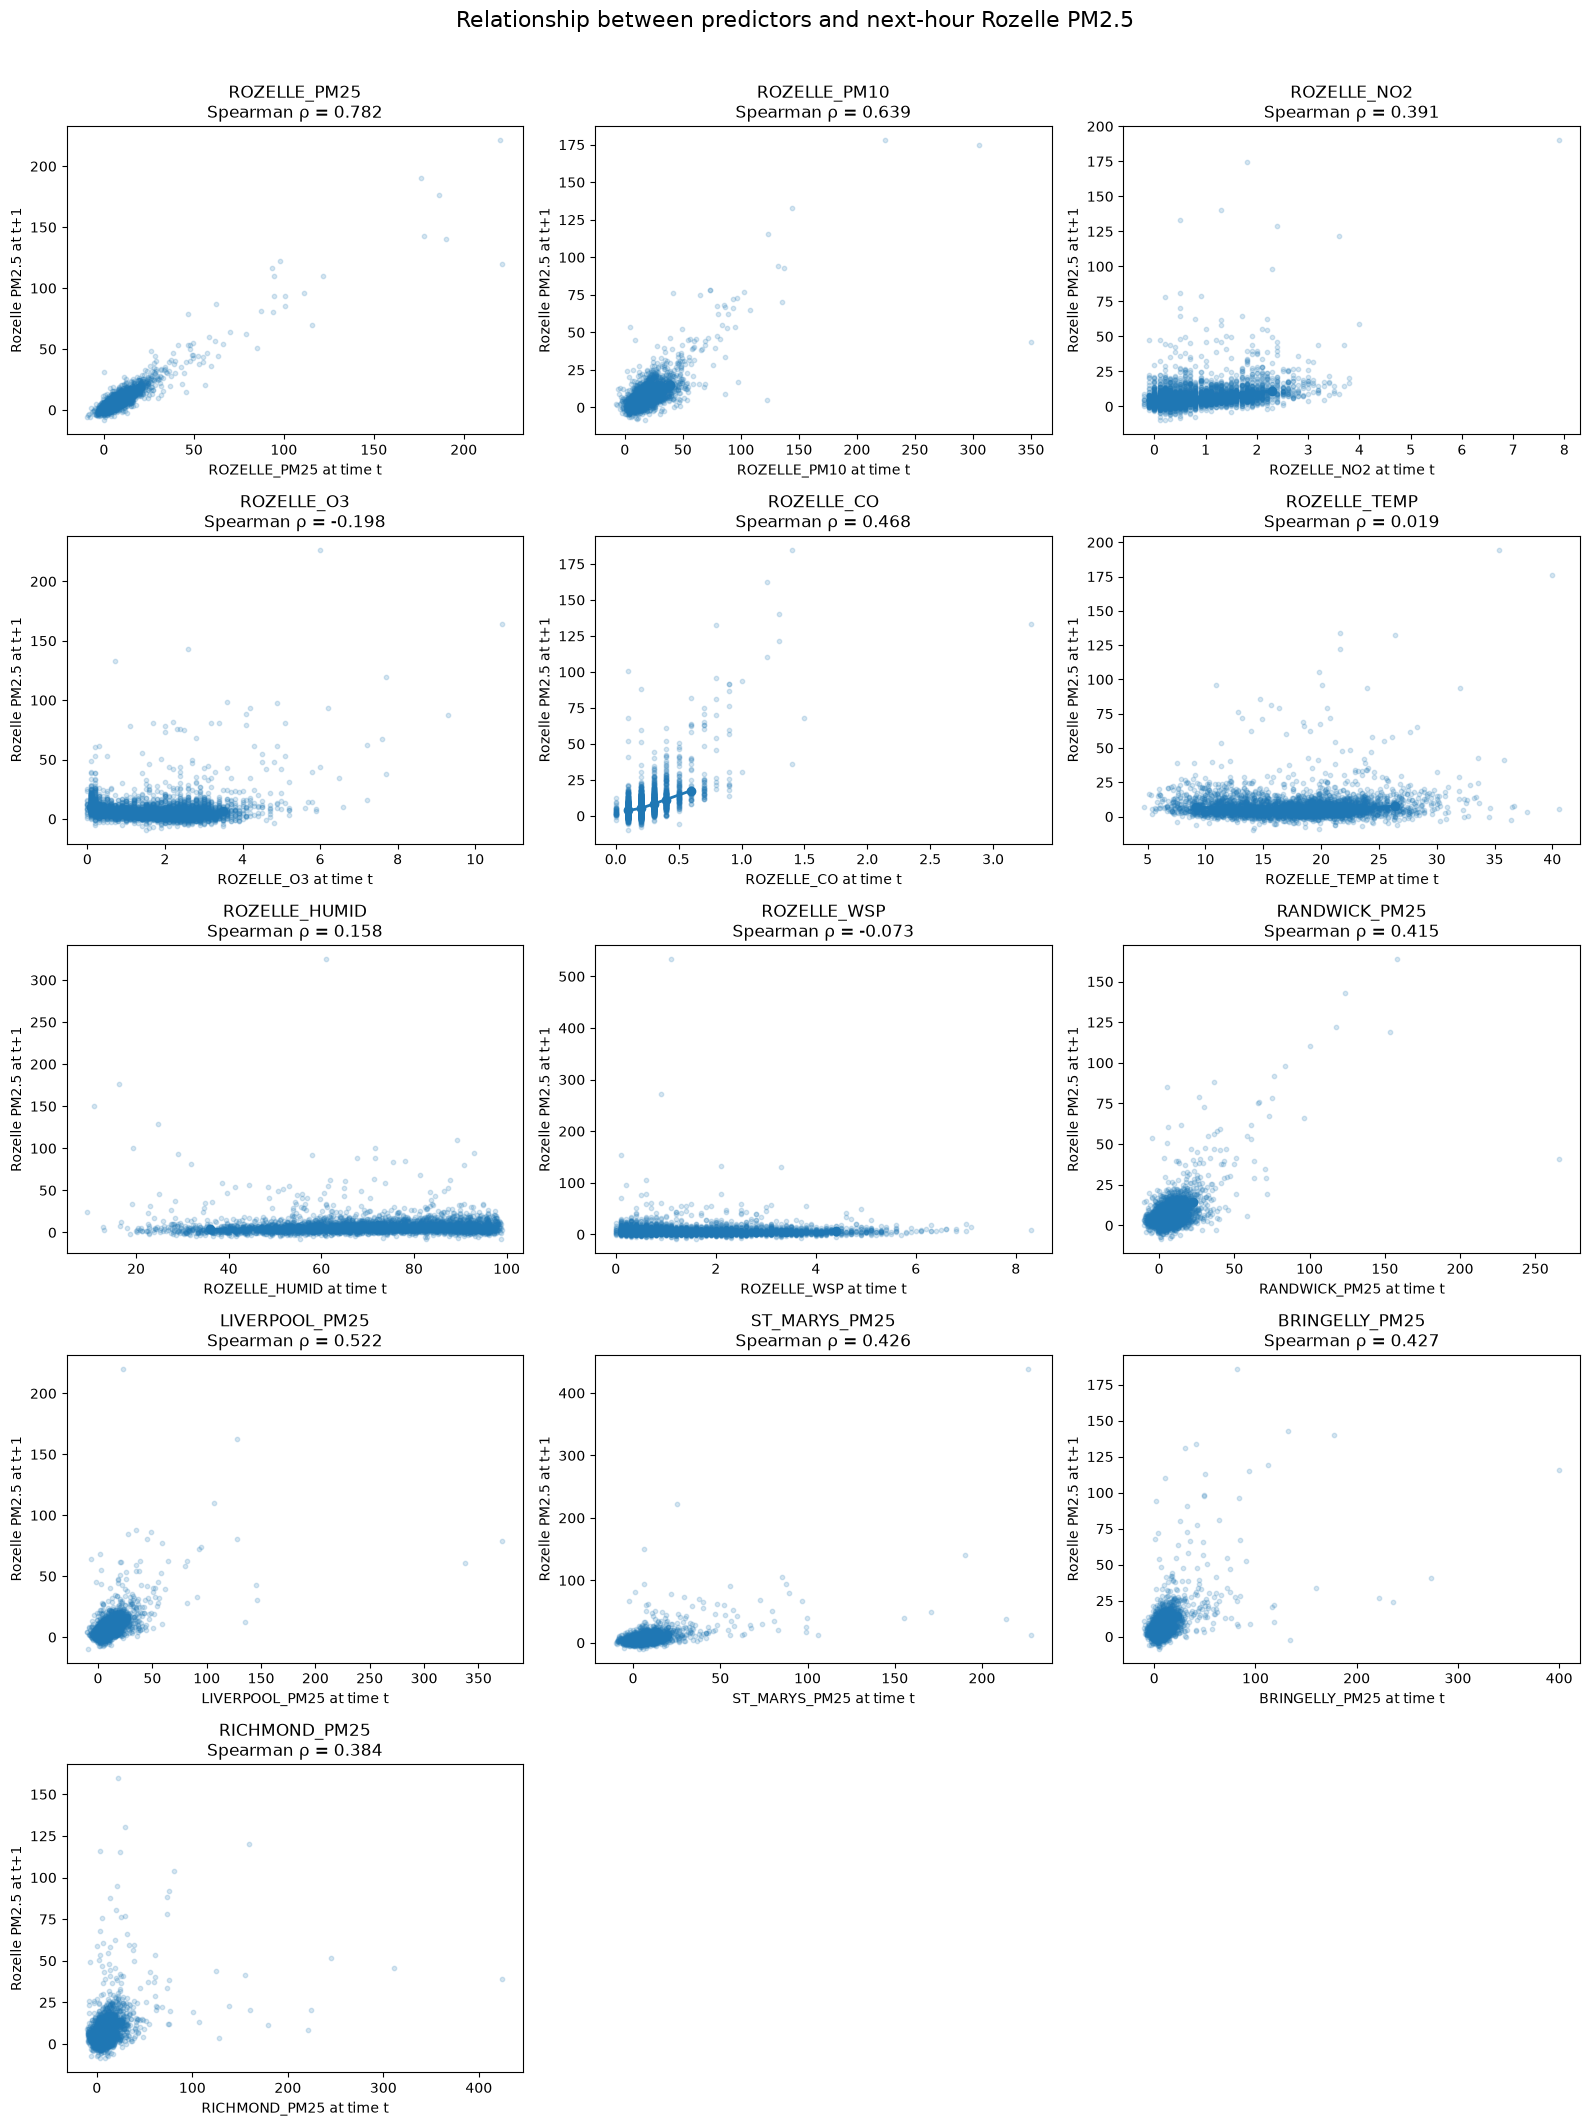

,feature,spearman_with_next_hour_pm25,abs_spearman,n_pairs
0,ROZELLE_PM25,0.782256,0.782256,32401
1,ROZELLE_PM10,0.639100,0.639100,32365
9,LIVERPOOL_PM25,0.521538,0.521538,31685
4,ROZELLE_CO,0.468301,0.468301,30604
11,BRINGELLY_PM25,0.426641,0.426641,31487
10,ST_MARYS_PM25,0.426146,0.426146,31014
8,RANDWICK_PM25,0.414748,0.414748,30799
2,ROZELLE_NO2,0.391338,0.391338,30435
12,RICHMOND_PM25,0.384110,0.384110,29715
3,ROZELLE_O3,-0.197858,0.197858,30948


In [13]:
# ===============================================================
# EDA VISUALISATION MATRICES
# Histograms + Boxplots + Scatterplots
# ===============================================================

# Use TRAINING period only for EDA decisions.
eda_train = master_raw[
    master_raw["DATETIME"] <= TRAIN_END
].copy()


# ===============================================================
# A. HISTOGRAM MATRIX
# ===============================================================

distribution_cols = [
    c for c in [
        "ROZELLE_PM25",
        "ROZELLE_PM10",
        "ROZELLE_NO2",
        "ROZELLE_O3",
        "ROZELLE_CO",
        "ROZELLE_TEMP",
        "ROZELLE_HUMID",
        "ROZELLE_WSP",
    ]
    if c in eda_train.columns
]

# Statistical summary for evidence / report.
distribution_summary = eda_train[
    distribution_cols
].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).T

display(distribution_summary)

distribution_summary.to_csv(
    exports_dir / "training_distribution_summary.csv"
)


# Create one histogram matrix instead of many separate figures.
n_cols = 2
n_rows = int(
    np.ceil(
        len(distribution_cols) / n_cols
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14)
)

axes = np.array(axes).flatten()

for i, col in enumerate(distribution_cols):
    values = eda_train[col].dropna()

    axes[i].hist(
        values,
        bins=60
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Hide unused subplot positions.
for j in range(
    len(distribution_cols),
    len(axes)
):
    axes[j].axis("off")

fig.suptitle(
    "Training distributions of Rozelle environmental variables",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()


# ===============================================================
# B. BOXPLOT MATRIX
# ===============================================================

n_cols = 2
n_rows = int(
    np.ceil(
        len(distribution_cols) / n_cols
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 11)
)

axes = np.array(axes).flatten()

for i, col in enumerate(distribution_cols):
    values = eda_train[col].dropna()

    axes[i].boxplot(
        values,
        vert=False
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")

    # Remove unnecessary y-axis labels.
    axes[i].set_yticks([])

# Hide unused subplot positions.
for j in range(
    len(distribution_cols),
    len(axes)
):
    axes[j].axis("off")

fig.suptitle(
    "Training boxplots of Rozelle environmental variables",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()


# ===============================================================
# C. SCATTERPLOT MATRIX
# Feature at time t vs Rozelle PM2.5 at t+1
# ===============================================================

relationship_df = eda_train.copy()

# Create next-hour PM2.5 target only for EDA.
relationship_df["EDA_TARGET_T_PLUS_1"] = (
    relationship_df[
        ORIGINAL_TARGET_COL
    ]
    .shift(-FORECAST_HORIZON)
)

# Make sure the target itself does not cross
# from training into validation.
relationship_target_time = (
    relationship_df["DATETIME"]
    + pd.to_timedelta(
        FORECAST_HORIZON,
        unit="h"
    )
)

relationship_df = relationship_df[
    relationship_target_time <= TRAIN_END
].copy()


# Variables to compare with next-hour Rozelle PM2.5.
relationship_cols = [
    c for c in [
        "ROZELLE_PM25",
        "ROZELLE_PM10",
        "ROZELLE_NO2",
        "ROZELLE_O3",
        "ROZELLE_CO",
        "ROZELLE_TEMP",
        "ROZELLE_HUMID",
        "ROZELLE_WSP",

        # Neighbour PM2.5
        "RANDWICK_PM25",
        "LIVERPOOL_PM25",
        "ST_MARYS_PM25",
        "BRINGELLY_PM25",
        "RICHMOND_PM25",
    ]
    if c in relationship_df.columns
]


relationship_rows = []

# 3 columns gives a compact matrix for screenshots.
n_cols = 3
n_rows = int(
    np.ceil(
        len(relationship_cols) / n_cols
    )
)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(
        16,
        n_rows * 4.2
    )
)

axes = np.array(axes).flatten()


for i, col in enumerate(
    relationship_cols
):
    pair = relationship_df[
        [
            col,
            "EDA_TARGET_T_PLUS_1"
        ]
    ].dropna()

    # Not enough observations to analyse reliably.
    if len(pair) < 100:
        axes[i].axis("off")
        continue


    # -----------------------------------------------------------
    # Spearman correlation
    # -----------------------------------------------------------

    rho = pair[col].corr(
        pair[
            "EDA_TARGET_T_PLUS_1"
        ],
        method="spearman"
    )

    relationship_rows.append({
        "feature": col,
        "spearman_with_next_hour_pm25": rho,
        "abs_spearman": abs(rho),
        "n_pairs": len(pair),
    })


    # -----------------------------------------------------------
    # Scatter sample
    # -----------------------------------------------------------
    # Use maximum 4000 points so plots stay responsive
    # while remaining reproducible.
    sample = pair.sample(
        min(
            4000,
            len(pair)
        ),
        random_state=42
    )

    axes[i].scatter(
        sample[col],
        sample[
            "EDA_TARGET_T_PLUS_1"
        ],
        alpha=0.18,
        s=10
    )


    # -----------------------------------------------------------
    # Binned median trend
    # -----------------------------------------------------------
    # This shows the general relationship without assuming
    # that the relationship must be a straight line.
    try:
        bins = pd.qcut(
            pair[col],
            q=12,
            duplicates="drop"
        )

        trend = (
            pair
            .assign(
                _BIN=bins
            )
            .groupby(
                "_BIN",
                observed=True
            )
            .agg(
                feature_median=(
                    col,
                    "median"
                ),
                target_median=(
                    "EDA_TARGET_T_PLUS_1",
                    "median"
                ),
            )
            .dropna()
        )

        axes[i].plot(
            trend[
                "feature_median"
            ],
            trend[
                "target_median"
            ],
            marker="o",
            linewidth=2
        )

    except Exception:
        pass


    # -----------------------------------------------------------
    # Plot labels
    # -----------------------------------------------------------

    axes[i].set_title(
        f"{col}\n"
        f"Spearman ρ = {rho:.3f}"
    )

    axes[i].set_xlabel(
        f"{col} at time t"
    )

    axes[i].set_ylabel(
        "Rozelle PM2.5 at t+1"
    )


# Hide unused subplot positions.
for j in range(
    len(relationship_cols),
    len(axes)
):
    axes[j].axis("off")


fig.suptitle(
    "Relationship between predictors and next-hour Rozelle PM2.5",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()


# ===============================================================
# D. RELATIONSHIP SUMMARY TABLE
# ===============================================================

relationship_visual_summary = (
    pd.DataFrame(
        relationship_rows
    )
    .sort_values(
        "abs_spearman",
        ascending=False
    )
)

display(
    relationship_visual_summary
)

relationship_visual_summary.to_csv(
    exports_dir
    / "training_visual_relationship_summary.csv",
    index=False
)

### 5.7 Validate flagged extremes

A flagged value is checked for **causal support**:

- same feature, previous hour, same extreme direction;
- same variable at another station, same time, same extreme direction;
- for PM2.5, same-station PM10 can provide co-pollutant support.

The next hour is shown only for retrospective EDA and is never used by the treatment rule.

Candidates with causal support are retained. Unsupported candidates become `isolated_candidate` values for the sensitivity test in Section 6.2.

In [14]:
def causal_isolated_masks(df):
    """Return one causal isolated-candidate mask per audited raw predictor."""
    masks = {}

    for col in EXTREME_BOUNDS:
        station, variable = split_station_var(col)

        current_dir = extreme_direction(
            df[col],
            variable,
            EXTREME_BOUNDS[col],
        )
        current = current_dir.ne(0)

        prev_hour_ok = df["DATETIME"].diff().eq(
            pd.Timedelta(hours=1)
        )
        previous_dir = current_dir.shift(1, fill_value=0)
        previous_support = (
            current
            & prev_hour_ok
            & previous_dir.eq(current_dir)
        )

        spatial_flags = []

        for other_station in ALL_STATIONS:
            if other_station == station:
                continue

            other_col = f"{other_station}_{variable}"

            if (
                other_col not in EXTREME_BOUNDS
                or other_col not in df.columns
            ):
                continue

            other_dir = extreme_direction(
                df[other_col],
                variable,
                EXTREME_BOUNDS[other_col],
            )

            spatial_flags.append(
                current & other_dir.eq(current_dir)
            )

        spatial_support = (
            pd.concat(spatial_flags, axis=1).any(axis=1)
            if spatial_flags
            else pd.Series(False, index=df.index)
        )

        copollutant_support = pd.Series(
            False,
            index=df.index,
        )

        if variable == "PM25":
            pm10_col = f"{station}_PM10"

            if (
                pm10_col in EXTREME_BOUNDS
                and pm10_col in df.columns
            ):
                copollutant_support = (
                    extreme_direction(
                        df[pm10_col],
                        "PM10",
                        EXTREME_BOUNDS[pm10_col],
                    )
                    .eq(1)
                    & current_dir.eq(1)
                )

        masks[col] = (
            current
            & ~previous_support
            & ~spatial_support
            & ~copollutant_support
        )

    return masks


validation_rows = []

for col in EXTREME_BOUNDS:
    station, variable = split_station_var(col)

    current_dir = extreme_direction(
        extreme_train_raw[col],
        variable,
        EXTREME_BOUNDS[col],
    )
    current = current_dir.ne(0)

    if int(current.sum()) == 0:
        continue

    prev_ok = extreme_train_raw["DATETIME"].diff().eq(
        pd.Timedelta(hours=1)
    )
    next_ok = (
        extreme_train_raw["DATETIME"].shift(-1)
        - extreme_train_raw["DATETIME"]
    ).eq(pd.Timedelta(hours=1))

    previous_support = (
        current
        & prev_ok
        & current_dir.shift(1, fill_value=0).eq(current_dir)
    )

    next_support = (
        current
        & next_ok
        & current_dir.shift(-1, fill_value=0).eq(current_dir)
    )

    spatial_flags = []

    for other_station in ALL_STATIONS:
        if other_station == station:
            continue

        other_col = f"{other_station}_{variable}"

        if (
            other_col in EXTREME_BOUNDS
            and other_col in extreme_train_raw.columns
        ):
            other_dir = extreme_direction(
                extreme_train_raw[other_col],
                variable,
                EXTREME_BOUNDS[other_col],
            )
            spatial_flags.append(
                current & other_dir.eq(current_dir)
            )

    spatial_support = (
        pd.concat(spatial_flags, axis=1).any(axis=1)
        if spatial_flags
        else pd.Series(False, index=extreme_train_raw.index)
    )

    copollutant_support = pd.Series(
        False,
        index=extreme_train_raw.index,
    )

    if variable == "PM25":
        pm10_col = f"{station}_PM10"

        if pm10_col in EXTREME_BOUNDS:
            copollutant_support = (
                extreme_direction(
                    extreme_train_raw[pm10_col],
                    "PM10",
                    EXTREME_BOUNDS[pm10_col],
                )
                .eq(1)
                & current_dir.eq(1)
            )

    causal_isolated = (
        current
        & ~previous_support
        & ~spatial_support
        & ~copollutant_support
    )

    validation_rows.append({
        "feature": col,
        "candidate_hours": int(current.sum()),
        "previous_support_pct": 100 * previous_support[current].mean(),
        "next_support_EDA_pct": 100 * next_support[current].mean(),
        "same_variable_other_station_support_pct": 100 * spatial_support[current].mean(),
        "copollutant_support_pct": 100 * copollutant_support[current].mean(),
        "causal_isolated_hours": int(causal_isolated.sum()),
        "causal_isolated_pct": 100 * causal_isolated[current].mean(),
    })


extreme_validation_summary = (
    pd.DataFrame(validation_rows)
    .sort_values("causal_isolated_pct", ascending=False)
    .reset_index(drop=True)
)

display(extreme_validation_summary)

extreme_validation_summary.to_csv(
    exports_dir / "extreme_validation_all_predictors.csv",
    index=False,
)

print(
    "Supported candidates are kept; isolated candidates are only "
    "eligible for the Section 6.2 sensitivity test."
)

,feature,candidate_hours,previous_support_pct,next_support_EDA_pct,same_variable_other_station_support_pct,copollutant_support_pct,causal_isolated_hours,causal_isolated_pct
0,ST_MARYS_NO2,1158,48.186528,48.186528,39.982729,0.000000,424,36.614853
1,RANDWICK_HUMID,166,70.481928,70.481928,15.662651,0.000000,47,28.313253
2,ROZELLE_CO,3103,66.451821,66.451821,24.363519,0.000000,821,26.458266
3,RICHMOND_NO2,842,52.494062,52.494062,52.731591,0.000000,218,25.890736
4,RANDWICK_NO2,196,41.326531,41.326531,60.204082,0.000000,50,25.510204
5,ROZELLE_WSP,345,55.652174,55.652174,51.884058,0.000000,84,24.347826
6,RANDWICK_PM25,1252,54.233227,54.233227,67.092652,43.051118,304,24.281150
7,ST_MARYS_PM10,2083,60.585694,60.585694,69.563130,0.000000,447,21.459434
8,LIVERPOOL_CO,1264,57.674051,57.674051,59.810127,0.000000,252,19.936709
9,BRINGELLY_WSP,1020,57.352941,57.352941,67.352941,0.000000,202,19.803922


Supported candidates are kept; isolated candidates are only eligible for the Section 6.2 sensitivity test.


### 5.8 EDA evidence → modelling decisions

Only analyses that affect the modelling pipeline are retained.

In [15]:
eda_decision_df = pd.DataFrame([
    ["Missing-gap audit", "Short gaps exist across station predictors", "Causal ffill <= 3 h; longer gaps use TRAIN-fitted imputation"],
    ["Per-feature distributions", "Extreme candidates exist across multiple variables/stations", "Flag first; never delete from IQR alone"],
    ["Temporal / spatial support", "Some candidates are coherent and some isolated", "Keep supported values; test isolated masking"],
    ["ACF / time patterns", "Recent and daily structure is useful", "Use lags, cyclical time features and 24 h DL sequence"],
    ["Correlation / scatter", "Local and neighbour predictors overlap but add context", "Scenario B + conservative TRAIN-only redundancy screening"],
])

eda_decision_df.columns = ["analysis", "finding", "decision"]
display(eda_decision_df)
eda_decision_df.to_csv(exports_dir / "eda_evidence_to_decision.csv", index=False)

,analysis,finding,decision
0,Missing-gap audit,Short gaps exist across station predictors,Causal ffill <= 3 h; longer gaps use TRAIN-fit...
1,Per-feature distributions,Extreme candidates exist across multiple varia...,Flag first; never delete from IQR alone
2,Temporal / spatial support,Some candidates are coherent and some isolated,Keep supported values; test isolated masking
3,ACF / time patterns,Recent and daily structure is useful,"Use lags, cyclical time features and 24 h DL s..."
4,Correlation / scatter,Local and neighbour predictors overlap but add...,Scenario B + conservative TRAIN-only redundanc...


## 6. Preprocessing

The preprocessing strategy separates **measurement validity**, **missingness**, and **extreme but physically plausible pollution**.

1. Physically impossible values are converted to missing.
2. Only short gaps are filled causally (`<= 3 h`).
3. Remaining predictor gaps are handled by an imputer learned from TRAIN only.
4. The target PM2.5 is never imputed.
5. High but plausible pollution observations are retained rather than automatically clipped.
6. Because large valid values may affect neural-network scaling, StandardScaler and RobustScaler are compared on VALIDATION instead of selecting one by assumption.

The purpose is to preserve meaningful pollution behaviour while preventing future information from entering preprocessing.

### 6.0 Leakage-safe preprocessing order

```text
physical validity
→ short gaps <= 3 h: causal forward-fill
→ choose median vs seasonal per predictor
→ validate flagged extremes
→ KEEP/MASK sensitivity on 2023 validation
→ freeze treatment + fill remaining NaN
→ feature engineering
```

Only complete gaps of at most 3 hours are forward-filled. Longer gaps remain missing.

All thresholds/filling statistics are learned without using the 2024 TEST set.  
The observed Rozelle `PM2.5(t+1)` target is never imputed.

In [16]:
master_valid, physical_validity_report = apply_physical_validity_checks(
    master_raw
)

# Reference with only genuinely observed/valid values.
master_observed_reference = master_valid.copy()

master, short_gap_report = fill_short_time_gaps(
    master_valid,
    method=SHORT_GAP_METHOD,
    limit=SHORT_GAP_LIMIT_HOURS,
    exclude_columns=[ORIGINAL_TARGET_COL],
)

master = add_time_features(master)
master = add_wind_direction_encoding(
    master,
    ALL_STATIONS,
)

master_observed_reference = add_time_features(
    master_observed_reference
)
master_observed_reference = add_wind_direction_encoding(
    master_observed_reference,
    ALL_STATIONS,
)

# Untouched target source.
observed_target_source = master_observed_reference[
    ["DATETIME", ORIGINAL_TARGET_COL]
].copy()

print("Invalid measurements changed to missing:")
print(physical_validity_report)

display(short_gap_report.head(25))

short_gap_report.to_csv(
    exports_dir / "short_gap_fill_report.csv",
    index=False,
)

Invalid measurements changed to missing:
{'ROZELLE_SOLAR': 24018, 'ROZELLE_O3': 6, 'ROZELLE_PM25': 2635, 'ROZELLE_PM10': 368, 'ROZELLE_CO': 10, 'ROZELLE_NO2': 1287, 'RANDWICK_PM25': 4576, 'RANDWICK_PM10': 334, 'RANDWICK_O3': 1, 'RANDWICK_HUMID': 1649, 'RANDWICK_NO2': 3428, 'LIVERPOOL_HUMID': 447, 'LIVERPOOL_NO2': 937, 'LIVERPOOL_O3': 31, 'LIVERPOOL_CO': 19274, 'LIVERPOOL_PM25': 3308, 'LIVERPOOL_PM10': 359, 'ST_MARYS_O3': 57, 'ST_MARYS_PM25': 4724, 'ST_MARYS_NO2': 1685, 'ST_MARYS_HUMID': 949, 'ST_MARYS_PM10': 614, 'BRINGELLY_PM25': 4467, 'BRINGELLY_PM10': 1577, 'BRINGELLY_NO2': 3196, 'BRINGELLY_SOLAR': 9648, 'BRINGELLY_HUMID': 5403, 'RICHMOND_HUMID': 26, 'RICHMOND_PM25': 5119, 'RICHMOND_O3': 5, 'RICHMOND_PM10': 1004, 'RICHMOND_NO2': 5297, 'ROZELLE_PM25_ORIGINAL': 2635}


,column,missing_before,filled_short_gaps,missing_after
0,ST_MARYS_CO,50416,0,50416
1,RICHMOND_CO,50416,0,50416
2,RICHMOND_SOLAR,50416,0,50416
3,BRINGELLY_CO,50416,0,50416
4,ST_MARYS_SOLAR,50416,0,50416
5,LIVERPOOL_SOLAR,50416,0,50416
6,RANDWICK_RAIN,31786,17,31769
7,ROZELLE_SOLAR,24933,33,24900
8,LIVERPOOL_RAIN,22682,53,22629
9,LIVERPOOL_CO,24059,1954,22105


### 6.1 Choose an imputer for each predictor

For each available predictor from all six stations, genuinely observed 2023 values are temporarily hidden and reconstructed.

Two methods are fitted on TRAIN:
- **median:** one global TRAIN median;
- **seasonal:** TRAIN hour-of-week median, with global median fallback.

The lower reconstruction RMSE is selected **separately for each predictor**.

Wind direction is represented by `sin/cos`; those components are tested instead of imputing degrees directly.

The selected method later fills:
- genuine remaining missing values;
- isolated extremes that are masked to `NaN`.

In [17]:
def compare_imputers(
    train_df,
    val_df,
    columns,
    truth_val_df=None,
    mask_fraction=0.10,
    random_state=42,
):
    """Compare TRAIN-fitted median vs seasonal reconstruction per feature."""
    rng = np.random.default_rng(random_state)
    rows = []

    truth_val_df = (
        val_df
        if truth_val_df is None
        else truth_val_df
    )

    helpers = ["HOUR", "DAY_OF_WEEK"]

    usable = [
        c for c in columns
        if c in train_df.columns
        and c in val_df.columns
        and c in truth_val_df.columns
    ]

    seasonal = PerFeatureMedianImputer(
        {},
        fallback="seasonal",
    ).fit(train_df[helpers + usable])

    for col in usable:
        train_observed = train_df[col].dropna()

        # Only benchmark against values that were truly observed.
        observed_idx = truth_val_df.index[
            truth_val_df[col].notna()
        ].intersection(val_df.index).to_numpy()

        if len(train_observed) == 0 or len(observed_idx) < 50:
            continue

        n_mask = min(
            len(observed_idx),
            max(20, int(len(observed_idx) * mask_fraction)),
        )

        chosen = rng.choice(
            observed_idx,
            size=n_mask,
            replace=False,
        )

        truth = (
            truth_val_df.loc[chosen, col]
            .astype(float)
            .to_numpy()
        )

        masked = val_df[helpers + usable].copy()
        masked.loc[chosen, col] = np.nan

        seasonal_pred = (
            seasonal.transform(masked)
            .loc[chosen, col]
            .astype(float)
            .to_numpy()
        )

        median_pred = np.full(
            n_mask,
            float(train_observed.median()),
            dtype=float,
        )

        for method, pred in [
            ("seasonal", seasonal_pred),
            ("median", median_pred),
        ]:
            rows.append({
                "feature": col,
                "method": method,
                "RMSE": float(
                    np.sqrt(mean_squared_error(truth, pred))
                ),
                "MAE": float(
                    mean_absolute_error(truth, pred)
                ),
                "n_masked": n_mask,
            })

    return pd.DataFrame(rows)


pre_train = master[
    master["DATETIME"] <= TRAIN_END
].copy()

pre_val = master[
    (master["DATETIME"] > TRAIN_END)
    & (master["DATETIME"] <= VAL_END)
].copy()

reference_val = master_observed_reference[
    (master_observed_reference["DATETIME"] > TRAIN_END)
    & (master_observed_reference["DATETIME"] <= VAL_END)
].copy()

direction_features = [
    f"{station}_WDR_{component}"
    for station in ALL_STATIONS
    for component in ["SIN", "COS"]
    if f"{station}_WDR_{component}" in master.columns
]

IMPUTATION_INPUT_COLS = [
    c for c in raw_station_predictors
    if not c.endswith("_WDR")
] + direction_features

imputation_comparison = compare_imputers(
    pre_train,
    pre_val,
    IMPUTATION_INPUT_COLS,
    truth_val_df=reference_val,
)

if imputation_comparison.empty:
    raise RuntimeError(
        "Imputation comparison produced no usable predictors."
    )

imputation_choice_df = (
    imputation_comparison
    .sort_values(["feature", "RMSE", "MAE"])
    .groupby("feature", as_index=False)
    .first()
    .rename(columns={"method": "selected_method"})
)

SELECTED_IMPUTATION_BY_FEATURE = dict(
    zip(
        imputation_choice_df["feature"],
        imputation_choice_df["selected_method"],
    )
)

overall_imputation = (
    imputation_comparison
    .groupby("method", as_index=False)
    .agg(
        mean_RMSE=("RMSE", "mean"),
        mean_MAE=("MAE", "mean"),
    )
    .sort_values(["mean_RMSE", "mean_MAE"])
    .reset_index(drop=True)
)

GLOBAL_FALLBACK_IMPUTATION = (
    overall_imputation.iloc[0]["method"]
)

print("Per-feature imputation choices:")
display(
    imputation_choice_df[
        ["feature", "selected_method", "RMSE", "MAE", "n_masked"]
    ]
)

print(
    "Fallback for derived/unmapped features:",
    GLOBAL_FALLBACK_IMPUTATION,
)

imputation_comparison.to_csv(
    exports_dir / "imputation_comparison_by_feature.csv",
    index=False,
)

imputation_choice_df.to_csv(
    exports_dir / "selected_imputer_by_feature.csv",
    index=False,
)


def apply_selected_raw_imputation(df):
    """Fit the frozen per-feature imputer on TRAIN, then transform all periods."""
    out = df.copy()

    cols = [
        c for c in IMPUTATION_INPUT_COLS
        if c in out.columns
    ]

    helpers = ["HOUR", "DAY_OF_WEEK"]
    train_mask = out["DATETIME"] <= TRAIN_END

    imputer = PerFeatureMedianImputer(
        SELECTED_IMPUTATION_BY_FEATURE,
        fallback=GLOBAL_FALLBACK_IMPUTATION,
    ).fit(
        out.loc[
            train_mask,
            helpers + cols,
        ]
    )

    filled = imputer.transform(
        out[helpers + cols]
    )

    out[cols] = filled[cols]

    return out, imputer

Per-feature imputation choices:


,feature,selected_method,RMSE,MAE,n_masked
0,BRINGELLY_HUMID,seasonal,16.747209,12.586026,687
1,BRINGELLY_NO2,seasonal,0.379397,0.264105,631
2,BRINGELLY_O3,seasonal,0.946201,0.685071,777
3,BRINGELLY_PM10,seasonal,13.689313,8.545032,785
4,BRINGELLY_PM25,seasonal,7.393095,4.257463,737
...,...,...,...,...,...
57,ST_MARYS_PM25,median,5.356206,3.356855,744
58,ST_MARYS_TEMP,seasonal,5.870040,4.861650,824
59,ST_MARYS_WDR_COS,seasonal,0.826848,0.631143,834
60,ST_MARYS_WDR_SIN,seasonal,0.577910,0.467814,834


Fallback for derived/unmapped features: seasonal


### 6.2 KEEP, plain IQR and coherence-aware MASK ablation

IQR flags candidate extremes; it does not prove that a value is erroneous.

The ablation compares:
- `KEEP` all candidates;
- `plain_iqr_mask_all`, which masks every TRAIN-IQR candidate without coherence checks;
- coherence-aware MASK policies, which mask only candidates unsupported by the previous hour, another station or PM10 support for PM2.5.

Each policy uses the same fixed Random Forest, 2019–2022 training data and 2023 validation RMSE. This RF is only a **preprocessing sensitivity model**; the final Random Forest is tuned later in Section 10.1.

Masked predictors become `NaN` and use the per-feature TRAIN-fitted imputer selected in Section 6.1. The best policy is frozen before feature engineering and final model tuning.


In [18]:
# ===============================================================
# 6.2 OUTLIER-TREATMENT SENSITIVITY
# ===============================================================

OUTLIER_GROUPS = {
    "PM25": {"PM25"},
    "PM10": {"PM10"},
    "GASES": {"NO2", "O3", "CO"},
    "METEOROLOGY": {"TEMP", "HUMID", "WSP"},
}


def mask_isolated_variables(df, variables=None):
    """Mask causal isolated candidates for the requested raw-variable set."""
    out = df.copy()
    masks = causal_isolated_masks(out)
    counts = {}

    for col, mask in masks.items():
        _, variable = split_station_var(col)

        if variables is not None and variable not in variables:
            continue

        counts[col] = int(mask.sum())
        out.loc[mask, col] = np.nan

    return out, counts


def mask_plain_iqr_candidates(df):
    """Mask every TRAIN-IQR candidate without temporal or spatial checks."""
    out = df.copy()
    counts = {}

    for col, bounds in EXTREME_BOUNDS.items():
        if col not in out.columns:
            continue

        _, variable = split_station_var(col)
        mask = extreme_direction(out[col], variable, bounds).ne(0)
        counts[col] = int(mask.sum())
        out.loc[mask, col] = np.nan

    return out, counts


def apply_outlier_treatment(df, treatment, variables=None):
    if treatment == "keep":
        return df.copy(), {}
    if treatment == "plain_iqr_mask_all":
        return mask_plain_iqr_candidates(df)
    return mask_isolated_variables(df, variables)


def build_sensitivity_features(base_df, target_source):
    """Compact copy of the final A/B air-quality feature logic."""
    out = base_df.copy()

    local_roll = [
        c for c in [
            "ROZELLE_PM25", "ROZELLE_PM10", "ROZELLE_NO2",
            "ROZELLE_O3", "ROZELLE_CO", "ROZELLE_TEMP",
            "ROZELLE_HUMID", "ROZELLE_WSP",
        ]
        if c in out.columns
    ]

    local_lag = local_roll + [
        c for c in ["ROZELLE_WDR_SIN", "ROZELLE_WDR_COS"]
        if c in out.columns
    ]

    neighbour_lag = [
        f"{station}_{var}"
        for station in NEIGHBOUR_STATIONS
        for var in ["PM25", "PM10", "NO2", "O3", "CO"]
        if f"{station}_{var}" in out.columns
    ]

    out = add_basic_rolling(out, local_roll, ROLL_SET)
    out = add_neighbour_aggregates(
        out,
        NEIGHBOUR_STATIONS,
        ["PM25", "PM10", "NO2", "O3", "CO"],
    )
    out = add_wind_conditioned_neighbour_features(out)

    aggregate_lags = [
        c for c in ["NEIGHBOR_MEAN_PM25", "NEIGHBOR_MEAN_PM10"]
        if c in out.columns
    ]

    out = add_lags(out, local_lag + neighbour_lag + aggregate_lags, LAG_SET)

    # Untouched observed target: never imputed or masked.
    out["TARGET_T_PLUS_1"] = (
        target_source[ORIGINAL_TARGET_COL]
        .shift(-FORECAST_HORIZON)
        .to_numpy()
    )

    return out


def build_ab_sensitivity_sets(engineered_df):
    time_cols = [
        "HOUR", "DAY_OF_WEEK", "MONTH", "DAY_OF_YEAR", "IS_WEEKEND",
        "HOUR_SIN", "HOUR_COS", "DOW_SIN", "DOW_COS",
        "MONTH_SIN", "MONTH_COS",
    ]

    a_cols = [
        c for c in engineered_df.columns
        if c not in {"DATETIME", "TARGET_T_PLUS_1", ORIGINAL_TARGET_COL}
        and (c.startswith("ROZELLE_") or c in time_cols)
    ]

    b_cols = list(a_cols)
    for col in engineered_df.columns:
        if col in b_cols or col in {"DATETIME", "TARGET_T_PLUS_1", ORIGINAL_TARGET_COL}:
            continue

        if (
            any(col.startswith(f"{station}_") for station in NEIGHBOUR_STATIONS)
            or col.startswith("NEIGHBOR_")
        ):
            b_cols.append(col)

    return (
        engineered_df[["DATETIME"] + a_cols + ["TARGET_T_PLUS_1"]].copy(),
        engineered_df[["DATETIME"] + b_cols + ["TARGET_T_PLUS_1"]].copy(),
    )


def fixed_rf_validation_score(df, seed):
    """Fixed RF probe: same model, same target, only preprocessing treatment changes."""
    clean = df.dropna(subset=["TARGET_T_PLUS_1"]).reset_index(drop=True)
    train, val, _ = chronological_split(clean)

    X_train = train.drop(columns=["DATETIME", "TARGET_T_PLUS_1"])
    y_train = train["TARGET_T_PLUS_1"]
    X_val = val.drop(columns=["DATETIME", "TARGET_T_PLUS_1"])
    y_val = val["TARGET_T_PLUS_1"]

    usable = X_train.columns[X_train.notna().any(axis=0)].tolist()

    pipe = Pipeline([
        ("imputer", build_imputer()),
        ("model", RandomForestRegressor(
            random_state=seed,
            n_jobs=-1,
            max_features=RF_MAX_FEATURES,
            **OUTLIER_SENSITIVITY_RF,
        )),
    ])

    pipe.fit(X_train[usable], y_train)
    pred = pipe.predict(X_val[usable])

    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_val, pred))),
        "MAE": float(mean_absolute_error(y_val, pred)),
    }


# Candidate treatment policies.
all_audited_vars = {
    split_station_var(col)[1]
    for col in EXTREME_BOUNDS
}

treatments = {
    "keep": None,
    "plain_iqr_mask_all": all_audited_vars,
}

for group_name, variables in OUTLIER_GROUPS.items():
    if variables & all_audited_vars:
        treatments[f"mask_{group_name.lower()}"] = variables

treatments["mask_all"] = all_audited_vars

sensitivity_rows = []
mask_count_rows = []

for treatment, variables in treatments.items():
    treated, counts = apply_outlier_treatment(
        master,
        treatment,
        variables,
    )

    # Same per-feature filling for genuine missing and masked outliers.
    treated, _ = apply_selected_raw_imputation(treated)

    features = build_sensitivity_features(
        treated,
        target_source=observed_target_source,
    )
    a_proxy, b_proxy = build_ab_sensitivity_sets(features)

    for col, count in counts.items():
        mask_count_rows.append({
            "treatment": treatment,
            "feature": col,
            "masked_values": count,
        })

    for scenario, frame in [("A", a_proxy), ("B", b_proxy)]:
        for seed in OUTLIER_SENSITIVITY_SEEDS:
            metrics = fixed_rf_validation_score(frame, seed)

            sensitivity_rows.append({
                "treatment": treatment,
                "scenario": scenario,
                "seed": seed,
                **metrics,
            })


outlier_sensitivity_df = pd.DataFrame(sensitivity_rows)

outlier_treatment_summary = (
    outlier_sensitivity_df
    .groupby("treatment", as_index=False)
    .agg(
        mean_validation_RMSE=("RMSE", "mean"),
        mean_validation_MAE=("MAE", "mean"),
        RMSE_std=("RMSE", "std"),
        runs=("RMSE", "count"),
    )
    .sort_values(["mean_validation_RMSE", "mean_validation_MAE"])
    .reset_index(drop=True)
)

coherence_summary = outlier_treatment_summary[
    ~outlier_treatment_summary["treatment"].isin(
        ["keep", "plain_iqr_mask_all"]
    )
]

if coherence_summary.empty:
    raise RuntimeError("No coherence-aware outlier policy was evaluated.")

best_coherence_treatment = coherence_summary.iloc[0]["treatment"]

outlier_ablation_summary = (
    outlier_treatment_summary[
        outlier_treatment_summary["treatment"].isin(
            ["keep", "plain_iqr_mask_all", best_coherence_treatment]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

outlier_ablation_summary["framework"] = (
    outlier_ablation_summary["treatment"]
    .map({
        "keep": "KEEP",
        "plain_iqr_mask_all": "Plain IQR mask-all",
        best_coherence_treatment: "Best coherence-aware KEEP/MASK",
    })
)

SELECTED_OUTLIER_TREATMENT = outlier_treatment_summary.iloc[0]["treatment"]

print("Full outlier treatment comparison:")
display(outlier_treatment_summary)
print("Three-way ablation:")
display(outlier_ablation_summary)
print("Selected treatment:", SELECTED_OUTLIER_TREATMENT)

# Freeze the selected policy.
selected_variables = treatments[SELECTED_OUTLIER_TREATMENT]
master_treated, selected_mask_counts = apply_outlier_treatment(
    master,
    SELECTED_OUTLIER_TREATMENT,
    selected_variables,
)

master, RAW_IMPUTER = apply_selected_raw_imputation(master_treated)

print("Masked values in selected policy:", sum(selected_mask_counts.values()))

outlier_sensitivity_df.to_csv(
    exports_dir / "outlier_treatment_validation_runs.csv",
    index=False,
)
outlier_treatment_summary.to_csv(
    exports_dir / "outlier_treatment_validation_summary.csv",
    index=False,
)
outlier_ablation_summary.to_csv(
    exports_dir / "outlier_ablation_keep_plain_coherence.csv",
    index=False,
)

if mask_count_rows:
    pd.DataFrame(mask_count_rows).to_csv(
        exports_dir / "outlier_mask_counts_by_treatment.csv",
        index=False,
    )

Full outlier treatment comparison:


,treatment,mean_validation_RMSE,mean_validation_MAE,RMSE_std,runs
0,keep,3.024582,1.680235,0.013442,6
1,mask_meteorology,3.028534,1.681113,0.022372,6
2,mask_pm10,3.035114,1.688781,0.025881,6
3,mask_gases,3.100811,1.691948,0.018651,6
4,mask_pm25,3.154568,1.702855,0.023296,6
5,mask_all,3.240621,1.721244,0.027178,6
6,plain_iqr_mask_all,5.267546,2.401010,0.039581,6


Three-way ablation:


,treatment,mean_validation_RMSE,mean_validation_MAE,RMSE_std,runs,framework
0,keep,3.024582,1.680235,0.013442,6,KEEP
1,mask_meteorology,3.028534,1.681113,0.022372,6,Best coherence-aware KEEP/MASK
2,plain_iqr_mask_all,5.267546,2.401010,0.039581,6,Plain IQR mask-all


Selected treatment: keep
Masked values in selected policy: 0


## 7. Feature engineering

Preprocessing is now frozen. We create lags at 1, 3, 6, 12 and 24 hours, non-centred rolling mean/std, cyclical time and wind-direction features, neighbour aggregates and wind interactions.

Lag features use `.shift(lag)`. Rolling windows end at the current timestamp `t` (`center=False`); neither operation uses `t+1` or future observations. Ghose, Rehena & Anthopoulos (2022) supports the 24-hour history and neighbouring-air-quality context, while the exact lags are checked against Rozelle ACF evidence.


In [19]:
engineered = master.copy()

local_history_vars = [
    "PM25", "PM10", "NO2", "O3", "CO",
    "TEMP", "HUMID", "WSP",
]

local_roll_cols = [
    f"ROZELLE_{var}"
    for var in local_history_vars
    if f"ROZELLE_{var}" in engineered.columns
]

local_lag_cols = local_roll_cols + [
    c for c in [
        "ROZELLE_WDR_SIN",
        "ROZELLE_WDR_COS",
    ]
    if c in engineered.columns
]

neighbour_lag_cols = [
    f"{station}_{var}"
    for station in NEIGHBOUR_STATIONS
    for var in ["PM25", "PM10", "NO2", "O3", "CO"]
    if f"{station}_{var}" in engineered.columns
]

engineered = add_basic_rolling(
    engineered,
    local_roll_cols,
    ROLL_SET,
)

engineered = add_neighbour_aggregates(
    engineered,
    NEIGHBOUR_STATIONS,
    ["PM25", "PM10", "NO2", "O3", "CO"],
)

engineered = add_wind_conditioned_neighbour_features(
    engineered
)

aggregate_lags = [
    c for c in [
        "NEIGHBOR_MEAN_PM25",
        "NEIGHBOR_MEAN_PM10",
    ]
    if c in engineered.columns
]

engineered = add_lags(
    engineered,
    local_lag_cols
    + neighbour_lag_cols
    + aggregate_lags,
    LAG_SET,
)

# Target always comes from untouched observed Rozelle PM2.5.
engineered["TARGET_T_PLUS_1"] = (
    observed_target_source[ORIGINAL_TARGET_COL]
    .shift(-FORECAST_HORIZON)
    .to_numpy()
)

print("Engineered shape:", engineered.shape)

Engineered shape: (50416, 355)


### 7.1 Neighbour-influence limitation
The current Scenario B tests neighbouring information using station variables, aggregates, lags and wind interactions. The Ghose et al. NPI method additionally uses verified station distance, relative bearing, wind direction and wind-speed thresholds. That exact mechanism should be implemented only after verified station geometry is added; this notebook does not invent those values.

## 8. Scenario construction

The scenarios form a controlled **feature ablation experiment**. The target and forecast horizon remain the same; only the information available to the fitted model changes.

- **Scenario A:** Rozelle current conditions + Rozelle history + time.
- **Scenario B:** Scenario A + neighbouring-station current/history/aggregate features.
- **Scenario C:** Scenario B + reliable traffic current/history features.

Each model family is fitted separately for A, B and C because the input dimensions differ. The selected model configuration is kept controlled so that performance changes can be interpreted as evidence about the added information rather than a different target or forecast horizon.

The exact final features and matrix shapes are printed in Section 9.1 before training.

In [20]:
time_cols = [
    "HOUR", "DAY_OF_WEEK", "MONTH", "DAY_OF_YEAR", "IS_WEEKEND",
    "HOUR_SIN", "HOUR_COS", "DOW_SIN", "DOW_COS",
    "MONTH_SIN", "MONTH_COS",
]

exclude = {
    "DATETIME",
    "TARGET_T_PLUS_1",
    ORIGINAL_TARGET_COL,
}

def usable_scenario_feature(col):
    # Raw wind-direction degrees are circular; use WDR_SIN/COS instead.
    return col not in exclude and not col.endswith("_WDR")


scenario_a_cols = ["DATETIME"] + [
    c for c in engineered.columns
    if usable_scenario_feature(c)
    and (
        c.startswith("ROZELLE_")
        or c in time_cols
    )
]

scenario_a = engineered[
    scenario_a_cols + ["TARGET_T_PLUS_1"]
].copy()


scenario_b_cols = list(scenario_a_cols)

for col in engineered.columns:
    if col in scenario_b_cols or not usable_scenario_feature(col):
        continue

    if (
        any(
            col.startswith(f"{station}_")
            for station in NEIGHBOUR_STATIONS
        )
        or col.startswith("NEIGHBOR_")
    ):
        scenario_b_cols.append(col)

scenario_b = engineered[
    scenario_b_cols + ["TARGET_T_PLUS_1"]
].copy()

print(
    "A features before screening:",
    len(scenario_a_cols) - 1,
    "| B:",
    len(scenario_b_cols) - 1,
)

A features before screening: 137 | B: 346


### 8.1 Scenario C — reliable traffic context

Traffic is handled separately because it comes from a different data source.

A traffic feature enters Scenario C only if TRAIN-period observed coverage is at least **80%**. Negative counts are invalid, only complete gaps of `<=3 h` are forward-filled, and remaining missing values choose median vs seasonal filling per traffic predictor using validation reconstruction RMSE.

In [21]:
TRAFFIC_FILE = traffic_dir / "traffic_hourly_area_features.csv"

# Convenient fallback when the processed traffic file is stored beside the notebook.
if not TRAFFIC_FILE.exists():
    TRAFFIC_FILE = Path("traffic_hourly_area_features.csv")

SCENARIO_C_AVAILABLE = TRAFFIC_FILE.exists()

if SCENARIO_C_AVAILABLE:
    traffic = pd.read_csv(TRAFFIC_FILE)
    traffic["DATETIME"] = pd.to_datetime(
        traffic["DATETIME"],
        errors="coerce",
    )

    traffic = (
        traffic
        .dropna(subset=["DATETIME"])
        .sort_values("DATETIME")
        .drop_duplicates(subset=["DATETIME"])
    )

    # Candidate area-level traffic features from the processed traffic notebook.
    candidate_traffic_cols = [
        c for c in traffic.columns
        if c.startswith("TRAFFIC_") and c.endswith("_TOTAL")
    ]

    # ---------------------------------------------------------
    # Coverage must be measured against the FULL study timeline.
    # ---------------------------------------------------------
    # The traffic CSV itself contains only timestamps where at least one counter
    # reported. Measuring missingness only inside that CSV would overestimate
    # coverage. We therefore align it to the air-quality timeline first.
    study_timeline = (
        engineered[["DATETIME"]]
        .drop_duplicates()
        .sort_values("DATETIME")
    )

    traffic_aligned_raw = study_timeline.merge(
        traffic[["DATETIME"] + candidate_traffic_cols],
        on="DATETIME",
        how="left",
    )

    # Select traffic using TRAINING-period coverage only. This prevents
    # future test-period availability from deciding which features enter Scenario C.
    traffic_training_raw = traffic_aligned_raw[
        traffic_aligned_raw["DATETIME"] <= TRAIN_END
    ].copy()

    traffic_coverage = pd.DataFrame({
        "traffic_feature": candidate_traffic_cols,
        "training_coverage_pct": [
            traffic_training_raw[col].notna().mean() * 100
            for col in candidate_traffic_cols
        ],
        "overall_coverage_pct_for_reporting": [
            traffic_aligned_raw[col].notna().mean() * 100
            for col in candidate_traffic_cols
        ],
    }).sort_values("training_coverage_pct", ascending=False)

    traffic_coverage["selected"] = (
        traffic_coverage["training_coverage_pct"]
        >= TRAFFIC_MIN_COVERAGE * 100
    )

    print(
        f"Traffic features require at least "
        f"{TRAFFIC_MIN_COVERAGE * 100:.0f}% observed coverage."
    )
    display(traffic_coverage)

    traffic_feature_cols = traffic_coverage.loc[
        traffic_coverage["selected"],
        "traffic_feature",
    ].tolist()

    if not traffic_feature_cols:
        raise ValueError(
            "No traffic location meets the minimum coverage rule. "
            "Scenario C cannot be built reliably."
        )

    print("Traffic features selected for Scenario C:")
    for col in traffic_feature_cols:
        print(" -", col)

    traffic_coverage.to_csv(
        exports_dir / "traffic_feature_coverage.csv",
        index=False,
    )

    # Keep only selected reliable traffic features.
    traffic = traffic[["DATETIME"] + traffic_feature_cols].copy()

    # Negative traffic counts are physically invalid.
    for col in traffic_feature_cols:
        traffic.loc[traffic[col] < 0, col] = np.nan

    # Reindex to the complete study timeline.
    traffic = study_timeline.merge(
        traffic,
        on="DATETIME",
        how="left",
    ).sort_values("DATETIME")

    # Keep genuinely observed/valid values for reconstruction evaluation.
    traffic_observed_reference = traffic.copy()

    # Fill only complete short gaps; long gaps remain missing.
    traffic, _ = fill_short_time_gaps(
        traffic,
        method=SHORT_GAP_METHOD,
        limit=SHORT_GAP_LIMIT_HOURS,
    )

    for frame in [traffic, traffic_observed_reference]:
        frame["HOUR"] = frame["DATETIME"].dt.hour
        frame["DAY_OF_WEEK"] = frame["DATETIME"].dt.dayofweek

    traffic_train = traffic[
        traffic["DATETIME"] <= TRAIN_END
    ].copy()

    traffic_val = traffic[
        (traffic["DATETIME"] > TRAIN_END)
        & (traffic["DATETIME"] <= VAL_END)
    ].copy()

    traffic_reference_val = traffic_observed_reference[
        (traffic_observed_reference["DATETIME"] > TRAIN_END)
        & (traffic_observed_reference["DATETIME"] <= VAL_END)
    ].copy()

    traffic_imputation_comparison = compare_imputers(
        traffic_train,
        traffic_val,
        traffic_feature_cols,
        truth_val_df=traffic_reference_val,
    )

    if len(traffic_imputation_comparison):
        traffic_choice = (
            traffic_imputation_comparison
            .sort_values(["feature", "RMSE", "MAE"])
            .groupby("feature", as_index=False)
            .first()
        )

        SELECTED_IMPUTATION_BY_FEATURE.update(
            dict(
                zip(
                    traffic_choice["feature"],
                    traffic_choice["method"],
                )
            )
        )

        traffic_choice.to_csv(
            exports_dir / "selected_imputer_traffic.csv",
            index=False,
        )

    traffic_imputer = PerFeatureMedianImputer(
        SELECTED_IMPUTATION_BY_FEATURE,
        fallback=GLOBAL_FALLBACK_IMPUTATION,
    ).fit(
        traffic_train[
            ["HOUR", "DAY_OF_WEEK"] + traffic_feature_cols
        ]
    )

    filled_traffic = traffic_imputer.transform(
        traffic[
            ["HOUR", "DAY_OF_WEEK"] + traffic_feature_cols
        ]
    )

    traffic[traffic_feature_cols] = (
        filled_traffic[traffic_feature_cols]
    )

    traffic = traffic.drop(
        columns=["HOUR", "DAY_OF_WEEK"]
    )

    # Create current/recent traffic context.
    # The forecast target is t+1, so traffic measured at t or earlier is allowed.
    for col in traffic_feature_cols:
        for lag in LAG_SET:
            traffic[f"{col}_LAG_{lag}"] = traffic[col].shift(lag)

        for window in ROLL_SET:
            traffic[f"{col}_ROLL_MEAN_{window}"] = (
                traffic[col]
                .rolling(window=window, min_periods=1)
                .mean()
            )
            traffic[f"{col}_ROLL_STD_{window}"] = (
                traffic[col]
                .rolling(window=window, min_periods=2)
                .std()
            )

    # Scenario C = Scenario B + reliable traffic context.
    scenario_c = scenario_b.merge(
        traffic,
        on="DATETIME",
        how="left",
    )

    traffic_model_cols = [
        c for c in scenario_c.columns
        if c.startswith("TRAFFIC_")
    ]

    traffic_missing_after = (
        scenario_c[traffic_model_cols]
        .isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .to_frame("missing_pct_after_short_gap_fill")
    )

    print("Missingness after short-gap filling + selected imputation:")
    display(traffic_missing_after)

else:
    scenario_c = None

    print("Traffic file not found. Scenario C will be skipped.")
    print(
        "Expected location:",
        traffic_dir / "traffic_hourly_area_features.csv",
    )


Traffic features require at least 80% observed coverage.


,traffic_feature,training_coverage_pct,overall_coverage_pct_for_reporting,selected
1,TRAFFIC_ROZELLE_TOTAL,85.953635,88.124802,True
2,TRAFFIC_ST_MARYS_TOTAL,84.072851,87.743970,True
0,TRAFFIC_LIVERPOOL_TOTAL,48.105824,32.063234,False


Traffic features selected for Scenario C:
 - TRAFFIC_ROZELLE_TOTAL
 - TRAFFIC_ST_MARYS_TOTAL
Missingness after short-gap filling + selected imputation:


,missing_pct_after_short_gap_fill
TRAFFIC_ROZELLE_TOTAL_LAG_24,0.047604
TRAFFIC_ST_MARYS_TOTAL_LAG_24,0.047604
TRAFFIC_ROZELLE_TOTAL_LAG_12,0.023802
TRAFFIC_ST_MARYS_TOTAL_LAG_12,0.023802
TRAFFIC_ROZELLE_TOTAL_LAG_6,0.011901
TRAFFIC_ST_MARYS_TOTAL_LAG_6,0.011901
TRAFFIC_ROZELLE_TOTAL_LAG_3,0.005950
TRAFFIC_ST_MARYS_TOTAL_LAG_3,0.005950
TRAFFIC_ROZELLE_TOTAL_ROLL_STD_24,0.001983
TRAFFIC_ST_MARYS_TOTAL_LAG_1,0.001983


## 9. Training-only feature screening

Missingness and high-correlation screening are run **separately for Scenario A, B and C** using only that scenario's 2019–2022 training matrix. The selected columns are then applied unchanged to its validation and test matrices.

We remove:
- features with more than 40% training-period missingness;
- one member of highly redundant pairs with absolute Spearman correlation `>= 0.98`.

This keeps scenario boundaries intact and prevents 2023/2024 information from selecting features.


In [22]:
def screen_missing_from_train(train,val,test,threshold=HIGH_MISSING_THRESHOLD):
    rates=train.drop(columns=["DATETIME","TARGET_T_PLUS_1"],errors="ignore").isna().mean(); drops=rates[rates>threshold].index.tolist()
    return train.drop(columns=drops),val.drop(columns=drops),test.drop(columns=drops),drops,rates.sort_values(ascending=False)

def make_xy(df): return df.drop(columns=["DATETIME","TARGET_T_PLUS_1"]).copy(),df["TARGET_T_PLUS_1"].copy()

def redundancy_report(X,y,threshold=HIGH_CORRELATION_THRESHOLD):
    Xn=X.select_dtypes(include=[np.number]); corr=Xn.corr(method="spearman").abs(); target={c:abs(Xn[c].corr(pd.Series(y,index=Xn.index),method="spearman")) for c in Xn.columns}
    rows=[]; cols=list(corr.columns)
    for i,a in enumerate(cols):
        for j in range(i+1,len(cols)):
            b=cols[j]; v=corr.iloc[i,j]
            if pd.notna(v) and v>=threshold: rows.append({"feature_1":a,"feature_2":b,"abs_spearman":float(v),"target_assoc_1":target[a],"target_assoc_2":target[b]})
    return pd.DataFrame(rows).sort_values("abs_spearman",ascending=False) if rows else pd.DataFrame(columns=["feature_1","feature_2","abs_spearman","target_assoc_1","target_assoc_2"])

PROTECTED={"ROZELLE_PM25","HOUR","DAY_OF_WEEK","MONTH","HOUR_SIN","HOUR_COS","DOW_SIN","DOW_COS","MONTH_SIN","MONTH_COS"}
def choose_corr_drops(report):
    drops=set()
    for _,r in report.iterrows():
        a,b=r.feature_1,r.feature_2
        if a in drops or b in drops: continue
        if a in PROTECTED and b in PROTECTED: continue
        if a in PROTECTED: drops.add(b); continue
        if b in PROTECTED: drops.add(a); continue
        if pd.isna(r.target_assoc_1): drops.add(a)
        elif pd.isna(r.target_assoc_2): drops.add(b)
        elif r.target_assoc_1 < r.target_assoc_2: drops.add(a)
        else: drops.add(b)
    return sorted(drops)

def prepare_scenario(df,name):
    clean=df.dropna(subset=["TARGET_T_PLUS_1"]).reset_index(drop=True); tr,va,te=chronological_split(clean); tr,va,te,missing_drops,missing_rates=screen_missing_from_train(tr,va,te)
    Xtr,ytr=make_xy(tr); Xv,yv=make_xy(va); Xte,yte=make_xy(te); report=redundancy_report(Xtr,ytr); corr_drops=choose_corr_drops(report) if APPLY_CORRELATION_PRUNING else []
    Xtr=Xtr.drop(columns=corr_drops,errors="ignore"); Xv=Xv.drop(columns=corr_drops,errors="ignore"); Xte=Xte.drop(columns=corr_drops,errors="ignore")
    audit={"scenario":name,"train_rows":len(tr),"val_rows":len(va),"test_rows":len(te),"features_after_screening":Xtr.shape[1],"high_missing_drops":missing_drops,"correlation_drops":corr_drops}
    return tr,va,te,Xtr,ytr,Xv,yv,Xte,yte,report,audit

a_train,a_val,a_test,Xa_train,ya_train,Xa_val,ya_val,Xa_test,ya_test,corr_a,audit_a=prepare_scenario(scenario_a,"A_local_only")
b_train,b_val,b_test,Xb_train,yb_train,Xb_val,yb_val,Xb_test,yb_test,corr_b,audit_b=prepare_scenario(scenario_b,"B_local_plus_neighbours")
audits=[audit_a,audit_b]
if SCENARIO_C_AVAILABLE:
    c_train,c_val,c_test,Xc_train,yc_train,Xc_val,yc_val,Xc_test,yc_test,corr_c,audit_c=prepare_scenario(scenario_c,"C_neighbours_plus_traffic"); audits.append(audit_c)
display(pd.DataFrame(audits)); display(corr_b.head(30))
pd.DataFrame(audits).to_csv(exports_dir / "scenario_preprocessing_audit.csv",index=False)

,scenario,train_rows,val_rows,test_rows,features_after_screening,high_missing_drops,correlation_drops
0,A_local_only,30821,7512,7972,131,[],"[DAY_OF_YEAR, ROZELLE_HUMID_ROLL_MEAN_3, ROZEL..."
1,B_local_plus_neighbours,30821,7512,7972,313,"[LIVERPOOL_SOLAR, ST_MARYS_CO, ST_MARYS_SOLAR,...","[BRINGELLY_TEMP, DAY_OF_YEAR, NEIGHBOR_MAX_CO,..."
2,C_neighbours_plus_traffic,30821,7512,7972,339,"[LIVERPOOL_SOLAR, ST_MARYS_CO, ST_MARYS_SOLAR,...","[BRINGELLY_TEMP, DAY_OF_YEAR, NEIGHBOR_MAX_CO,..."


,feature_1,feature_2,abs_spearman,target_assoc_1,target_assoc_2
6,LIVERPOOL_CO,NEIGHBOR_MEAN_CO,1.000000,0.358646,0.358646
7,LIVERPOOL_CO,NEIGHBOR_MAX_CO,1.000000,0.358646,0.358646
8,LIVERPOOL_CO,NEIGHBOR_MIN_CO,1.000000,0.358646,0.358646
11,NEIGHBOR_MEAN_CO,NEIGHBOR_MAX_CO,1.000000,0.358646,0.358646
12,NEIGHBOR_MEAN_CO,NEIGHBOR_MIN_CO,1.000000,0.358646,0.358646
13,NEIGHBOR_MAX_CO,NEIGHBOR_MIN_CO,1.000000,0.358646,0.358646
3,ROZELLE_TEMP_ROLL_MEAN_3,ROZELLE_TEMP_LAG_1,0.998371,0.040409,0.035422
1,MONTH,DAY_OF_YEAR,0.996500,0.031020,0.029880
5,ROZELLE_HUMID_ROLL_MEAN_3,ROZELLE_HUMID_LAG_1,0.994813,0.120214,0.123871
4,ROZELLE_TEMP_ROLL_MEAN_6,ROZELLE_TEMP_LAG_3,0.990168,0.070737,0.070510


## 9.1 Final feature audit before training

This section is added so we can **recheck exactly what each scenario contains after missingness and correlation screening**.

Expected logic:

| Scenario | Rozelle | Neighbours | Traffic |
|---|---:|---:|---:|
| A | Yes | No | No |
| B | Yes | Yes | No |
| C | Yes | Yes | Yes |

The notebook prints:
- train / validation / test `.shape()`;
- feature counts by group;
- exact final feature names;
- automatic assertions that stop training if a scenario accidentally contains the wrong information.


A_local_only
Train shape     : (30821, 131)
Validation shape: (7512, 131)
Test shape      : (7972, 131)

Feature groups:


,group,feature_count
1,Rozelle history,110
0,Rozelle current,11
2,Time,10



Exact final feature names:


,feature,group
0,ROZELLE_CO,Rozelle current
1,ROZELLE_HUMID,Rozelle current
2,ROZELLE_NO2,Rozelle current
3,ROZELLE_O3,Rozelle current
4,ROZELLE_PM10,Rozelle current
...,...,...
126,HOUR_SIN,Time
127,IS_WEEKEND,Time
128,MONTH,Time
129,MONTH_COS,Time



B_local_plus_neighbours
Train shape     : (30821, 313)
Validation shape: (7512, 313)
Test shape      : (7972, 313)

Feature groups:


...


Exact final feature names:


,feature,group
0,NEIGHBOR_MAX_NO2,Neighbour aggregate / interaction
1,NEIGHBOR_MAX_O3,Neighbour aggregate / interaction
2,NEIGHBOR_MAX_PM10,Neighbour aggregate / interaction
3,NEIGHBOR_MAX_PM25,Neighbour aggregate / interaction
4,NEIGHBOR_MEAN_NO2,Neighbour aggregate / interaction
...,...,...
334,TRAFFIC_ST_MARYS_TOTAL_ROLL_MEAN_6,Traffic history
335,TRAFFIC_ST_MARYS_TOTAL_ROLL_STD_12,Traffic history
336,TRAFFIC_ST_MARYS_TOTAL_ROLL_STD_24,Traffic history
337,TRAFFIC_ST_MARYS_TOTAL_ROLL_STD_3,Traffic history


,scenario,train_shape,validation_shape,test_shape,feature_count
0,A_local_only,"(30821, 131)","(7512, 131)","(7972, 131)",131
1,B_local_plus_neighbours,"(30821, 313)","(7512, 313)","(7972, 313)",313
2,C_neighbours_plus_traffic,"(30821, 339)","(7512, 339)","(7972, 339)",339


Scenario feature safety checks: PASSED


,threshold,feature_pairs_at_or_above
0,0.90,93
1,0.95,18
2,0.98,0
3,0.99,0


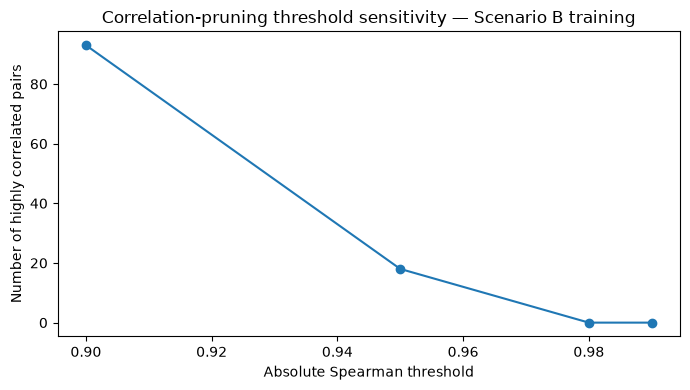

In [23]:
def classify_feature(feature):
    if feature.startswith("TRAFFIC_"):
        return "Traffic history" if ("_LAG_" in feature or "_ROLL_" in feature) else "Traffic current"

    if feature.startswith("NEIGHBOR_"):
        return "Neighbour aggregate / interaction"

    if any(feature.startswith(f"{station}_") for station in NEIGHBOUR_STATIONS):
        return "Neighbour station history" if ("_LAG_" in feature or "_ROLL_" in feature) else "Neighbour station current"

    if feature.startswith("ROZELLE_"):
        return "Rozelle history" if ("_LAG_" in feature or "_ROLL_" in feature) else "Rozelle current"

    if feature in [
        "HOUR", "DAY_OF_WEEK", "MONTH", "DAY_OF_YEAR", "IS_WEEKEND",
        "HOUR_SIN", "HOUR_COS", "DOW_SIN", "DOW_COS", "MONTH_SIN", "MONTH_COS",
    ]:
        return "Time"

    return "Other"


def show_scenario_features(name, X_train, X_val, X_test):
    table = pd.DataFrame({"feature": list(X_train.columns)})
    table["group"] = table["feature"].map(classify_feature)
    groups = table.groupby("group", as_index=False).agg(feature_count=("feature", "count"))

    print("\n" + "=" * 78)
    print(name)
    print("=" * 78)
    print("Train shape     :", X_train.shape)
    print("Validation shape:", X_val.shape)
    print("Test shape      :", X_test.shape)
    print("\nFeature groups:")
    display(groups.sort_values("feature_count", ascending=False))
    print("\nExact final feature names:")
    display(table.sort_values(["group", "feature"]).reset_index(drop=True))

    table.to_csv(exports_dir / f"features_{name}.csv", index=False)

    return {
        "scenario": name,
        "train_shape": str(X_train.shape),
        "validation_shape": str(X_val.shape),
        "test_shape": str(X_test.shape),
        "feature_count": X_train.shape[1],
    }


shape_rows = [
    show_scenario_features("A_local_only", Xa_train, Xa_val, Xa_test),
    show_scenario_features("B_local_plus_neighbours", Xb_train, Xb_val, Xb_test),
]

if SCENARIO_C_AVAILABLE:
    shape_rows.append(
        show_scenario_features("C_neighbours_plus_traffic", Xc_train, Xc_val, Xc_test)
    )

scenario_shape_df = pd.DataFrame(shape_rows)
display(scenario_shape_df)
scenario_shape_df.to_csv(exports_dir / "scenario_final_shapes.csv", index=False)

# Automatic scenario safety checks.
def has_neighbour(columns):
    return any(
        col.startswith("NEIGHBOR_")
        or any(col.startswith(f"{station}_") for station in NEIGHBOUR_STATIONS)
        for col in columns
    )


def has_traffic(columns):
    return any(col.startswith("TRAFFIC_") for col in columns)


assert not has_neighbour(Xa_train.columns), "Scenario A accidentally contains neighbour features."
assert not has_traffic(Xa_train.columns), "Scenario A accidentally contains traffic features."
assert has_neighbour(Xb_train.columns), "Scenario B should contain neighbour features."
assert not has_traffic(Xb_train.columns), "Scenario B accidentally contains traffic features."

if SCENARIO_C_AVAILABLE:
    assert has_neighbour(Xc_train.columns), "Scenario C should contain neighbour features."
    assert has_traffic(Xc_train.columns), "Scenario C should contain traffic features."

print("Scenario feature safety checks: PASSED")

# Show why 0.98 is a conservative redundancy threshold.
def correlation_threshold_sensitivity(X, thresholds=(0.90, 0.95, 0.98, 0.99)):
    corr = X.select_dtypes(include=[np.number]).corr(method="spearman").abs()
    mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    upper = corr.where(mask).stack()
    return pd.DataFrame({
        "threshold": thresholds,
        "feature_pairs_at_or_above": [int((upper >= t).sum()) for t in thresholds],
    })

threshold_sensitivity_df = correlation_threshold_sensitivity(Xb_train)
display(threshold_sensitivity_df)

plt.figure(figsize=(7, 4))
plt.plot(
    threshold_sensitivity_df["threshold"],
    threshold_sensitivity_df["feature_pairs_at_or_above"],
    marker="o",
)
plt.xlabel("Absolute Spearman threshold")
plt.ylabel("Number of highly correlated pairs")
plt.title("Correlation-pruning threshold sensitivity — Scenario B training")
plt.tight_layout()
plt.show()


## 10. Model helpers

In [24]:
def make_feature_scaler(name):
    """Return a feature scaler selected by validation evidence."""
    if name == "standard":
        return StandardScaler()
    if name == "robust":
        return RobustScaler()
    raise ValueError("Scaler must be 'standard' or 'robust'.")


def run_tabular_model(model, X_train, y_train, X_eval, scale=False):
    """
    Learned preprocessing is fitted on X_train only.
    Physically plausible extremes are not clipped automatically.
    """
    steps = [("imputer", build_imputer())]

    if scale:
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))
    pipe = Pipeline(steps)

    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    seconds = time.perf_counter() - t0

    return pipe, pipe.predict(X_eval), seconds


def train_rf(seed, params=None):
    final = {
        "n_estimators": 300,
        "max_depth": 16,
        "min_samples_leaf": 2,
        "max_features": RF_MAX_FEATURES,
    }
    if params:
        final.update(params)

    return RandomForestRegressor(
        random_state=seed,
        n_jobs=-1,
        **final,
    )


def train_xgb(seed, params=None):
    if HAS_XGBOOST:
        final = {
            "n_estimators": 400,
            "learning_rate": .05,
            "max_depth": 6,
            "subsample": XGB_SUBSAMPLE,
            "colsample_bytree": XGB_COLSAMPLE,
            "objective": "reg:squarederror",
        }
        if params:
            final.update(params)

        return XGBRegressor(
            random_state=seed,
            n_jobs=-1,
            **final,
        )

    return HistGradientBoostingRegressor(
        learning_rate=.05,
        max_depth=6,
        max_iter=400,
        random_state=seed,
    )


def safe_pairs(y_true, y_pred):
    a = np.asarray(y_true, dtype=float)
    b = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    return a[mask], b[mask]


def regression_metrics(y_true, y_pred):
    y_true, y_pred = safe_pairs(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    eps = 1e-6
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape = np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100

    return {
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "SMAPE": float(smape),
        "MAPE": float(mape),
        "R2": float(r2_score(y_true, y_pred)),
    }


def evaluate_result(y_true, y_pred, scenario, model_name, seed=None, train_seconds=None):
    row = {
        "scenario": scenario,
        "model": model_name,
        "seed": seed,
        "train_seconds": train_seconds,
    }
    row.update(regression_metrics(y_true, y_pred))
    return row


def persistence_forecast(X_test, baseline_col="ROZELLE_PM25"):
    return X_test[baseline_col].values


def arima_grid_search(train_series, val_series, orders=None):
    orders = orders or [(p, d, q) for p in [1, 2, 3] for d in [0, 1] for q in [0, 1, 2]]
    rows = []

    for order in orders:
        try:
            t0 = time.perf_counter()
            fit = ARIMA(train_series, order=order).fit()
            pred = fit.forecast(steps=len(val_series))
            metrics = regression_metrics(val_series.values, pred.values)
            rows.append({"order": order, "seconds": time.perf_counter()-t0, **metrics})
        except Exception as error:
            rows.append({"order": order, "seconds": np.nan, "RMSE": np.nan, "error": repr(error)})

    result = pd.DataFrame(rows).sort_values("RMSE", na_position="last").reset_index(drop=True)
    valid = result[result["RMSE"].notna()]
    if valid.empty:
        raise RuntimeError("All ARIMA candidate orders failed.")
    return valid.iloc[0]["order"], result


def validation_grid_search(model_name, grid, factory, X_train, y_train, X_val, y_val):
    rows = []
    combinations = list(ParameterGrid(grid))
    print(f"{model_name}: {len(combinations)} validation candidates")

    for i, params in enumerate(combinations, start=1):
        _, pred, seconds = run_tabular_model(
            factory(TUNING_SEED, params=params),
            X_train,
            y_train,
            X_val,
        )
        metrics = regression_metrics(y_val, pred)
        rows.append({"candidate": i, "model": model_name, "seconds": seconds, **params, **metrics})
        print(f"[{i:02d}/{len(combinations):02d}] RMSE={metrics['RMSE']:.4f} | {params}")

    return pd.DataFrame(rows).sort_values(["RMSE", "MAE"]).reset_index(drop=True)


def shared_validation_grid_search(model_name, grid, factory, scenario_sets):
    """
    Select ONE shared parameter configuration using mean validation RMSE
    across A/B/C. This avoids tuning specifically for one scenario while
    keeping the final scenario ablation controlled.
    """
    rows = []
    combinations = list(ParameterGrid(grid))
    print(f"{model_name}: {len(combinations)} shared validation candidates")

    for i, params in enumerate(combinations, start=1):
        scenario_metrics = []

        for scenario, Xtr, ytr, Xv, yv in scenario_sets:
            _, pred, seconds = run_tabular_model(
                factory(TUNING_SEED, params=params),
                Xtr, ytr, Xv,
            )
            metrics = regression_metrics(yv, pred)
            scenario_metrics.append((scenario, metrics, seconds))

        row = {
            "candidate": i,
            "model": model_name,
            **params,
            "mean_validation_RMSE": np.mean([m["RMSE"] for _, m, _ in scenario_metrics]),
            "mean_validation_MAE": np.mean([m["MAE"] for _, m, _ in scenario_metrics]),
            "seconds_total": np.sum([s for _, _, s in scenario_metrics]),
        }

        for scenario, metrics, _ in scenario_metrics:
            row[f"{scenario}_RMSE"] = metrics["RMSE"]
            row[f"{scenario}_MAE"] = metrics["MAE"]

        rows.append(row)
        print(
            f"[{i:02d}/{len(combinations):02d}] "
            f"mean RMSE={row['mean_validation_RMSE']:.4f} | {params}"
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["mean_validation_RMSE", "mean_validation_MAE"])
        .reset_index(drop=True)
    )


## 10.1 Hyperparameter tuning and model parameter evidence

### Why tuning is separate from repeated seeds

- **Hyperparameter tuning** asks which settings work best on validation data.
- **Repeated seeds** ask whether the selected model remains stable when randomness changes.

### Leakage-safe tuning flow

```text
2019–2022 TRAIN
        ↓ fit candidate
2023 VALIDATION
        ↓ compare candidate performance
select configuration
        ↓
2024 TEST remains untouched
```

### Avoiding scenario-selection bias

A/B/C are intended to test the **added information**, so one scenario should not receive a hyperparameter configuration chosen only for itself.

For RF/XGBoost and LSTM/GRU, each candidate is therefore evaluated across the available scenarios and ranked by **mean validation RMSE across A/B/C**. One shared configuration is then frozen for final A/B/C comparison.

### Extreme-value scaling sensitivity

For LSTM/GRU, `StandardScaler` and `RobustScaler` are compared with the same compact recurrent architecture across the available scenarios. The scaler with the lower mean validation RMSE is retained. Each feature scaler is fitted on TRAIN only; validation and test data use `transform()` only. The target scaler is also fitted on the training target only. This follows the chronological, training-only scaling protocol used by Le et al. (2026).

### Preprocessing is already frozen

The imputation strategy and KEEP/MASK extreme treatment were selected in Section 6 before this search. Grid search therefore changes **model hyperparameters only**, not data-cleaning rules.

In [25]:
# ===============================================================
# 10.1 HYPERPARAMETER TUNING
# Shared A/B/C selection + DL scaler sensitivity
# ===============================================================

RF_BEST_PARAMS = {
    "n_estimators": 300,
    "max_depth": 16,
    "min_samples_leaf": 2,
}

XGB_BEST_PARAMS = {
    "n_estimators": 400,
    "learning_rate": 0.05,
    "max_depth": 6,
}

LSTM_BEST_PARAMS = {
    "units": 64,
    "dropout": 0.2,
    "learning_rate": 0.001,
    "batch_size": 128,
}

GRU_BEST_PARAMS = {
    "units": 64,
    "dropout": 0.2,
    "learning_rate": 0.001,
    "batch_size": 128,
}

tree_tuning_sets = [
    ("A", Xa_train, ya_train, Xa_val, ya_val),
    ("B", Xb_train, yb_train, Xb_val, yb_val),
]
if SCENARIO_C_AVAILABLE:
    tree_tuning_sets.append(("C", Xc_train, yc_train, Xc_val, yc_val))


# ===============================================================
# A. RANDOM FOREST + XGBOOST — SHARED A/B/C TUNING
# ===============================================================

rf_tuning_df = pd.DataFrame()
xgb_tuning_df = pd.DataFrame()

if RUN_HYPERPARAMETER_TUNING:
    print("Random Forest shared A/B/C validation search")

    rf_tuning_df = shared_validation_grid_search(
        "RandomForest",
        RF_PARAM_GRID,
        train_rf,
        tree_tuning_sets,
    )

    best_rf = rf_tuning_df.iloc[0]
    RF_BEST_PARAMS = {
        "n_estimators": int(best_rf["n_estimators"]),
        "max_depth": int(best_rf["max_depth"]),
        "min_samples_leaf": int(best_rf["min_samples_leaf"]),
    }

    print("\nSelected shared RF parameters:", RF_BEST_PARAMS)
    display(rf_tuning_df.head(10))
    rf_tuning_df.to_csv(exports_dir / "rf_shared_grid_search.csv", index=False)

    if HAS_XGBOOST:
        print("\nXGBoost shared A/B/C validation search")

        xgb_tuning_df = shared_validation_grid_search(
            "XGBoost",
            XGB_PARAM_GRID,
            train_xgb,
            tree_tuning_sets,
        )

        best_xgb = xgb_tuning_df.iloc[0]
        XGB_BEST_PARAMS = {
            "n_estimators": int(best_xgb["n_estimators"]),
            "learning_rate": float(best_xgb["learning_rate"]),
            "max_depth": int(best_xgb["max_depth"]),
        }

        print("Selected shared XGBoost parameters:", XGB_BEST_PARAMS)
        display(xgb_tuning_df.head(10))
        xgb_tuning_df.to_csv(exports_dir / "xgb_shared_grid_search.csv", index=False)


# ===============================================================
# B. DEEP-LEARNING DATA PREPARATION
# ===============================================================

def prepare_dl_tuning(train_df, val_df, features, scaler_name, sequence_length=24):
    imputer = build_imputer()

    Xtr = imputer.fit_transform(train_df[features])
    Xv = imputer.transform(val_df[features])

    scaler = make_feature_scaler(scaler_name)
    Xtr = scaler.fit_transform(Xtr)
    Xv = scaler.transform(Xv)

    y_scaler = StandardScaler()
    ytr = y_scaler.fit_transform(train_df[["TARGET_T_PLUS_1"]]).ravel()
    yv = y_scaler.transform(val_df[["TARGET_T_PLUS_1"]]).ravel()

    def make_sequences(X, y):
        xs, ys = [], []
        for end in range(sequence_length - 1, len(X)):
            start = end - sequence_length + 1
            xs.append(X[start:end + 1])
            ys.append(y[end])
        return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

    Xtr, ytr = make_sequences(Xtr, ytr)
    Xv, yv = make_sequences(Xv, yv)

    return Xtr, ytr, Xv, yv, y_scaler


def build_recurrent_candidate(kind, input_shape, params, seed=DEEP_TUNING_SEED):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = Sequential([Input(shape=input_shape)])

    if kind == "LSTM":
        model.add(LSTM(int(params["units"])))
    elif kind == "GRU":
        model.add(GRU(int(params["units"])))
    else:
        raise ValueError("kind must be 'LSTM' or 'GRU'")

    model.add(Dropout(float(params["dropout"])))
    model.add(Dense(DEEP_DENSE_UNITS, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=float(params["learning_rate"])
        ),
        loss="mse",
    )
    return model


def fit_dl_candidate(kind, params, Xtr, ytr, Xv, yv, y_scaler):
    model = build_recurrent_candidate(kind, Xtr.shape[1:], params)

    stop = EarlyStopping(
        monitor="val_loss",
        patience=DEEP_PATIENCE,
        restore_best_weights=True,
    )

    t0 = time.perf_counter()
    history = model.fit(
        Xtr,
        ytr,
        validation_data=(Xv, yv),
        epochs=DEEP_EPOCHS,
        batch_size=int(params["batch_size"]),
        callbacks=[stop],
        verbose=0,
        shuffle=False,
    )
    seconds = time.perf_counter() - t0

    pred_scaled = model.predict(Xv, verbose=0).reshape(-1, 1)
    pred = y_scaler.inverse_transform(pred_scaled).ravel()
    true = y_scaler.inverse_transform(yv.reshape(-1, 1)).ravel()

    metrics = regression_metrics(true, pred)
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1

    return metrics, best_epoch, len(history.history["loss"]), seconds


deep_tuning_sets = [
    ("A", a_train, a_val, list(Xa_train.columns)),
    ("B", b_train, b_val, list(Xb_train.columns)),
]
if SCENARIO_C_AVAILABLE:
    deep_tuning_sets.append(("C", c_train, c_val, list(Xc_train.columns)))


# ===============================================================
# C. STANDARD vs ROBUST SCALER — VALIDATION EVIDENCE
# ===============================================================

deep_scaler_sensitivity_df = pd.DataFrame()

if RUN_DEEP_LEARNING:
    scaler_rows = []

    # Fixed compact architecture so only the scaler changes.
    scaler_probe_params = {
        "units": 32,
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 64,
    }

    for scaler_name in DEEP_SCALER_CANDIDATES:
        for scenario, tr, va, features in deep_tuning_sets:
            Xtr, ytr, Xv, yv, yscaler = prepare_dl_tuning(
                tr, va, features, scaler_name, SEQUENCE_LENGTH
            )

            for kind in ["LSTM", "GRU"]:
                metrics, best_epoch, epochs_ran, seconds = fit_dl_candidate(
                    kind,
                    scaler_probe_params,
                    Xtr, ytr, Xv, yv,
                    yscaler,
                )

                scaler_rows.append({
                    "scaler": scaler_name,
                    "scenario": scenario,
                    "model": kind,
                    "best_epoch": best_epoch,
                    "epochs_ran": epochs_ran,
                    "seconds": seconds,
                    **metrics,
                })

    deep_scaler_sensitivity_df = pd.DataFrame(scaler_rows)

    scaler_summary = (
        deep_scaler_sensitivity_df
        .groupby("scaler", as_index=False)
        .agg(
            mean_validation_RMSE=("RMSE", "mean"),
            mean_validation_MAE=("MAE", "mean"),
        )
        .sort_values(["mean_validation_RMSE", "mean_validation_MAE"])
        .reset_index(drop=True)
    )

    DEEP_SCALER = scaler_summary.iloc[0]["scaler"]

    print("\nDeep-learning scaler sensitivity:")
    display(deep_scaler_sensitivity_df)
    display(scaler_summary)
    print("Selected feature scaler:", DEEP_SCALER)

    deep_scaler_sensitivity_df.to_csv(
        exports_dir / "deep_scaler_sensitivity_runs.csv",
        index=False,
    )
    scaler_summary.to_csv(
        exports_dir / "deep_scaler_sensitivity_summary.csv",
        index=False,
    )


# ===============================================================
# D. SHARED LSTM / GRU HYPERPARAMETER SEARCH
# ===============================================================

def shared_deep_grid_search(kind, grid):
    rows = []
    combinations = list(ParameterGrid(grid))
    print(f"\n{kind}: {len(combinations)} shared A/B/C candidates")

    for i, params in enumerate(combinations, start=1):
        scenario_results = []

        for scenario, tr, va, features in deep_tuning_sets:
            Xtr, ytr, Xv, yv, yscaler = prepare_dl_tuning(
                tr, va, features, DEEP_SCALER, SEQUENCE_LENGTH
            )

            metrics, best_epoch, epochs_ran, seconds = fit_dl_candidate(
                kind, params, Xtr, ytr, Xv, yv, yscaler
            )

            scenario_results.append(
                (scenario, metrics, best_epoch, epochs_ran, seconds)
            )

        row = {
            "candidate": i,
            "model": kind,
            "units": int(params["units"]),
            "dropout": float(params["dropout"]),
            "learning_rate": float(params["learning_rate"]),
            "batch_size": int(params["batch_size"]),
            "mean_validation_RMSE": np.mean([r[1]["RMSE"] for r in scenario_results]),
            "mean_validation_MAE": np.mean([r[1]["MAE"] for r in scenario_results]),
            "mean_best_epoch": np.mean([r[2] for r in scenario_results]),
            "seconds_total": np.sum([r[4] for r in scenario_results]),
        }

        for scenario, metrics, best_epoch, _, _ in scenario_results:
            row[f"{scenario}_RMSE"] = metrics["RMSE"]
            row[f"{scenario}_best_epoch"] = best_epoch

        rows.append(row)

        print(
            f"[{i:02d}/{len(combinations):02d}] "
            f"mean RMSE={row['mean_validation_RMSE']:.4f} | {params}"
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["mean_validation_RMSE", "mean_validation_MAE"])
        .reset_index(drop=True)
    )


lstm_tuning_df = pd.DataFrame()
gru_tuning_df = pd.DataFrame()

if RUN_DEEP_LEARNING and RUN_DEEP_HYPERPARAMETER_TUNING:
    lstm_tuning_df = shared_deep_grid_search("LSTM", DEEP_PARAM_GRID)
    best_lstm = lstm_tuning_df.iloc[0]

    LSTM_BEST_PARAMS = {
        "units": int(best_lstm["units"]),
        "dropout": float(best_lstm["dropout"]),
        "learning_rate": float(best_lstm["learning_rate"]),
        "batch_size": int(best_lstm["batch_size"]),
    }

    print("\nSelected shared LSTM parameters:", LSTM_BEST_PARAMS)
    display(lstm_tuning_df.head(10))
    lstm_tuning_df.to_csv(exports_dir / "lstm_shared_grid_search.csv", index=False)

    gru_tuning_df = shared_deep_grid_search("GRU", DEEP_PARAM_GRID)
    best_gru = gru_tuning_df.iloc[0]

    GRU_BEST_PARAMS = {
        "units": int(best_gru["units"]),
        "dropout": float(best_gru["dropout"]),
        "learning_rate": float(best_gru["learning_rate"]),
        "batch_size": int(best_gru["batch_size"]),
    }

    print("\nSelected shared GRU parameters:", GRU_BEST_PARAMS)
    display(gru_tuning_df.head(10))
    gru_tuning_df.to_csv(exports_dir / "gru_shared_grid_search.csv", index=False)

elif not RUN_DEEP_LEARNING:
    print("TensorFlow unavailable — LSTM/GRU tuning skipped.")


# ===============================================================
# E. FINAL PARAMETER TABLE
# ===============================================================

model_parameter_rows = [
    ["RandomForest", "n_estimators", RF_BEST_PARAMS["n_estimators"], "Shared A/B/C validation grid search"],
    ["RandomForest", "max_depth", RF_BEST_PARAMS["max_depth"], "Shared A/B/C validation grid search"],
    ["RandomForest", "min_samples_leaf", RF_BEST_PARAMS["min_samples_leaf"], "Shared A/B/C validation grid search"],
    ["RandomForest", "max_features", RF_MAX_FEATURES, "Fixed"],

    ["XGBoost", "n_estimators", XGB_BEST_PARAMS["n_estimators"], "Shared A/B/C validation grid search"],
    ["XGBoost", "learning_rate", XGB_BEST_PARAMS["learning_rate"], "Shared A/B/C validation grid search"],
    ["XGBoost", "max_depth", XGB_BEST_PARAMS["max_depth"], "Shared A/B/C validation grid search"],
    ["XGBoost", "subsample", XGB_SUBSAMPLE, "Fixed"],
    ["XGBoost", "colsample_bytree", XGB_COLSAMPLE, "Fixed"],

    ["LSTM", "units", LSTM_BEST_PARAMS["units"], "Shared A/B/C validation grid search"],
    ["LSTM", "dropout", LSTM_BEST_PARAMS["dropout"], "Shared A/B/C validation grid search"],
    ["LSTM", "learning_rate", LSTM_BEST_PARAMS["learning_rate"], "Shared A/B/C validation grid search"],
    ["LSTM", "batch_size", LSTM_BEST_PARAMS["batch_size"], "Shared A/B/C validation grid search"],

    ["GRU", "units", GRU_BEST_PARAMS["units"], "Shared A/B/C validation grid search"],
    ["GRU", "dropout", GRU_BEST_PARAMS["dropout"], "Shared A/B/C validation grid search"],
    ["GRU", "learning_rate", GRU_BEST_PARAMS["learning_rate"], "Shared A/B/C validation grid search"],
    ["GRU", "batch_size", GRU_BEST_PARAMS["batch_size"], "Shared A/B/C validation grid search"],

    ["LSTM / GRU", "feature_scaler", DEEP_SCALER, "Validation sensitivity across scenarios"],
    ["LSTM / GRU", "sequence_length", SEQUENCE_LENGTH, "ACF + reference-study temporal context"],
    ["LSTM / GRU", "dense_units", DEEP_DENSE_UNITS, "Fixed compact architecture"],
    ["LSTM / GRU", "maximum_epochs", DEEP_EPOCHS, "Maximum + EarlyStopping"],
    ["LSTM / GRU", "early_stopping_patience", DEEP_PATIENCE, "Validation-loss control"],
]

model_parameter_df = pd.DataFrame(
    model_parameter_rows,
    columns=["model", "parameter", "value", "selection"],
)

print("\nFinal selected model parameters:")
display(model_parameter_df)
model_parameter_df.to_csv(exports_dir / "model_parameter_table.csv", index=False)

Random Forest shared A/B/C validation search
RandomForest: 8 shared validation candidates
[01/08] mean RMSE=3.0651 | {'max_depth': 12, 'min_samples_leaf': 1, 'n_estimators': 200}
[02/08] mean RMSE=3.0591 | {'max_depth': 12, 'min_samples_leaf': 1, 'n_estimators': 300}
[03/08] mean RMSE=3.0512 | {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 200}
[04/08] mean RMSE=3.0503 | {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 300}
[05/08] mean RMSE=3.0432 | {'max_depth': 16, 'min_samples_leaf': 1, 'n_estimators': 200}
[06/08] mean RMSE=3.0392 | {'max_depth': 16, 'min_samples_leaf': 1, 'n_estimators': 300}
[07/08] mean RMSE=3.0328 | {'max_depth': 16, 'min_samples_leaf': 2, 'n_estimators': 200}
[08/08] mean RMSE=3.0335 | {'max_depth': 16, 'min_samples_leaf': 2, 'n_estimators': 300}

Selected shared RF parameters: {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 2}


,candidate,model,max_depth,min_samples_leaf,n_estimators,mean_validation_RMSE,mean_validation_MAE,seconds_total,A_RMSE,A_MAE,B_RMSE,B_MAE,C_RMSE,C_MAE
0,7,RandomForest,16,2,200,3.032835,1.666697,166.244506,3.007149,1.676844,3.056977,1.659920,3.034378,1.663327
1,8,RandomForest,16,2,300,3.033458,1.665060,251.968399,3.007424,1.673504,3.054774,1.661003,3.038177,1.660673
2,6,RandomForest,16,1,300,3.039214,1.672307,260.640061,3.009522,1.680431,3.043094,1.667873,3.065026,1.668618
3,5,RandomForest,16,1,200,3.043227,1.674226,178.885042,3.008782,1.679880,3.047355,1.671301,3.073545,1.671496
4,4,RandomForest,12,2,300,3.050344,1.684369,192.934009,3.018716,1.689995,3.056780,1.682749,3.075536,1.680364
5,3,RandomForest,12,2,200,3.051153,1.684773,132.255088,3.022780,1.691157,3.061342,1.683613,3.069337,1.679549
6,2,RandomForest,12,1,300,3.059149,1.690084,199.994101,3.030915,1.697092,3.067298,1.685777,3.079233,1.687384
7,1,RandomForest,12,1,200,3.065123,1.690474,131.878553,3.031751,1.698278,3.078558,1.685318,3.085059,1.687827



XGBoost shared A/B/C validation search
XGBoost: 8 shared validation candidates
[01/08] mean RMSE=2.9083 | {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300}
[02/08] mean RMSE=2.8775 | {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 450}
[03/08] mean RMSE=2.8575 | {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 300}
[04/08] mean RMSE=2.8451 | {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 450}
[05/08] mean RMSE=2.8643 | {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
[06/08] mean RMSE=2.8513 | {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 450}
[07/08] mean RMSE=2.8751 | {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}
[08/08] mean RMSE=2.8727 | {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 450}
Selected shared XGBoost parameters: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 6}


,candidate,model,learning_rate,max_depth,n_estimators,mean_validation_RMSE,mean_validation_MAE,seconds_total,A_RMSE,A_MAE,B_RMSE,B_MAE,C_RMSE,C_MAE
0,4,XGBoost,0.03,6,450,2.845098,1.596904,24.859609,2.868126,1.613950,2.834630,1.590329,2.832538,1.586434
1,6,XGBoost,0.05,4,450,2.851315,1.613327,15.442839,2.847368,1.614307,2.826673,1.609306,2.879904,1.616369
2,3,XGBoost,0.03,6,300,2.857475,1.611058,17.127745,2.883684,1.629945,2.843444,1.601921,2.845296,1.601307
3,5,XGBoost,0.05,4,300,2.864344,1.625486,10.969545,2.865672,1.630619,2.840978,1.617397,2.886382,1.628442
4,8,XGBoost,0.05,6,450,2.872680,1.593714,25.393641,2.900597,1.612824,2.852879,1.591410,2.864563,1.576908
5,7,XGBoost,0.05,6,300,2.875094,1.595989,17.077509,2.899447,1.613441,2.854624,1.592142,2.871212,1.582386
6,2,XGBoost,0.03,4,450,2.877474,1.628921,15.602393,2.898157,1.641177,2.859428,1.620521,2.874837,1.625064
7,1,XGBoost,0.03,4,300,2.908310,1.652941,12.175411,2.921359,1.666735,2.890577,1.643840,2.912994,1.648247




Deep-learning scaler sensitivity:


...

,candidate,model,units,dropout,learning_rate,batch_size,mean_validation_RMSE,mean_validation_MAE,mean_best_epoch,seconds_total,A_RMSE,A_best_epoch,B_RMSE,B_best_epoch,C_RMSE,C_best_epoch
0,4,LSTM,64,0.1,0.0005,64,3.063934,1.753653,15.333333,222.917940,3.003384,10,3.069652,17,3.118765,19
1,12,LSTM,64,0.1,0.0005,128,3.109032,1.775208,17.333333,189.427301,2.995630,16,2.987913,26,3.343552,10
2,6,LSTM,64,0.2,0.0010,64,3.143984,1.759202,11.666667,187.782416,3.012398,8,3.286424,11,3.133130,16
3,8,LSTM,64,0.2,0.0005,64,3.153972,1.773935,11.333333,176.138920,2.966960,18,3.163398,9,3.331557,7
4,14,LSTM,64,0.2,0.0010,128,3.157755,1.780201,11.000000,141.672974,2.989445,10,3.216342,14,3.267478,9
5,2,LSTM,64,0.1,0.0010,64,3.168107,1.748450,11.666667,181.070717,3.036449,12,3.312392,9,3.155479,14
6,15,LSTM,32,0.2,0.0005,128,3.171004,1.782012,26.000000,155.667709,3.070665,25,3.271616,30,3.170730,23
7,3,LSTM,32,0.1,0.0005,64,3.181420,1.813697,14.000000,153.705966,3.141144,9,3.077608,24,3.325508,9
8,10,LSTM,64,0.1,0.0010,128,3.182998,1.784741,12.666667,154.778751,3.098504,8,3.293681,16,3.156810,14
9,5,LSTM,32,0.2,0.0010,64,3.212807,1.830152,11.333333,133.022675,2.966044,13,3.287326,11,3.385052,10



GRU: 16 shared A/B/C candidates
[01/16] mean RMSE=3.3293 | {'batch_size': 64, 'dropout': 0.1, 'learning_rate': 0.001, 'units': 32}
[02/16] mean RMSE=3.2075 | {'batch_size': 64, 'dropout': 0.1, 'learning_rate': 0.001, 'units': 64}
[03/16] mean RMSE=3.1726 | {'batch_size': 64, 'dropout': 0.1, 'learning_rate': 0.0005, 'units': 32}
[04/16] mean RMSE=3.0593 | {'batch_size': 64, 'dropout': 0.1, 'learning_rate': 0.0005, 'units': 64}
[05/16] mean RMSE=3.2482 | {'batch_size': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'units': 32}
[06/16] mean RMSE=3.2226 | {'batch_size': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'units': 64}
[07/16] mean RMSE=3.1358 | {'batch_size': 64, 'dropout': 0.2, 'learning_rate': 0.0005, 'units': 32}
[08/16] mean RMSE=3.0455 | {'batch_size': 64, 'dropout': 0.2, 'learning_rate': 0.0005, 'units': 64}
[09/16] mean RMSE=3.3380 | {'batch_size': 128, 'dropout': 0.1, 'learning_rate': 0.001, 'units': 32}
[10/16] mean RMSE=3.1886 | {'batch_size': 128, 'dropout': 0.1, 'learnin

,candidate,model,units,dropout,learning_rate,batch_size,mean_validation_RMSE,mean_validation_MAE,mean_best_epoch,seconds_total,A_RMSE,A_best_epoch,B_RMSE,B_best_epoch,C_RMSE,C_best_epoch
0,12,GRU,64,0.1,0.0005,128,3.012679,1.731139,23.000000,240.151853,2.973166,19,3.035885,25,3.028988,25
1,8,GRU,64,0.2,0.0005,64,3.045524,1.719673,18.333333,267.205167,3.021760,15,3.030975,21,3.083838,19
2,4,GRU,64,0.1,0.0005,64,3.059277,1.736141,16.666667,248.249903,2.984105,16,3.081917,14,3.111810,20
3,15,GRU,32,0.2,0.0005,128,3.073826,1.770923,19.333333,141.977784,2.955995,20,3.121315,21,3.144166,17
4,16,GRU,64,0.2,0.0005,128,3.102320,1.755482,19.000000,202.873992,3.053337,17,3.154763,23,3.098861,17
5,11,GRU,32,0.1,0.0005,128,3.104784,1.779970,19.333333,141.622444,2.978883,21,3.213312,18,3.122159,19
6,7,GRU,32,0.2,0.0005,64,3.135814,1.819323,13.000000,155.969654,2.978352,12,3.273936,13,3.155154,14
7,3,GRU,32,0.1,0.0005,64,3.172602,1.809562,14.333333,167.969897,2.945951,15,3.339582,10,3.232273,18
8,10,GRU,64,0.1,0.0010,128,3.188551,1.847332,9.333333,124.892279,3.108813,5,3.336845,10,3.119994,13
9,2,GRU,64,0.1,0.0010,64,3.207532,1.824724,5.666667,123.967914,3.113350,4,3.262149,5,3.247098,8



Final selected model parameters:


,model,parameter,value,selection
0,RandomForest,n_estimators,200,Shared A/B/C validation grid search
1,RandomForest,max_depth,16,Shared A/B/C validation grid search
2,RandomForest,min_samples_leaf,2,Shared A/B/C validation grid search
3,RandomForest,max_features,0.7,Fixed
4,XGBoost,n_estimators,450,Shared A/B/C validation grid search
5,XGBoost,learning_rate,0.03,Shared A/B/C validation grid search
6,XGBoost,max_depth,6,Shared A/B/C validation grid search
7,XGBoost,subsample,0.9,Fixed
8,XGBoost,colsample_bytree,0.9,Fixed
9,LSTM,units,64,Shared A/B/C validation grid search


## 11. Model training

### Why several model families are compared
Different models learn different kinds of patterns.

- **Persistence** asks whether simply using the current PM2.5 is already a strong baseline.
- **ARIMA** models the PM2.5 time series itself.
- **Random Forest** captures nonlinear relationships and interactions.
- **XGBoost** builds trees sequentially to correct earlier errors.
- **LSTM / GRU** learn patterns from ordered 24-hour sequences.
- **Hybrid ARIMA + RF** combines a statistical time-series component with nonlinear residual learning.

The same chronological test period and the same evaluation metrics are used so the comparison is fair.

### 11.1 Common baselines — Persistence and ARIMA

In [26]:
all_rows = []
prediction_store = {}
baseline_col = "ROZELLE_PM25"

# Persistence has no fitting step; training time is therefore 0.0.
persist = persistence_forecast(Xa_test, baseline_col)
all_rows.append(
    evaluate_result(
        ya_test,
        persist,
        "COMMON_BASELINE",
        "Persistence",
        train_seconds=0.0,
    )
)
prediction_store[("COMMON_BASELINE", "Persistence")] = (ya_test.values, persist)

# ARIMA is univariate and therefore a common baseline rather than a separate
# A/B/C model. Order is selected on TRAIN -> VALIDATION.
target_train_series = a_train.set_index("DATETIME")[baseline_col].dropna()
target_val_series = a_val.set_index("DATETIME")[baseline_col].dropna()
target_test_series = a_test.set_index("DATETIME")[baseline_col].dropna()

best_order, arima_tuning_df = arima_grid_search(target_train_series, target_val_series)
print("Best ARIMA order:", best_order)
display(arima_tuning_df.head(10))
arima_tuning_df.to_csv(exports_dir / "arima_grid_search.csv", index=False)

t0 = time.perf_counter()
arima_model = ARIMA(
    pd.concat([target_train_series, target_val_series]),
    order=best_order,
).fit()
arima_pred = arima_model.forecast(steps=len(target_test_series))
arima_seconds = time.perf_counter() - t0

all_rows.append(
    evaluate_result(
        target_test_series.values,
        arima_pred.values,
        "COMMON_BASELINE",
        f"ARIMA{best_order}",
        train_seconds=arima_seconds,
    )
)
prediction_store[("COMMON_BASELINE", f"ARIMA{best_order}")] = (
    target_test_series.values,
    arima_pred.values,
)


c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\MSI

Best ARIMA order: (3, 1, 2)


c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,order,seconds,MAE,MSE,RMSE,SMAPE,MAPE,R2
0,"(3, 1, 2)",9.526431,3.637420,40.043802,6.328017,54.839505,2.368808e+06,0.002310
1,"(2, 1, 1)",2.640639,3.637390,40.043867,6.328022,54.839185,2.368771e+06,0.002308
2,"(2, 1, 2)",3.543443,3.608075,40.143064,6.335855,54.535135,2.311407e+06,-0.000164
3,"(1, 1, 2)",2.254170,3.594934,40.212911,6.341365,54.400511,2.282044e+06,-0.001904
4,"(3, 1, 1)",4.289838,3.594164,40.216556,6.341652,54.392863,2.280396e+06,-0.001995
5,"(2, 0, 0)",0.880811,3.973370,40.893295,6.394787,58.234068,2.771586e+06,-0.018856
6,"(2, 0, 2)",10.998689,3.985017,40.904783,6.395685,58.295195,2.787998e+06,-0.019142
7,"(1, 0, 2)",3.068369,3.974496,40.909459,6.396050,58.243881,2.771631e+06,-0.019258
8,"(2, 0, 1)",2.747535,3.974583,40.910384,6.396123,58.244647,2.771660e+06,-0.019281
9,"(1, 0, 1)",1.737012,3.974844,40.914490,6.396444,58.246769,2.771610e+06,-0.019384


c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 11.2 Random Forest and XGBoost — 30 final-paper runs

With `PAPER_MODE=True`, final Random Forest and XGBoost results use 30 independent seeds (`1...30`) and are reported as mean ± standard deviation. Hyperparameters remain fixed across seeds and scenarios. This repeated-run reporting follows the robustness approach used by Le et al. (2026).


In [27]:
# Final tree models are refit on TRAIN + VALIDATION after tuning.
scenario_model_data = [
    ("A_local_only", Xa_train, ya_train, Xa_val, ya_val, Xa_test, ya_test),
    ("B_local_plus_neighbours", Xb_train, yb_train, Xb_val, yb_val, Xb_test, yb_test),
]

if SCENARIO_C_AVAILABLE:
    scenario_model_data.append(
        ("C_neighbours_plus_traffic", Xc_train, yc_train, Xc_val, yc_val, Xc_test, yc_test)
    )

xgb_name = "XGBoost" if HAS_XGBOOST else "HistGradientBoosting"

for seed in SEEDS:
    print(f"\nSeed {seed}")

    for scenario_name, Xtr, ytr, Xv, yv, Xte, yte in scenario_model_data:
        Xtrainval = pd.concat([Xtr, Xv], axis=0).reset_index(drop=True)
        ytrainval = pd.concat([ytr, yv], axis=0).reset_index(drop=True)

        # Random Forest
        _, pred_rf, sec_rf = run_tabular_model(
            train_rf(seed, RF_BEST_PARAMS),
            Xtrainval,
            ytrainval,
            Xte,
        )
        all_rows.append(
            evaluate_result(
                yte,
                pred_rf,
                scenario_name,
                "RandomForest",
                seed,
                sec_rf,
            )
        )
        prediction_store[(scenario_name, "RandomForest", seed)] = (yte.values, pred_rf)

        # XGBoost / fallback
        _, pred_xgb, sec_xgb = run_tabular_model(
            train_xgb(seed, XGB_BEST_PARAMS),
            Xtrainval,
            ytrainval,
            Xte,
        )
        all_rows.append(
            evaluate_result(
                yte,
                pred_xgb,
                scenario_name,
                xgb_name,
                seed,
                sec_xgb,
            )
        )
        prediction_store[(scenario_name, xgb_name, seed)] = (yte.values, pred_xgb)

        print(
            f"  {scenario_name:28s} | "
            f"RF RMSE={regression_metrics(yte, pred_rf)['RMSE']:.4f} | "
            f"{xgb_name} RMSE={regression_metrics(yte, pred_xgb)['RMSE']:.4f}"
        )



Seed 1
  A_local_only                 | RF RMSE=2.4065 | XGBoost RMSE=2.3800
  B_local_plus_neighbours      | RF RMSE=2.4037 | XGBoost RMSE=2.3743
  C_neighbours_plus_traffic    | RF RMSE=2.4039 | XGBoost RMSE=2.3789

Seed 2
  A_local_only                 | RF RMSE=2.4123 | XGBoost RMSE=2.3759
  B_local_plus_neighbours      | RF RMSE=2.4023 | XGBoost RMSE=2.3653
  C_neighbours_plus_traffic    | RF RMSE=2.4078 | XGBoost RMSE=2.3706

Seed 3
  A_local_only                 | RF RMSE=2.4097 | XGBoost RMSE=2.3829
  B_local_plus_neighbours      | RF RMSE=2.4041 | XGBoost RMSE=2.3698
  C_neighbours_plus_traffic    | RF RMSE=2.4099 | XGBoost RMSE=2.3734

Seed 4
  A_local_only                 | RF RMSE=2.4144 | XGBoost RMSE=2.3863
  B_local_plus_neighbours      | RF RMSE=2.4045 | XGBoost RMSE=2.3752
  C_neighbours_plus_traffic    | RF RMSE=2.4087 | XGBoost RMSE=2.3692

Seed 5
  A_local_only                 | RF RMSE=2.4086 | XGBoost RMSE=2.3790
  B_local_plus_neighbours      | RF RMSE=2.4076 | 

### 11.3 LSTM and GRU

LSTM and GRU use the shared hyperparameters and feature scaler selected in Section 10.1.

The recurrent input contains the previous `SEQUENCE_LENGTH = 24` hourly feature rows. This 24-hour context is retained because the ACF analysis and the neighbouring-air-quality reference study both support daily temporal dependence.

EarlyStopping monitors validation loss and restores the best epoch. It does **not** replace hyperparameter tuning; it controls when training stops for the selected architecture.

In [28]:
# ===============================================================
# 11.3 LSTM AND GRU — 30-SEED FINAL TRAINING
# Uses shared A/B/C tuned parameters and validation-selected scaler.
# Saves checkpoints after every completed run.
# ===============================================================

import gc

deep_histories = {}


# ===============================================================
# A. PREPARE DEEP-LEARNING DATA
# ===============================================================

def prepare_dl(
    train_df,
    val_df,
    test_df,
    features,
    sequence_length=24,
):
    """
    Prepare leakage-safe train, validation and test sequences.

    Protection:
    - imputer fitted on TRAIN only;
    - feature scaler fitted on TRAIN only;
    - target scaler fitted on TRAIN only;
    - validation and test use transform() only;
    - sequences contain only information available by time t.
    """

    imputer = build_imputer()

    Xtr = imputer.fit_transform(train_df[features])
    Xv = imputer.transform(val_df[features])
    Xte = imputer.transform(test_df[features])

    scaler = make_feature_scaler(DEEP_SCALER)

    Xtr = scaler.fit_transform(Xtr)
    Xv = scaler.transform(Xv)
    Xte = scaler.transform(Xte)

    yscaler = StandardScaler()

    ytr = yscaler.fit_transform(
        train_df[["TARGET_T_PLUS_1"]]
    ).ravel()

    yv = yscaler.transform(
        val_df[["TARGET_T_PLUS_1"]]
    ).ravel()

    yte = yscaler.transform(
        test_df[["TARGET_T_PLUS_1"]]
    ).ravel()

    def make_sequences(X, y):
        xs = []
        ys = []

        for end in range(sequence_length - 1, len(X)):
            start = end - sequence_length + 1
            xs.append(X[start:end + 1])
            ys.append(y[end])

        return (
            np.asarray(xs, dtype=np.float32),
            np.asarray(ys, dtype=np.float32),
        )

    Xtr, ytr = make_sequences(Xtr, ytr)
    Xv, yv = make_sequences(Xv, yv)
    Xte, yte = make_sequences(Xte, yte)

    return Xtr, ytr, Xv, yv, Xte, yte, yscaler


# ===============================================================
# B. BUILD FINAL RECURRENT MODEL
# ===============================================================

def build_recurrent(kind, input_shape, params, seed):
    """
    Build one deterministic-seed LSTM or GRU run using the
    validation-selected shared parameter configuration.
    """

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = Sequential([
        Input(shape=input_shape),
    ])

    if kind == "LSTM":
        model.add(
            LSTM(int(params["units"]))
        )
    elif kind == "GRU":
        model.add(
            GRU(int(params["units"]))
        )
    else:
        raise ValueError(
            "kind must be 'LSTM' or 'GRU'"
        )

    model.add(
        Dropout(float(params["dropout"]))
    )

    model.add(
        Dense(
            DEEP_DENSE_UNITS,
            activation="relu",
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=float(
                params["learning_rate"]
            )
        ),
        loss="mse",
    )

    return model


# ===============================================================
# C. CHECKPOINT HELPERS
# ===============================================================

def prediction_checkpoint_path(
    scenario_name,
    model_name,
    seed,
):
    safe_scenario = scenario_name.replace("/", "_")
    safe_model = model_name.replace("/", "_")

    return (
        DEEP_PREDICTION_DIR
        / f"{safe_scenario}__{safe_model}__seed_{seed:02d}.npz"
    )


def load_deep_checkpoint_results():
    if DEEP_RESULTS_FILE.exists():
        result = pd.read_csv(DEEP_RESULTS_FILE)

        if not result.empty:
            result["seed"] = result["seed"].astype(int)

        return result

    return pd.DataFrame()


def load_deep_history_results():
    if DEEP_HISTORY_FILE.exists():
        result = pd.read_csv(DEEP_HISTORY_FILE)

        if not result.empty:
            result["seed"] = result["seed"].astype(int)
            result["epoch"] = result["epoch"].astype(int)

        return result

    return pd.DataFrame()


def save_deep_checkpoints(
    result_rows,
    history_rows,
):
    result_df = pd.DataFrame(result_rows)

    if not result_df.empty:
        result_df = (
            result_df
            .drop_duplicates(
                subset=["scenario", "model", "seed"],
                keep="last",
            )
            .sort_values(
                ["scenario", "model", "seed"]
            )
            .reset_index(drop=True)
        )

        result_df.to_csv(
            DEEP_RESULTS_FILE,
            index=False,
        )

    history_df = pd.DataFrame(history_rows)

    if not history_df.empty:
        history_df = (
            history_df
            .drop_duplicates(
                subset=[
                    "scenario",
                    "model",
                    "seed",
                    "epoch",
                ],
                keep="last",
            )
            .sort_values(
                [
                    "scenario",
                    "model",
                    "seed",
                    "epoch",
                ]
            )
            .reset_index(drop=True)
        )

        history_df.to_csv(
            DEEP_HISTORY_FILE,
            index=False,
        )


# ===============================================================
# D. RESTORE COMPLETED RUNS
# ===============================================================

existing_deep_results = load_deep_checkpoint_results()
existing_deep_histories = load_deep_history_results()

deep_result_rows = (
    existing_deep_results
    .to_dict("records")
    if not existing_deep_results.empty
    else []
)

deep_history_rows = (
    existing_deep_histories
    .to_dict("records")
    if not existing_deep_histories.empty
    else []
)

completed_deep_runs = {
    (
        str(row["scenario"]),
        str(row["model"]),
        int(row["seed"]),
    )
    for row in deep_result_rows
}

print(
    "Previously completed deep-learning runs:",
    len(completed_deep_runs),
)


# Remove any LSTM/GRU rows already held in RAM before restoring
# checkpointed runs. This prevents duplicates when the cell is rerun.
all_rows = [
    row
    for row in all_rows
    if row.get("model") not in {"LSTM", "GRU"}
]

prediction_store = {
    key: value
    for key, value in prediction_store.items()
    if not (
        len(key) >= 2
        and key[1] in {"LSTM", "GRU"}
    )
}


# Restore checkpointed metrics.
for row in deep_result_rows:
    all_rows.append(row)


# Restore checkpointed predictions for downstream diagnostics.
for row in deep_result_rows:
    scenario_name = str(row["scenario"])
    model_name = str(row["model"])
    seed = int(row["seed"])

    pred_file = prediction_checkpoint_path(
        scenario_name,
        model_name,
        seed,
    )

    if pred_file.exists():
        saved = np.load(pred_file)

        prediction_store[
            (scenario_name, model_name, seed)
        ] = (
            saved["true"],
            saved["pred"],
        )


# Restore histories for downstream learning-curve analysis.
if deep_history_rows:
    history_frame = pd.DataFrame(deep_history_rows)

    for (
        scenario_name,
        model_name,
        seed,
    ), group in history_frame.groupby(
        ["scenario", "model", "seed"]
    ):
        group = group.sort_values("epoch")

        deep_histories[
            (
                str(scenario_name),
                str(model_name),
                int(seed),
            )
        ] = {
            "loss": group["loss"].tolist(),
            "val_loss": group["val_loss"].tolist(),
            "epochs_ran": int(group["epoch"].max()),
            "best_epoch": int(
                group.loc[
                    group["val_loss"].idxmin(),
                    "epoch",
                ]
            ),
        }


# ===============================================================
# E. FINAL 30-SEED TRAINING
# ===============================================================

if RUN_DEEP_LEARNING:

    deep_sets = [
        (
            "A_local_only",
            a_train,
            a_val,
            a_test,
            list(Xa_train.columns),
        ),
        (
            "B_local_plus_neighbours",
            b_train,
            b_val,
            b_test,
            list(Xb_train.columns),
        ),
    ]

    if SCENARIO_C_AVAILABLE:
        deep_sets.append(
            (
                "C_neighbours_plus_traffic",
                c_train,
                c_val,
                c_test,
                list(Xc_train.columns),
            )
        )

    total_required_runs = (
        len(deep_sets)
        * 2
        * len(DEEP_SEEDS)
    )

    print(
        "Required LSTM/GRU runs:",
        total_required_runs,
    )

    for (
        scenario_name,
        tr,
        va,
        te,
        features,
    ) in deep_sets:

        print("\n" + "=" * 78)
        print("Preparing sequences:", scenario_name)
        print("=" * 78)

        # Data preparation is independent of model seed.
        # It is therefore completed only once per scenario.
        (
            Xtr,
            ytr,
            Xv,
            yv,
            Xte,
            yte,
            yscaler,
        ) = prepare_dl(
            tr,
            va,
            te,
            features,
            SEQUENCE_LENGTH,
        )

        true = yscaler.inverse_transform(
            yte.reshape(-1, 1)
        ).ravel()

        print("Train sequence shape:", Xtr.shape)
        print("Validation sequence shape:", Xv.shape)
        print("Test sequence shape:", Xte.shape)

        for kind in ["LSTM", "GRU"]:

            best_params = (
                LSTM_BEST_PARAMS
                if kind == "LSTM"
                else GRU_BEST_PARAMS
            )

            print("\nModel:", kind)
            print("Parameters:", best_params)
            print("Feature scaler:", DEEP_SCALER)

            for seed in DEEP_SEEDS:

                run_key = (
                    scenario_name,
                    kind,
                    int(seed),
                )

                if run_key in completed_deep_runs:
                    print(
                        "Skipping completed run:",
                        run_key,
                    )
                    continue

                print("\n" + "-" * 70)
                print(
                    f"{scenario_name} / {kind} "
                    f"/ seed {seed}"
                )
                print("-" * 70)

                model = build_recurrent(
                    kind=kind,
                    input_shape=Xtr.shape[1:],
                    params=best_params,
                    seed=seed,
                )

                stop = EarlyStopping(
                    monitor="val_loss",
                    patience=DEEP_PATIENCE,
                    restore_best_weights=True,
                )

                t0 = time.perf_counter()

                history = model.fit(
                    Xtr,
                    ytr,
                    validation_data=(Xv, yv),
                    epochs=DEEP_EPOCHS,
                    batch_size=int(
                        best_params["batch_size"]
                    ),
                    callbacks=[stop],
                    verbose=0,
                    shuffle=False,
                )

                seconds = (
                    time.perf_counter() - t0
                )

                pred_scaled = model.predict(
                    Xte,
                    verbose=0,
                ).reshape(-1, 1)

                pred = yscaler.inverse_transform(
                    pred_scaled
                ).ravel()

                metrics = regression_metrics(
                    true,
                    pred,
                )

                best_epoch = (
                    int(
                        np.argmin(
                            history.history["val_loss"]
                        )
                    )
                    + 1
                )

                epochs_ran = len(
                    history.history["loss"]
                )

                result_row = evaluate_result(
                    true,
                    pred,
                    scenario_name,
                    kind,
                    seed,
                    seconds,
                )

                result_row.update({
                    "epochs_ran": epochs_ran,
                    "best_epoch": best_epoch,
                    "units": int(
                        best_params["units"]
                    ),
                    "dropout": float(
                        best_params["dropout"]
                    ),
                    "learning_rate": float(
                        best_params["learning_rate"]
                    ),
                    "batch_size": int(
                        best_params["batch_size"]
                    ),
                    "feature_scaler": DEEP_SCALER,
                    "sequence_length": (
                        SEQUENCE_LENGTH
                    ),
                })

                deep_result_rows.append(
                    result_row
                )

                all_rows.append(
                    result_row
                )

                prediction_store[run_key] = (
                    true.copy(),
                    pred.copy(),
                )

                np.savez_compressed(
                    prediction_checkpoint_path(
                        scenario_name,
                        kind,
                        seed,
                    ),
                    true=true,
                    pred=pred,
                )

                for epoch_index, (
                    train_loss,
                    validation_loss,
                ) in enumerate(
                    zip(
                        history.history["loss"],
                        history.history["val_loss"],
                    ),
                    start=1,
                ):
                    deep_history_rows.append({
                        "scenario": scenario_name,
                        "model": kind,
                        "seed": int(seed),
                        "epoch": epoch_index,
                        "loss": float(train_loss),
                        "val_loss": float(
                            validation_loss
                        ),
                    })

                deep_histories[run_key] = {
                    "loss": history.history[
                        "loss"
                    ],
                    "val_loss": history.history[
                        "val_loss"
                    ],
                    "epochs_ran": epochs_ran,
                    "best_epoch": best_epoch,
                    "parameters": (
                        best_params.copy()
                    ),
                }

                completed_deep_runs.add(
                    run_key
                )

                # Save immediately after every run.
                save_deep_checkpoints(
                    deep_result_rows,
                    deep_history_rows,
                )

                print(
                    f"Test RMSE: "
                    f"{metrics['RMSE']:.4f}"
                )
                print(
                    f"Test MAE : "
                    f"{metrics['MAE']:.4f}"
                )
                print(
                    f"Test R²  : "
                    f"{metrics['R2']:.4f}"
                )
                print(
                    "Epochs run:",
                    epochs_ran,
                )
                print(
                    "Best validation epoch:",
                    best_epoch,
                )
                print(
                    "Checkpoint saved:",
                    run_key,
                )

                del model
                del history
                del pred_scaled

                tf.keras.backend.clear_session()
                gc.collect()

        # Scenario arrays are released only after both model families
        # have completed for this scenario.
        del Xtr, ytr, Xv, yv, Xte, yte
        gc.collect()

    print("\nDeep-learning repeated runs completed.")
    print(
        "Completed runs:",
        len(completed_deep_runs),
    )
    print(
        "Metrics:",
        DEEP_RESULTS_FILE,
    )
    print(
        "Histories:",
        DEEP_HISTORY_FILE,
    )

else:
    print(
        "TensorFlow unavailable — "
        "LSTM/GRU skipped."
    )

Previously completed deep-learning runs: 0
Required LSTM/GRU runs: 180

Preparing sequences: A_local_only
Train sequence shape: (30798, 24, 131)
Validation sequence shape: (7489, 24, 131)
Test sequence shape: (7949, 24, 131)

Model: LSTM
Parameters: {'units': 64, 'dropout': 0.1, 'learning_rate': 0.0005, 'batch_size': 64}
Feature scaler: robust

----------------------------------------------------------------------
A_local_only / LSTM / seed 1
----------------------------------------------------------------------
Test RMSE: 2.5004
Test MAE : 1.7952
Test R²  : 0.6890
Epochs run: 23
Best validation epoch: 18
Checkpoint saved: ('A_local_only', 'LSTM', 1)

----------------------------------------------------------------------
A_local_only / LSTM / seed 2
----------------------------------------------------------------------
Test RMSE: 2.5320
Test MAE : 1.8400
Test R²  : 0.6811
Epochs run: 14
Best validation epoch: 9
Checkpoint saved: ('A_local_only', 'LSTM', 2)

----------------------------

### 11.4 Hybrid Random Forest + ARIMA residual correction

The optional hybrid is aligned with the **Random Forest + ARIMA residual-learning approach described by Yenkikar et al. (2025)**:

```text
Random Forest forecast
        ↓
residual = observed − RF forecast
        ↓
ARIMA models residual temporal structure
        ↓
final forecast = RF forecast + ARIMA residual correction
```

This direction is evidence-based for the present study because Random Forest already models nonlinear relationships among local pollution, meteorology, neighbouring stations and traffic. ARIMA is only asked to model **remaining temporal structure in RF errors**.

The residual ARIMA order is selected without using the 2024 test set. RF is first trained on 2019–2022 and predicts 2023 validation data. Those out-of-sample validation residuals are split chronologically to choose one shared residual-ARIMA order across A/B/C. The selected order is then fitted to all 2023 residuals and used to correct the final 2024 RF forecast.

A Ljung–Box diagnostic is also reported to show whether temporal autocorrelation remains in the RF residuals instead of assuming that the ARIMA correction must help.

In [29]:
# ===============================================================
# 11.4 HYBRID RANDOM FOREST + ARIMA RESIDUAL CORRECTION
# RF -> validation residual -> ARIMA correction
# ===============================================================

def validation_rf_residuals(Xtr, ytr, Xv, yv, seed=TUNING_SEED):
    """RF trained on TRAIN only; residuals are genuinely out-of-sample VALIDATION errors."""
    pipe, val_pred, _ = run_tabular_model(
        train_rf(seed, RF_BEST_PARAMS),
        Xtr, ytr, Xv,
    )

    residuals = np.asarray(yv, dtype=float) - np.asarray(val_pred, dtype=float)
    return np.asarray(val_pred, dtype=float), pd.Series(residuals).reset_index(drop=True)


def select_shared_residual_arima_order():
    """
    Select one residual ARIMA order using only validation residuals.
    Each validation residual series is split chronologically:
      first 70% -> residual-ARIMA fit
      last 30%  -> residual-ARIMA validation
    Candidate ranking uses mean hybrid RMSE across A/B/C.
    """
    sets = [
        ("A", Xa_train, ya_train, Xa_val, ya_val),
        ("B", Xb_train, yb_train, Xb_val, yb_val),
    ]
    if SCENARIO_C_AVAILABLE:
        sets.append(("C", Xc_train, yc_train, Xc_val, yc_val))

    cache = {}
    for scenario, Xtr, ytr, Xv, yv in sets:
        rf_val_pred, residuals = validation_rf_residuals(Xtr, ytr, Xv, yv)
        cache[scenario] = {
            "rf_val_pred": rf_val_pred,
            "residuals": residuals,
            "y_val": np.asarray(yv, dtype=float),
        }

    rows = []

    for order in HYBRID_ARIMA_ORDERS:
        row = {"order": order}
        scenario_rmse = []

        for scenario, *_ in sets:
            item = cache[scenario]
            residuals = item["residuals"]
            split = max(24, int(len(residuals) * 0.70))

            train_resid = residuals.iloc[:split]
            tail_resid = residuals.iloc[split:]
            rf_tail = item["rf_val_pred"][split:]
            y_tail = item["y_val"][split:]

            try:
                fit = ARIMA(train_resid, order=order).fit()
                correction = np.asarray(fit.forecast(steps=len(tail_resid)))
                hybrid_tail = rf_tail + correction
                rmse = regression_metrics(y_tail, hybrid_tail)["RMSE"]
            except Exception:
                rmse = np.nan

            row[f"{scenario}_RMSE"] = rmse
            scenario_rmse.append(rmse)

        row["mean_validation_RMSE"] = np.nanmean(scenario_rmse)
        rows.append(row)

    result = (
        pd.DataFrame(rows)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["mean_validation_RMSE"])
        .sort_values("mean_validation_RMSE")
        .reset_index(drop=True)
    )

    if result.empty:
        raise RuntimeError("All residual ARIMA candidate orders failed.")

    return result.iloc[0]["order"], result, cache


def run_rf_arima_hybrid(
    Xtr, ytr, Xv, yv, Xte, yte,
    residual_order,
    seed,
):
    """
    Final hybrid:
      1) TRAIN-only RF provides 2023 out-of-sample residuals for ARIMA.
      2) Final RF is refit on TRAIN+VALIDATION for the 2024 base forecast.
      3) ARIMA fitted to 2023 RF residuals forecasts the 2024 residual correction.
    """
    # Out-of-sample validation residual history for ARIMA.
    _, val_residuals = validation_rf_residuals(
        Xtr, ytr, Xv, yv, seed=seed
    )

    # Residual autocorrelation evidence.
    lb_lags = [lag for lag in [1, 6, 24] if lag < len(val_residuals)]
    lb = (
        acorr_ljungbox(val_residuals, lags=lb_lags, return_df=True)
        if lb_lags else pd.DataFrame()
    )

    # Final RF base forecast uses all pre-test data.
    Xtrainval = pd.concat([Xtr, Xv], ignore_index=True)
    ytrainval = pd.concat([ytr, yv], ignore_index=True)

    t0 = time.perf_counter()
    _, rf_test_pred, _ = run_tabular_model(
        train_rf(seed, RF_BEST_PARAMS),
        Xtrainval, ytrainval, Xte,
    )

    residual_fit = ARIMA(val_residuals, order=residual_order).fit()
    correction = np.asarray(
        residual_fit.forecast(steps=len(yte))
    )

    hybrid_pred = np.asarray(rf_test_pred) + correction
    seconds = time.perf_counter() - t0

    return hybrid_pred, seconds, lb


if RUN_HYBRID_MODEL:
    hybrid_order, hybrid_tuning_df, _ = select_shared_residual_arima_order()

    print("Selected shared residual ARIMA order:", hybrid_order)
    display(hybrid_tuning_df)
    hybrid_tuning_df.to_csv(
        exports_dir / "hybrid_residual_arima_tuning.csv",
        index=False,
    )

    hybrid_sets = [
        ("A_local_only", Xa_train, ya_train, Xa_val, ya_val, Xa_test, ya_test),
        ("B_local_plus_neighbours", Xb_train, yb_train, Xb_val, yb_val, Xb_test, yb_test),
    ]
    if SCENARIO_C_AVAILABLE:
        hybrid_sets.append(
            ("C_neighbours_plus_traffic", Xc_train, yc_train, Xc_val, yc_val, Xc_test, yc_test)
        )

    ljungbox_rows = []

    for seed in SEEDS:
        print(f"\nHybrid seed {seed}")

        for scenario_name, Xtr, ytr, Xv, yv, Xte, yte in hybrid_sets:
            pred, seconds, lb = run_rf_arima_hybrid(
                Xtr, ytr, Xv, yv, Xte, yte,
                hybrid_order,
                seed,
            )

            metrics = regression_metrics(yte, pred)

            all_rows.append(
                evaluate_result(
                    yte,
                    pred,
                    scenario_name,
                    "Hybrid_RF_ARIMA",
                    seed,
                    seconds,
                )
            )

            prediction_store[
                (scenario_name, "Hybrid_RF_ARIMA", seed)
            ] = (np.asarray(yte), pred)

            for lag, row in lb.iterrows():
                ljungbox_rows.append({
                    "scenario": scenario_name,
                    "seed": seed,
                    "lag": int(lag),
                    "lb_stat": float(row["lb_stat"]),
                    "lb_pvalue": float(row["lb_pvalue"]),
                })

            print(
                f"  {scenario_name:28s} | "
                f"RMSE={metrics['RMSE']:.4f} | "
                f"MAE={metrics['MAE']:.4f} | "
                f"R²={metrics['R2']:.4f}"
            )

    hybrid_ljungbox_df = pd.DataFrame(ljungbox_rows)

    if len(hybrid_ljungbox_df):
        print("\nLjung–Box evidence for RF validation residuals:")
        display(hybrid_ljungbox_df.head(30))
        hybrid_ljungbox_df.to_csv(
            exports_dir / "hybrid_rf_residual_ljungbox.csv",
            index=False,
        )
else:
    print("Hybrid RF + ARIMA disabled.")

Selected shared residual ARIMA order: (1, 0, 1)


,order,A_RMSE,B_RMSE,C_RMSE,mean_validation_RMSE
0,"(1, 0, 1)",2.095071,2.090122,2.089576,2.091590
1,"(2, 0, 0)",2.095076,2.090129,2.089579,2.091595
2,"(2, 0, 1)",2.095083,2.090153,2.089598,2.091611
3,"(1, 0, 0)",2.095148,2.090171,2.089538,2.091619
4,"(1, 1, 0)",2.159372,2.082831,2.083352,2.108518
5,"(2, 1, 0)",2.082947,2.121906,2.131521,2.112125
6,"(1, 1, 1)",2.200941,2.090308,2.089618,2.126956
7,"(2, 1, 1)",2.265947,2.102522,2.105890,2.158120



Hybrid seed 1
  A_local_only                 | RMSE=2.4071 | MAE=1.7466 | R²=0.7122
  B_local_plus_neighbours      | RMSE=2.4041 | MAE=1.7365 | R²=0.7129
  C_neighbours_plus_traffic    | RMSE=2.4044 | MAE=1.7376 | R²=0.7129

Hybrid seed 2
  A_local_only                 | RMSE=2.4129 | MAE=1.7496 | R²=0.7108
  B_local_plus_neighbours      | RMSE=2.4028 | MAE=1.7391 | R²=0.7133
  C_neighbours_plus_traffic    | RMSE=2.4084 | MAE=1.7410 | R²=0.7119

Hybrid seed 3
  A_local_only                 | RMSE=2.4102 | MAE=1.7491 | R²=0.7115
  B_local_plus_neighbours      | RMSE=2.4045 | MAE=1.7391 | R²=0.7129
  C_neighbours_plus_traffic    | RMSE=2.4102 | MAE=1.7406 | R²=0.7115

Hybrid seed 4
  A_local_only                 | RMSE=2.4149 | MAE=1.7506 | R²=0.7104
  B_local_plus_neighbours      | RMSE=2.4049 | MAE=1.7376 | R²=0.7128
  C_neighbours_plus_traffic    | RMSE=2.4089 | MAE=1.7429 | R²=0.7118

Hybrid seed 5
  A_local_only                 | RMSE=2.4091 | MAE=1.7483 | R²=0.7118
  B_local_plus_

,scenario,seed,lag,lb_stat,lb_pvalue
0,A_local_only,1,1,208.989184,2.282442e-47
1,A_local_only,1,6,310.655473,4.256778e-64
2,A_local_only,1,24,596.945273,1.032822e-110
3,B_local_plus_neighbours,1,1,256.157914,1.180382e-57
4,B_local_plus_neighbours,1,6,431.743334,4.164004e-90
5,B_local_plus_neighbours,1,24,696.891017,1.117521e-131
6,C_neighbours_plus_traffic,1,1,241.744742,1.637870e-54
7,C_neighbours_plus_traffic,1,6,428.308341,2.282992e-89
8,C_neighbours_plus_traffic,1,24,700.545668,1.903586e-132
9,A_local_only,2,1,208.151430,3.476801e-47


## 12. Results and research diagnostics

A single RMSE number is not enough for a research conclusion.

We examine:
- average error,
- variability across random seeds,
- actual versus predicted values,
- residual patterns,
- training versus validation behaviour,
- and whether scenario improvements are statistically consistent.

This helps distinguish a real improvement from a result that happened only because of random model initialization.

In [30]:
all_runs_df = pd.DataFrame(all_rows)

summary_df = (
    all_runs_df
    .groupby(["scenario", "model"], as_index=False)
    .agg(
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        MSE_mean=("MSE", "mean"),
        MSE_std=("MSE", "std"),
        SMAPE_mean=("SMAPE", "mean"),
        SMAPE_std=("SMAPE", "std"),
        MAPE_mean=("MAPE", "mean"),
        MAPE_std=("MAPE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std"),
        train_seconds_mean=("train_seconds", "mean"),
        train_seconds_std=("train_seconds", "std"),
        n_runs=("RMSE", "count"),
    )
    .sort_values("RMSE_mean")
    .reset_index(drop=True)
)

print(
    "RMSE is the primary ranking metric because large forecast errors are "
    "penalised more strongly. MAE, SMAPE and R² are interpreted alongside it. "
    "MAPE is reported but treated cautiously when PM2.5 is near zero."
)

display(summary_df)

all_runs_df.to_csv(exports_dir / "all_model_runs.csv", index=False)
summary_df.to_csv(exports_dir / "model_summary.csv", index=False)

RMSE is the primary ranking metric because large forecast errors are penalised more strongly. MAE, SMAPE and R² are interpreted alongside it. MAPE is reported but treated cautiously when PM2.5 is near zero.


,scenario,model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MSE_mean,MSE_std,SMAPE_mean,SMAPE_std,MAPE_mean,MAPE_std,R2_mean,R2_std,train_seconds_mean,train_seconds_std,n_runs
0,B_local_plus_neighbours,XGBoost,2.372428,0.005623,1.705798,0.002813,5.628443,0.026685,30.846120,0.030917,5.731230e+05,19963.561041,0.720464,0.001325,11.139040,0.316703,30
1,C_neighbours_plus_traffic,XGBoost,2.374238,0.006167,1.705275,0.002553,5.637041,0.029280,30.864864,0.028507,5.521638e+05,21315.377099,0.720037,0.001454,12.007424,0.280577,30
2,A_local_only,XGBoost,2.380324,0.004483,1.724728,0.002334,5.665962,0.021351,31.064812,0.033570,5.381672e+05,7944.045592,0.718601,0.001060,4.840458,0.151689,30
3,B_local_plus_neighbours,RandomForest,2.403992,0.002630,1.738184,0.001868,5.779186,0.012646,31.325683,0.031592,5.520657e+05,12227.263661,0.712977,0.000628,75.092110,1.950290,30
4,B_local_plus_neighbours,Hybrid_RF_ARIMA,2.404552,0.002633,1.738215,0.001869,5.781875,0.012664,31.325904,0.031536,5.518306e+05,12201.299852,0.712844,0.000629,78.851882,13.230655,30
5,C_neighbours_plus_traffic,RandomForest,2.406333,0.003815,1.738992,0.002174,5.790453,0.018361,31.325379,0.025879,5.421212e+05,11068.094046,0.712418,0.000912,85.172703,1.636418,30
6,C_neighbours_plus_traffic,Hybrid_RF_ARIMA,2.406792,0.003762,1.739098,0.002255,5.792663,0.018110,31.326166,0.026154,5.423186e+05,11068.391121,0.712308,0.000899,88.955838,12.816241,30
7,A_local_only,RandomForest,2.409807,0.002907,1.750236,0.001672,5.807176,0.014011,31.426595,0.025190,5.244712e+05,5656.419115,0.711587,0.000696,32.641344,0.729427,30
8,A_local_only,Hybrid_RF_ARIMA,2.410311,0.002893,1.749117,0.001679,5.809609,0.013946,31.416375,0.025305,5.208896e+05,5966.130242,0.711466,0.000693,34.425483,5.332355,30
9,A_local_only,LSTM,2.526096,0.046786,1.822480,0.031439,6.383275,0.237788,32.539374,0.431107,5.389286e+05,38696.127382,0.682430,0.011830,66.899093,14.547584,30


### High-PM2.5 forecast performance

The extreme-event audit is also linked back to model evaluation.

A threshold is learned from the **training target distribution only** (`95th percentile`). Each stored 2024 prediction is then evaluated separately for test observations whose true PM2.5 exceeds that threshold.

This checks whether a model that performs well overall also remains useful during high-pollution conditions, rather than allowing average performance to hide poor behaviour on important peaks.

In [31]:
high_pm25_threshold = float(
    pd.Series(ya_train).quantile(HIGH_PM25_EVAL_QUANTILE)
)

high_pm25_rows = []

for key, (true, pred) in prediction_store.items():
    if len(key) == 2:
        scenario, model = key
        seed = None
    else:
        scenario, model, seed = key

    true = np.asarray(true, dtype=float)
    pred = np.asarray(pred, dtype=float)

    n = min(len(true), len(pred))
    true, pred = true[:n], pred[:n]

    mask = np.isfinite(true) & np.isfinite(pred) & (true >= high_pm25_threshold)

    if mask.sum() < 20:
        continue

    metrics = regression_metrics(true[mask], pred[mask])

    high_pm25_rows.append({
        "scenario": scenario,
        "model": model,
        "seed": seed,
        "train_p95_threshold": high_pm25_threshold,
        "n_high_test_hours": int(mask.sum()),
        **metrics,
    })

high_pm25_df = pd.DataFrame(high_pm25_rows)

if len(high_pm25_df):
    high_pm25_summary = (
        high_pm25_df
        .groupby(["scenario", "model"], as_index=False)
        .agg(
            RMSE_mean=("RMSE", "mean"),
            MAE_mean=("MAE", "mean"),
            SMAPE_mean=("SMAPE", "mean"),
            R2_mean=("R2", "mean"),
            n_runs=("RMSE", "count"),
            high_hours=("n_high_test_hours", "max"),
        )
        .sort_values("RMSE_mean")
    )

    print(f"TRAIN-derived high-PM2.5 threshold: {high_pm25_threshold:.3f}")
    display(high_pm25_summary)

    high_pm25_df.to_csv(
        exports_dir / "high_pm25_model_runs.csv",
        index=False,
    )
    high_pm25_summary.to_csv(
        exports_dir / "high_pm25_model_summary.csv",
        index=False,
    )

TRAIN-derived high-PM2.5 threshold: 18.600


,scenario,model,RMSE_mean,MAE_mean,SMAPE_mean,R2_mean,n_runs,high_hours
4,A_local_only,XGBoost,6.268002,4.669706,24.164086,-0.379987,30,166
9,B_local_plus_neighbours,XGBoost,6.320481,4.764456,24.861516,-0.403197,30,166
16,C_neighbours_plus_traffic,XGBoost,6.333964,4.760026,24.838157,-0.409180,30,166
3,A_local_only,RandomForest,6.410641,4.887002,25.265228,-0.443484,30,166
1,A_local_only,Hybrid_RF_ARIMA,6.428193,4.899339,25.356761,-0.451399,30,166
15,C_neighbours_plus_traffic,RandomForest,6.562821,4.998435,26.191420,-0.512843,30,166
8,B_local_plus_neighbours,RandomForest,6.565475,5.013937,26.322310,-0.514057,30,166
13,C_neighbours_plus_traffic,Hybrid_RF_ARIMA,6.569642,5.000544,26.211557,-0.515989,30,166
6,B_local_plus_neighbours,Hybrid_RF_ARIMA,6.573838,5.017351,26.351629,-0.517915,30,166
2,A_local_only,LSTM,6.690410,5.150539,27.219534,-0.568972,30,165


### 12.1 Practical NSW PM2.5 alert detection

NSW DCCEEW classifies one-hour PM2.5 as **Poor** from `50 µg/m³`, with higher categories above that level. Here an alert hour means **Poor or worse** (`PM2.5 >= 50 µg/m³`). The same threshold is applied to the observed and predicted 2024 values.

Precision, recall, TP, FP, FN and TN are calculated from existing predictions; no model is retrained. Run-level results preserve each seed, and the model/scenario table reports mean ± standard deviation across available runs.

Source: [NSW Air Quality Categories](https://www.airquality.nsw.gov.au/health-advice/air-quality-categories).


In [32]:
def pm25_alert_metrics(y_true, y_pred, threshold):
    true, pred = safe_pairs(y_true, y_pred)
    actual_alert = true >= threshold
    predicted_alert = pred >= threshold

    tp = int(np.sum(actual_alert & predicted_alert))
    fp = int(np.sum(~actual_alert & predicted_alert))
    fn = int(np.sum(actual_alert & ~predicted_alert))
    tn = int(np.sum(~actual_alert & ~predicted_alert))

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan

    return {
        "Precision": float(precision),
        "Recall": float(recall),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "actual_alert_hours": int(actual_alert.sum()),
        "predicted_alert_hours": int(predicted_alert.sum()),
        "n_test_hours": int(len(true)),
    }


hazardous_hour_rows = []

for key, (true, pred) in prediction_store.items():
    if len(key) == 2:
        scenario, model = key
        seed = None
    else:
        scenario, model, seed = key

    hazardous_hour_rows.append({
        "scenario": scenario,
        "model": model,
        "seed": seed,
        "threshold_ug_m3": NSW_PM25_ALERT_THRESHOLD,
        **pm25_alert_metrics(
            true,
            pred,
            NSW_PM25_ALERT_THRESHOLD,
        ),
    })

hazardous_hour_runs_df = pd.DataFrame(hazardous_hour_rows)

if hazardous_hour_runs_df.empty:
    print("No stored predictions were available for NSW alert scoring.")
else:
    hazardous_hour_summary = (
        hazardous_hour_runs_df
        .groupby(["scenario", "model"], as_index=False)
        .agg(
            Precision_mean=("Precision", "mean"),
            Precision_std=("Precision", "std"),
            Recall_mean=("Recall", "mean"),
            Recall_std=("Recall", "std"),
            TP_mean=("TP", "mean"),
            FP_mean=("FP", "mean"),
            FN_mean=("FN", "mean"),
            TN_mean=("TN", "mean"),
            actual_alert_hours=("actual_alert_hours", "max"),
            n_runs=("model", "count"),
        )
        .sort_values(
            ["Recall_mean", "Precision_mean"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

    print(
        "NSW one-hour PM2.5 alert threshold: "
        f"{NSW_PM25_ALERT_THRESHOLD:.1f} µg/m³ (Poor or worse)"
    )
    display(hazardous_hour_summary)

    hazardous_hour_runs_df.to_csv(
        exports_dir / "nsw_pm25_alert_detection_runs.csv",
        index=False,
    )
    hazardous_hour_summary.to_csv(
        exports_dir / "nsw_pm25_alert_detection_summary.csv",
        index=False,
    )


NSW one-hour PM2.5 alert threshold: 50.0 µg/m³ (Poor or worse)


,scenario,model,Precision_mean,Precision_std,Recall_mean,Recall_std,TP_mean,FP_mean,FN_mean,TN_mean,actual_alert_hours,n_runs
0,A_local_only,LSTM,0.527778,0.265635,0.966667,0.182574,0.966667,1.166667,0.033333,7946.833333,1,30
1,A_local_only,Hybrid_RF_ARIMA,0.483333,0.091287,0.966667,0.182574,0.966667,1.000000,0.033333,7970.000000,1,30
2,A_local_only,RandomForest,0.483333,0.091287,0.966667,0.182574,0.966667,1.000000,0.033333,7970.000000,1,30
3,A_local_only,XGBoost,0.433333,0.172873,0.866667,0.345746,0.866667,1.000000,0.133333,7970.000000,1,30
4,A_local_only,GRU,0.412821,0.295082,0.766667,0.430183,0.766667,1.533333,0.233333,7946.466667,1,30
5,B_local_plus_neighbours,LSTM,0.511806,0.361775,0.666667,0.479463,0.666667,0.933333,0.333333,7947.066667,1,30
6,C_neighbours_plus_traffic,XGBoost,0.882353,0.281148,0.533333,0.507416,0.533333,0.100000,0.466667,7970.900000,1,30
7,B_local_plus_neighbours,XGBoost,0.733333,0.416905,0.400000,0.498273,0.400000,0.166667,0.600000,7970.833333,1,30
8,B_local_plus_neighbours,Hybrid_RF_ARIMA,0.172414,0.241863,0.333333,0.479463,0.333333,0.966667,0.666667,7970.033333,1,30
9,B_local_plus_neighbours,RandomForest,0.172414,0.241863,0.333333,0.479463,0.333333,0.966667,0.666667,7970.033333,1,30


### 12.2 Scenario improvement

In [33]:
scenario_only=summary_df[summary_df["scenario"].isin(["A_local_only","B_local_plus_neighbours","C_neighbours_plus_traffic"])].copy()
best_per_scenario=scenario_only.sort_values(["scenario","RMSE_mean"]).groupby("scenario",as_index=False).first(); display(best_per_scenario); best_per_scenario.to_csv(exports_dir / "best_model_by_scenario.csv",index=False)
rows=[]
for model in ["RandomForest",xgb_name]:
    t=scenario_only[scenario_only["model"]==model].set_index("scenario")
    if {"A_local_only","B_local_plus_neighbours"}.issubset(t.index):
        a=t.loc["A_local_only","RMSE_mean"]; b=t.loc["B_local_plus_neighbours","RMSE_mean"]; rows.append({"model":model,"comparison":"B vs A","RMSE_improvement_pct":(a-b)/a*100})
    if {"B_local_plus_neighbours","C_neighbours_plus_traffic"}.issubset(t.index):
        b=t.loc["B_local_plus_neighbours","RMSE_mean"]; c=t.loc["C_neighbours_plus_traffic","RMSE_mean"]; rows.append({"model":model,"comparison":"C vs B","RMSE_improvement_pct":(b-c)/b*100})
scenario_improvement_df=pd.DataFrame(rows); display(scenario_improvement_df); scenario_improvement_df.to_csv(exports_dir / "scenario_improvement.csv",index=False)

,scenario,model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MSE_mean,MSE_std,SMAPE_mean,SMAPE_std,MAPE_mean,MAPE_std,R2_mean,R2_std,train_seconds_mean,train_seconds_std,n_runs
0,A_local_only,XGBoost,2.380324,0.004483,1.724728,0.002334,5.665962,0.021351,31.064812,0.033570,538167.245313,7944.045592,0.718601,0.001060,4.840458,0.151689,30
1,B_local_plus_neighbours,XGBoost,2.372428,0.005623,1.705798,0.002813,5.628443,0.026685,30.846120,0.030917,573123.034470,19963.561041,0.720464,0.001325,11.139040,0.316703,30
2,C_neighbours_plus_traffic,XGBoost,2.374238,0.006167,1.705275,0.002553,5.637041,0.029280,30.864864,0.028507,552163.797940,21315.377099,0.720037,0.001454,12.007424,0.280577,30


,model,comparison,RMSE_improvement_pct
0,RandomForest,B vs A,0.241272
1,RandomForest,C vs B,-0.097367
2,XGBoost,B vs A,0.331739
3,XGBoost,C vs B,-0.076296


### 12.3 Actual vs predicted and residuals

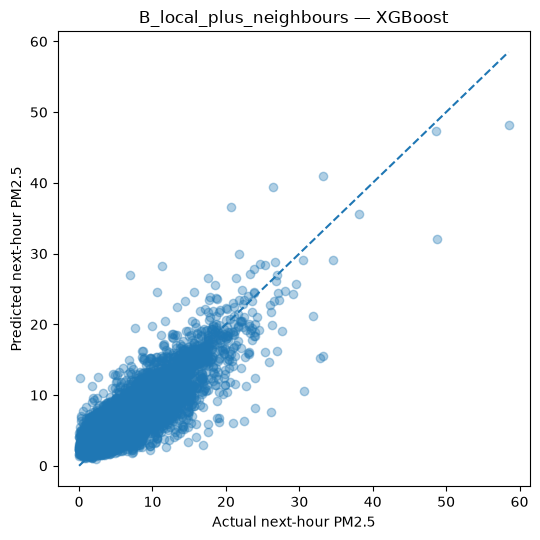

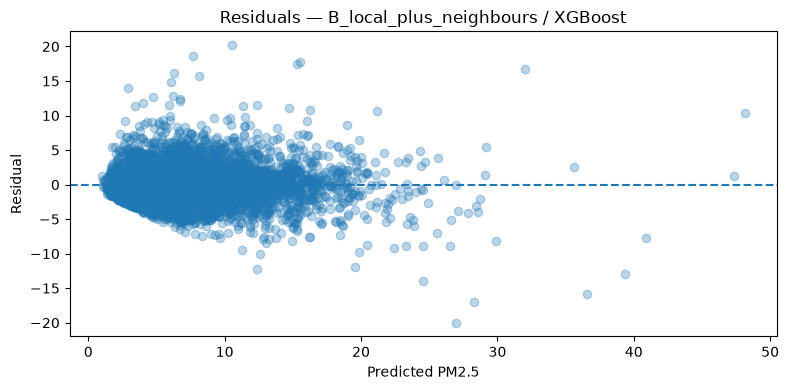

In [34]:
def actual_vs_pred_plot(y_true,y_pred,title):
    y_true,y_pred=safe_pairs(y_true,y_pred); plt.figure(figsize=(5.5,5.5)); plt.scatter(y_true,y_pred,alpha=.35); lo=min(y_true.min(),y_pred.min()); hi=max(y_true.max(),y_pred.max()); plt.plot([lo,hi],[lo,hi],"--"); plt.xlabel("Actual next-hour PM2.5"); plt.ylabel("Predicted next-hour PM2.5"); plt.title(title); plt.tight_layout(); plt.show()
def residual_plot(y_true,y_pred,title):
    y_true,y_pred=safe_pairs(y_true,y_pred); r=y_true-y_pred; plt.figure(figsize=(8,4)); plt.scatter(y_pred,r,alpha=.3); plt.axhline(0,linestyle="--"); plt.xlabel("Predicted PM2.5"); plt.ylabel("Residual"); plt.title(title); plt.tight_layout(); plt.show()
best = scenario_only.sort_values("RMSE_mean").iloc[0]

matching_keys = [
    key for key in prediction_store
    if key[0] == best.scenario
    and key[1] == best.model
]

if matching_keys:
    key = sorted(
        matching_keys,
        key=lambda item: (
            len(item),
            item[2] if len(item) > 2 else -1,
        ),
    )[0]

    yt, yp = prediction_store[key]

    actual_vs_pred_plot(
        yt,
        yp,
        f"{best.scenario} — {best.model}",
    )

    residual_plot(
        yt,
        yp,
        f"Residuals — {best.scenario} / {best.model}",
    )
else:
    print(
        "No stored prediction was found for:",
        best.scenario,
        best.model,
    )

### 12.4 Learning curves — explicit overfitting check

This is the main **tree-model overfitting diagnostic**.

```text
training RMSE very low
validation RMSE much higher
        -> possible overfitting
```

A healthier pattern is that validation RMSE improves and the training/validation gap narrows as more data are added.

The curves are averaged across multiple seeds and also report **validation R²**. Error bars are approximate 95% confidence intervals across seeds, consistent with the repeated-run uncertainty reporting used by Le et al. (2026).

,scenario,model,fraction,n_seeds,train_RMSE_mean,train_RMSE_ci95,validation_RMSE_mean,validation_RMSE_ci95,validation_R2_mean,validation_R2_ci95
0,A_local_only,RandomForest,0.25,30,3.009134,0.015520,3.133509,0.003379,0.755822,0.000527
1,A_local_only,RandomForest,0.50,30,2.664590,0.009118,3.086132,0.003811,0.763149,0.000585
2,A_local_only,RandomForest,0.75,30,2.355537,0.007982,3.016266,0.002682,0.773753,0.000402
3,A_local_only,RandomForest,1.00,30,2.153056,0.007461,3.004021,0.002666,0.775586,0.000398
4,A_local_only,XGBoost,0.25,30,2.257015,0.003763,3.081663,0.004719,0.763833,0.000724
5,A_local_only,XGBoost,0.50,30,2.380106,0.002248,2.975801,0.004388,0.779780,0.000650
6,A_local_only,XGBoost,0.75,30,2.289957,0.002087,2.979774,0.005237,0.779190,0.000776
7,A_local_only,XGBoost,1.00,30,2.187310,0.001884,2.852348,0.003868,0.797674,0.000549
8,B_local_plus_neighbours,RandomForest,0.25,30,2.966351,0.017785,3.144038,0.005007,0.754175,0.000782
9,B_local_plus_neighbours,RandomForest,0.50,30,2.627652,0.010852,3.143428,0.005890,0.754269,0.000920


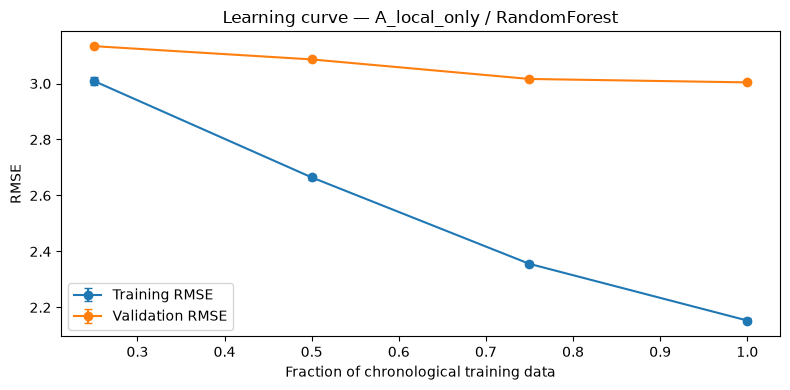

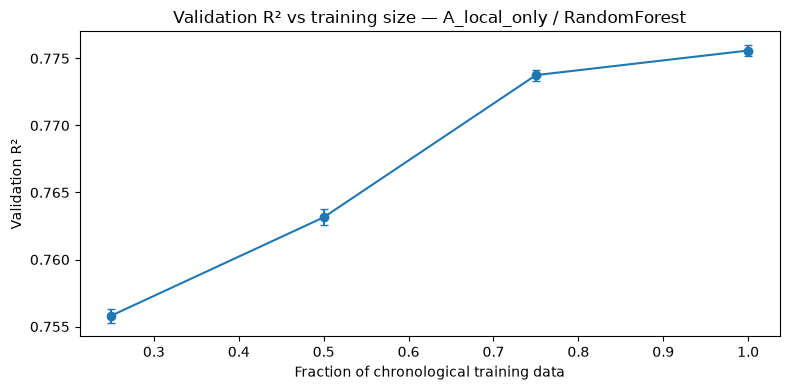

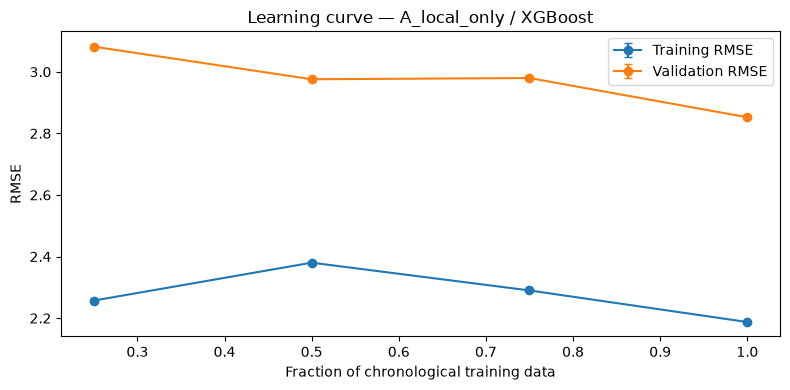

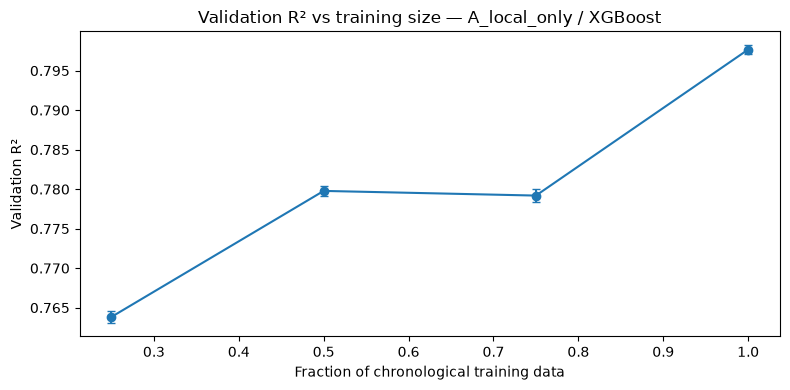

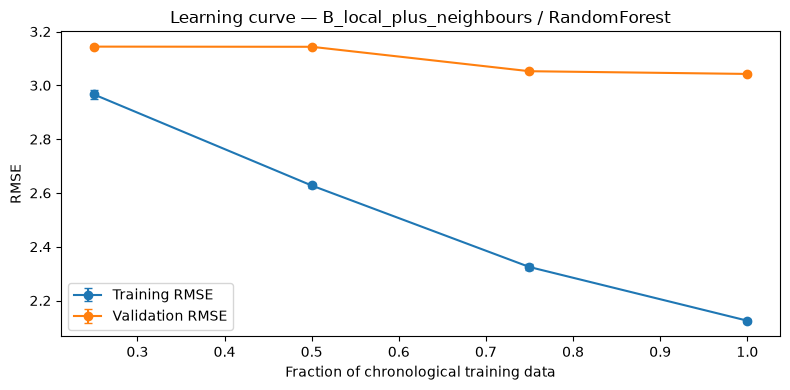

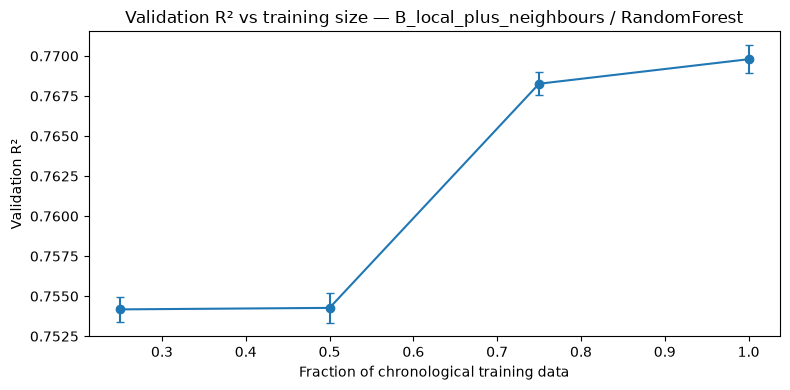

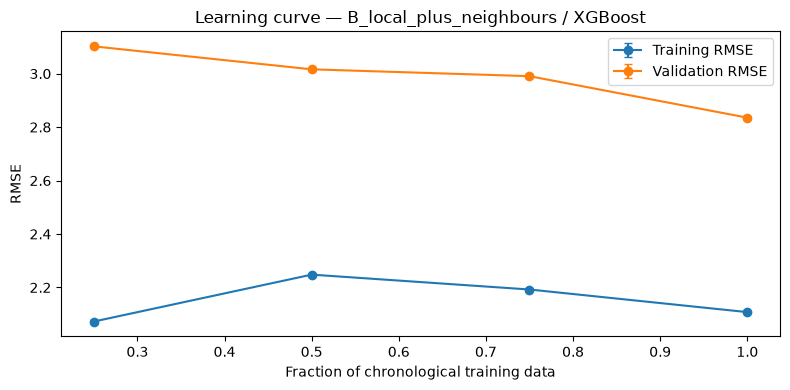

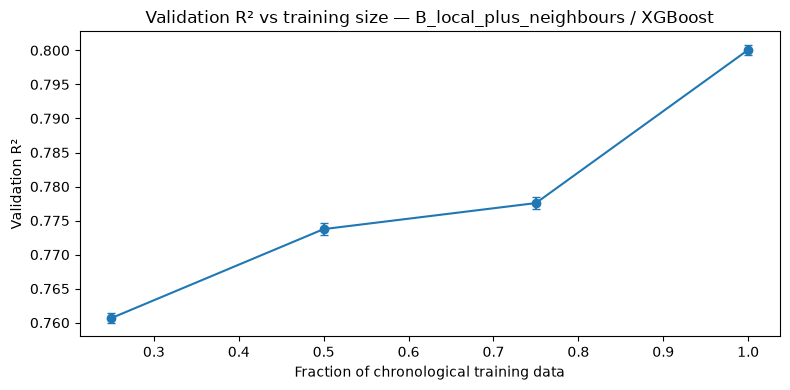

In [35]:
fractions = [0.25, 0.50, 0.75, 1.00]
learning_rows = []


def first_fraction(X, y, fraction):
    n = max(100, int(len(X) * fraction))
    return X.iloc[:n].copy(), y.iloc[:n].copy()


for scenario_name, Xtr, ytr, Xv, yv in [
    ("A_local_only", Xa_train, ya_train, Xa_val, ya_val),
    ("B_local_plus_neighbours", Xb_train, yb_train, Xb_val, yb_val),
]:
    for model_name, factory, params in [
        ("RandomForest", train_rf, RF_BEST_PARAMS),
        (xgb_name, train_xgb, XGB_BEST_PARAMS),
    ]:
        for seed in LEARNING_CURVE_SEEDS:
            for frac in fractions:
                Xs, ys = first_fraction(Xtr, ytr, frac)
                pipe, vpred, _ = run_tabular_model(factory(seed, params), Xs, ys, Xv)
                tpred = pipe.predict(Xs)

                train_metrics = regression_metrics(ys, tpred)
                val_metrics = regression_metrics(yv, vpred)

                learning_rows.append({
                    "scenario": scenario_name,
                    "model": model_name,
                    "seed": seed,
                    "fraction": frac,
                    "train_RMSE": train_metrics["RMSE"],
                    "validation_RMSE": val_metrics["RMSE"],
                    "validation_R2": val_metrics["R2"],
                })

learning_df = pd.DataFrame(learning_rows)
learning_df.to_csv(exports_dir / "learning_curve_runs.csv", index=False)

summary_rows = []
for (scenario, model, frac), group in learning_df.groupby(["scenario", "model", "fraction"]):
    row = {"scenario": scenario, "model": model, "fraction": frac, "n_seeds": len(group)}

    for metric in ["train_RMSE", "validation_RMSE", "validation_R2"]:
        mean = group[metric].mean()
        std = group[metric].std(ddof=1)
        ci = 1.96 * std / np.sqrt(len(group)) if len(group) > 1 else np.nan
        row[f"{metric}_mean"] = mean
        row[f"{metric}_ci95"] = ci

    summary_rows.append(row)

learning_summary = pd.DataFrame(summary_rows)
display(learning_summary)
learning_summary.to_csv(exports_dir / "learning_curve_summary.csv", index=False)

for (scenario_name, model_name), temp in learning_summary.groupby(["scenario", "model"]):
    temp = temp.sort_values("fraction")

    plt.figure(figsize=(8, 4))
    plt.errorbar(
        temp["fraction"],
        temp["train_RMSE_mean"],
        yerr=temp["train_RMSE_ci95"].fillna(0),
        marker="o",
        capsize=3,
        label="Training RMSE",
    )
    plt.errorbar(
        temp["fraction"],
        temp["validation_RMSE_mean"],
        yerr=temp["validation_RMSE_ci95"].fillna(0),
        marker="o",
        capsize=3,
        label="Validation RMSE",
    )
    plt.xlabel("Fraction of chronological training data")
    plt.ylabel("RMSE")
    plt.title(f"Learning curve — {scenario_name} / {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.errorbar(
        temp["fraction"],
        temp["validation_R2_mean"],
        yerr=temp["validation_R2_ci95"].fillna(0),
        marker="o",
        capsize=3,
    )
    plt.xlabel("Fraction of chronological training data")
    plt.ylabel("Validation R²")
    plt.title(f"Validation R² vs training size — {scenario_name} / {model_name}")
    plt.tight_layout()
    plt.show()


### 12.4.1 LSTM/GRU training vs validation loss

For neural networks, overfitting can appear when **training loss keeps falling while validation loss starts rising**. Early stopping is used to restore the weights from the best validation epoch.

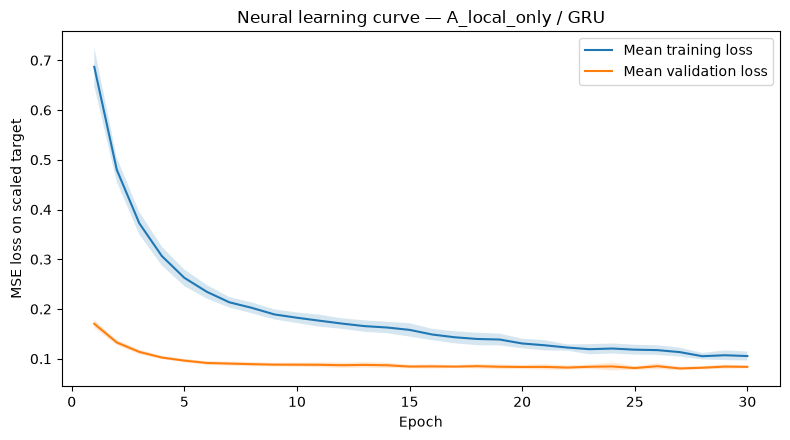

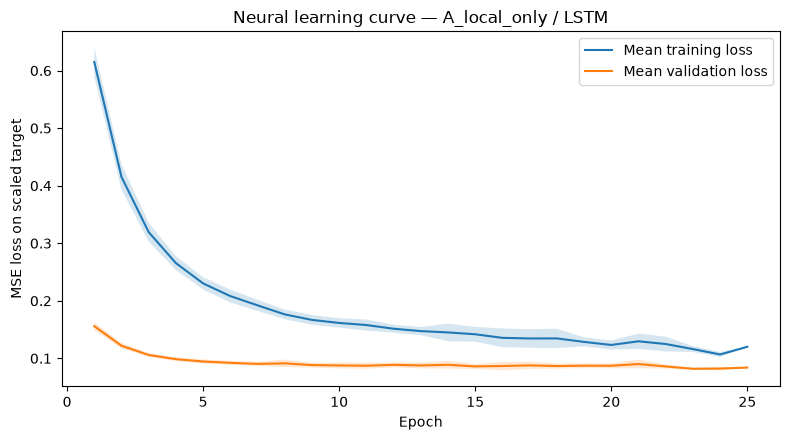

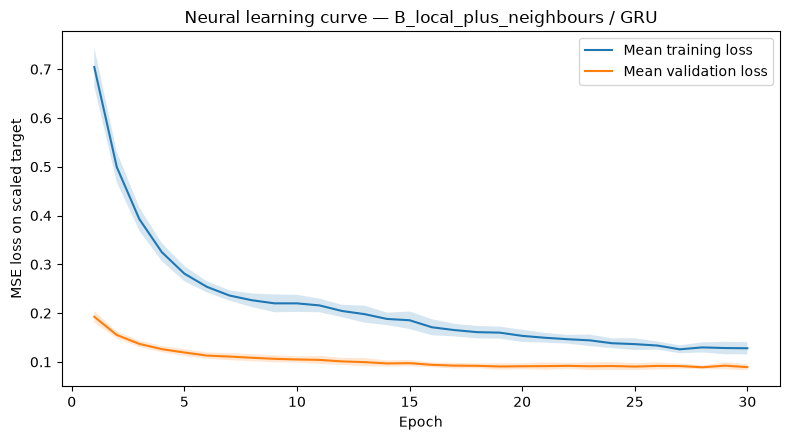

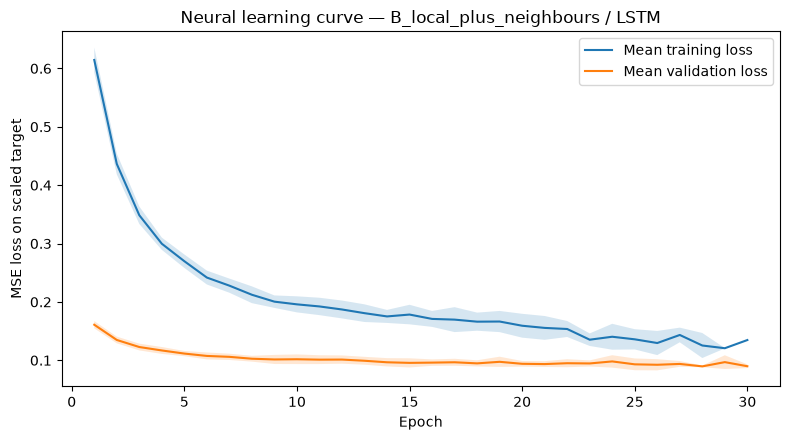

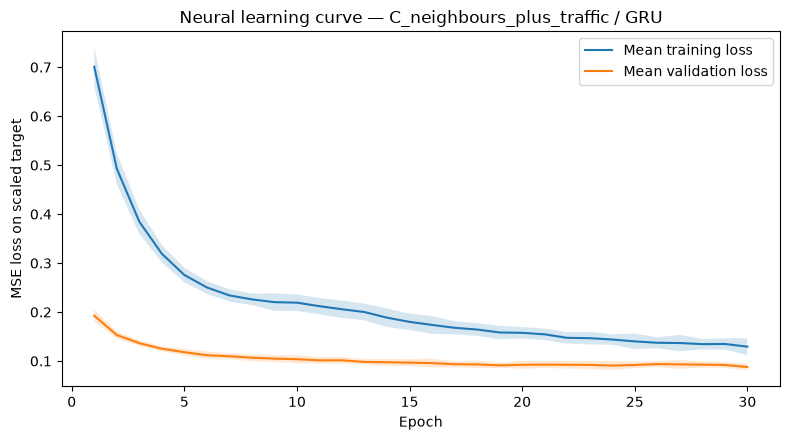

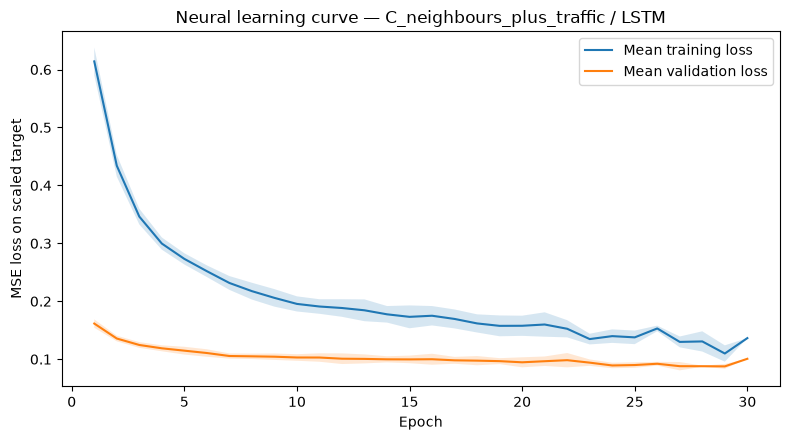

,scenario,model,runs,mean_epochs,std_epochs,mean_best_epoch,std_best_epoch
0,A_local_only,GRU,30,21.233333,5.667106,16.500000,6.134976
1,A_local_only,LSTM,30,17.600000,3.765543,12.600000,3.765543
2,B_local_plus_neighbours,GRU,30,25.800000,4.596850,21.633333,5.567661
3,B_local_plus_neighbours,LSTM,30,20.166667,4.418483,15.166667,4.418483
4,C_neighbours_plus_traffic,GRU,30,24.033333,4.429395,19.300000,4.857628
5,C_neighbours_plus_traffic,LSTM,30,19.833333,4.594474,14.966667,4.944404


In [36]:
# ===============================================================
# 12.4.1 LSTM / GRU AGGREGATED LEARNING CURVES
# ===============================================================

if DEEP_HISTORY_FILE.exists():

    deep_history_df = pd.read_csv(
        DEEP_HISTORY_FILE
    )

    deep_curve_summary = (
        deep_history_df
        .groupby(
            [
                "scenario",
                "model",
                "epoch",
            ],
            as_index=False,
        )
        .agg(
            train_loss_mean=("loss", "mean"),
            train_loss_std=("loss", "std"),
            validation_loss_mean=(
                "val_loss",
                "mean",
            ),
            validation_loss_std=(
                "val_loss",
                "std",
            ),
            n_seeds=("seed", "nunique"),
        )
    )

    for (
        scenario_name,
        model_name,
    ), group in deep_curve_summary.groupby(
        ["scenario", "model"]
    ):

        group = group.sort_values("epoch")

        epochs = group["epoch"].to_numpy()

        train_mean = group[
            "train_loss_mean"
        ].to_numpy()

        train_std = (
            group["train_loss_std"]
            .fillna(0)
            .to_numpy()
        )

        val_mean = group[
            "validation_loss_mean"
        ].to_numpy()

        val_std = (
            group["validation_loss_std"]
            .fillna(0)
            .to_numpy()
        )

        plt.figure(figsize=(8, 4.5))

        plt.plot(
            epochs,
            train_mean,
            label="Mean training loss",
        )

        plt.fill_between(
            epochs,
            train_mean - train_std,
            train_mean + train_std,
            alpha=0.18,
        )

        plt.plot(
            epochs,
            val_mean,
            label="Mean validation loss",
        )

        plt.fill_between(
            epochs,
            val_mean - val_std,
            val_mean + val_std,
            alpha=0.18,
        )

        plt.xlabel("Epoch")
        plt.ylabel(
            "MSE loss on scaled target"
        )

        plt.title(
            f"Neural learning curve — "
            f"{scenario_name} / {model_name}"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    deep_curve_summary.to_csv(
        exports_dir
        / "deep_learning_curve_summary.csv",
        index=False,
    )

    deep_run_summary = (
        pd.read_csv(DEEP_RESULTS_FILE)
        .groupby(
            ["scenario", "model"],
            as_index=False,
        )
        .agg(
            runs=("seed", "nunique"),
            mean_epochs=(
                "epochs_ran",
                "mean",
            ),
            std_epochs=(
                "epochs_ran",
                "std",
            ),
            mean_best_epoch=(
                "best_epoch",
                "mean",
            ),
            std_best_epoch=(
                "best_epoch",
                "std",
            ),
        )
    )

    display(deep_run_summary)

    deep_run_summary.to_csv(
        exports_dir
        / "deep_training_run_summary.csv",
        index=False,
    )

else:
    print(
        "No deep-learning history checkpoint found."
    )

### 12.5 Scenario significance tests

In [ ]:
# ===============================================================
# 12.5 PAIRED SCENARIO SIGNIFICANCE TESTS
# RF, XGBoost, LSTM and GRU
# ===============================================================

significance_rows = []

seed_df = all_runs_df[
    all_runs_df["seed"].notna()
].copy()

seed_df["seed"] = (
    seed_df["seed"].astype(int)
)

models_for_significance = [
    "RandomForest",
    xgb_name,
    "LSTM",
    "GRU",
]

comparisons = [
    (
        "A_local_only",
        "B_local_plus_neighbours",
        "B vs A",
    ),
    (
        "B_local_plus_neighbours",
        "C_neighbours_plus_traffic",
        "C vs B",
    ),
]

if HAS_SCIPY:

    for model_name in models_for_significance:

        model_runs = seed_df[
            seed_df["model"] == model_name
        ]

        for (
            before,
            after,
            label,
        ) in comparisons:

            paired = model_runs.pivot_table(
                index="seed",
                columns="scenario",
                values="RMSE",
                aggfunc="mean",
            )

            if (
                before not in paired.columns
                or after not in paired.columns
            ):
                continue

            paired = paired[
                [before, after]
            ].dropna()

            if len(paired) < 2:
                continue

            t_stat, t_p = ttest_rel(
                paired[before],
                paired[after],
            )

            try:
                w_stat, w_p = wilcoxon(
                    paired[before],
                    paired[after],
                )
            except Exception:
                w_stat = np.nan
                w_p = np.nan

            before_mean = paired[
                before
            ].mean()

            after_mean = paired[
                after
            ].mean()

            improvement_pct = (
                (before_mean - after_mean)
                / before_mean
                * 100
            )

            significance_rows.append({
                "model": model_name,
                "comparison": label,
                "n_pairs": len(paired),
                "mean_before": before_mean,
                "mean_after": after_mean,
                "RMSE_improvement_pct": (
                    improvement_pct
                ),
                "paired_t_statistic": t_stat,
                "paired_t_p": t_p,
                "wilcoxon_statistic": w_stat,
                "wilcoxon_p": w_p,
            })

significance_df = pd.DataFrame(
    significance_rows
)

display(significance_df)

significance_df.to_csv(
    exports_dir
    / "scenario_significance_tests.csv",
    index=False,
)

,model,comparison,n_pairs,mean_before,mean_after,RMSE_improvement_pct,paired_t_statistic,paired_t_p,wilcoxon_statistic,wilcoxon_p
0,RandomForest,B vs A,30,2.409807,2.403992,0.241272,9.659289,1.440468e-10,5.0,1.862645e-08
1,RandomForest,C vs B,30,2.403992,2.406333,-0.097367,-3.114357,4.125694e-03,95.0,3.744433e-03
2,XGBoost,B vs A,30,2.380324,2.372428,0.331739,6.102634,1.202367e-06,30.0,3.790483e-06
3,XGBoost,C vs B,30,2.372428,2.374238,-0.076296,-1.294600,2.056720e-01,164.0,1.641841e-01
4,LSTM,B vs A,30,2.526096,2.585734,-2.360911,-4.311841,1.705692e-04,63.0,2.316367e-04
5,LSTM,C vs B,30,2.585734,2.585659,0.002910,0.005384,9.957413e-01,227.0,9.192965e-01
6,GRU,B vs A,30,2.580662,2.568072,0.487843,0.809584,4.247725e-01,187.0,3.598779e-01
7,GRU,C vs B,30,2.568072,2.577494,-0.366888,-0.574372,5.701451e-01,198.0,4.898461e-01


### 12.5.1 Holm correction for multiple comparisons

The scenario comparisons involved eight related hypothesis tests for each test family. Holm correction was therefore applied separately to the paired t-test and Wilcoxon p-values to control the family-wise error rate. The correction used the existing 30-seed results and did not require model retraining.

In [2]:
# ===============================================================
# 12.5.1 HOLM MULTIPLE-COMPARISON CORRECTION
# Uses existing exported significance results; no model rerun needed
# ===============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests


# Recreate the export path so this cell can run after restarting the kernel.
holm_exports_dir = (
    Path(".")
    / "data"
    / "exports"
    / "research_final_all_predictors"
)

significance_file = (
    holm_exports_dir
    / "scenario_significance_tests.csv"
)


# Prefer the in-memory result when available.
# Otherwise, restore the previously exported results.
if "significance_df" in globals() and not significance_df.empty:
    significance_holm_df = significance_df.copy()
    print("Using significance_df from the current notebook session.")

elif significance_file.exists():
    significance_holm_df = pd.read_csv(significance_file)
    print("Loaded existing significance results from:")
    print(significance_file.resolve())

else:
    raise FileNotFoundError(
        "scenario_significance_tests.csv was not found. "
        "Check that the notebook is opened from the project root and "
        "that the data/exports/research_final_all_predictors folder "
        "is still available."
    )


def add_holm_correction(
    table,
    raw_p_column,
    adjusted_p_column,
    decision_column,
    alpha=0.05,
):
    """
    Apply Holm correction to one family of p-values.

    Missing p-values are excluded from correction and remain missing.
    """

    adjusted = pd.Series(
        np.nan,
        index=table.index,
        dtype=float,
    )

    rejected = pd.Series(
        False,
        index=table.index,
        dtype=bool,
    )

    valid = table[raw_p_column].notna()

    if valid.any():
        reject, corrected_p, _, _ = multipletests(
            table.loc[valid, raw_p_column].astype(float),
            alpha=alpha,
            method="holm",
        )

        adjusted.loc[valid] = corrected_p
        rejected.loc[valid] = reject

    table[adjusted_p_column] = adjusted
    table[decision_column] = rejected

    return table


# Treat the eight paired t-tests as one comparison family.
significance_holm_df = add_holm_correction(
    significance_holm_df,
    raw_p_column="paired_t_p",
    adjusted_p_column="paired_t_p_holm",
    decision_column="paired_t_significant_holm",
)

# Treat the eight Wilcoxon tests as a separate comparison family.
significance_holm_df = add_holm_correction(
    significance_holm_df,
    raw_p_column="wilcoxon_p",
    adjusted_p_column="wilcoxon_p_holm",
    decision_column="wilcoxon_significant_holm",
)


holm_display_columns = [
    "model",
    "comparison",
    "n_pairs",
    "mean_before",
    "mean_after",
    "RMSE_improvement_pct",
    "paired_t_p",
    "paired_t_p_holm",
    "paired_t_significant_holm",
    "wilcoxon_p",
    "wilcoxon_p_holm",
    "wilcoxon_significant_holm",
]

display(
    significance_holm_df[
        holm_display_columns
    ]
)


holm_output_file = (
    holm_exports_dir
    / "scenario_significance_tests_holm.csv"
)

significance_holm_df.to_csv(
    holm_output_file,
    index=False,
)

print("Holm-corrected results saved to:")
print(holm_output_file.resolve())

c:\Users\MSI\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\MSI\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Loaded existing significance results from:
C:\Users\MSI\Desktop\Research Perp\Code\data\exports\research_final_all_predictors\scenario_significance_tests.csv


,model,comparison,n_pairs,mean_before,mean_after,RMSE_improvement_pct,paired_t_p,paired_t_p_holm,paired_t_significant_holm,wilcoxon_p,wilcoxon_p_holm,wilcoxon_significant_holm
0,RandomForest,B vs A,30,2.409807,2.403992,0.241272,1.440468e-10,1.152374e-09,True,1.862645e-08,1.490116e-07,True
1,RandomForest,C vs B,30,2.403992,2.406333,-0.097367,4.125694e-03,2.062847e-02,True,3.744433e-03,1.872216e-02,True
2,XGBoost,B vs A,30,2.380324,2.372428,0.331739,1.202367e-06,8.416569e-06,True,3.790483e-06,2.653338e-05,True
3,XGBoost,C vs B,30,2.372428,2.374238,-0.076296,2.056720e-01,8.226880e-01,False,1.641841e-01,6.567363e-01,False
4,LSTM,B vs A,30,2.526096,2.585734,-2.360911,1.705692e-04,1.023415e-03,True,2.316367e-04,1.389820e-03,True
5,LSTM,C vs B,30,2.585734,2.585659,0.002910,9.957413e-01,1.000000e+00,False,9.192965e-01,1.000000e+00,False
6,GRU,B vs A,30,2.580662,2.568072,0.487843,4.247725e-01,1.000000e+00,False,3.598779e-01,1.000000e+00,False
7,GRU,C vs B,30,2.568072,2.577494,-0.366888,5.701451e-01,1.000000e+00,False,4.898461e-01,1.000000e+00,False


Holm-corrected results saved to:
C:\Users\MSI\Desktop\Research Perp\Code\data\exports\research_final_all_predictors\scenario_significance_tests_holm.csv


## 13. Feature importance and XAI

### Why this matters
Prediction accuracy tells us **how well** a model forecasts PM2.5, but the capstone also asks **which information the model relies on**.

We therefore use complementary analyses:

- **Correlation:** how two measured variables move together.
- **Model feature importance:** how much the fitted model relies on each input.
- **SHAP:** whether a feature pushes individual predictions higher or lower, and by how much.

These indicate predictive relationships. They should not be described as proof that one variable directly *causes* PM2.5 changes.

,feature,importance_mean,importance_std
231,ROZELLE_PM25,0.542564,0.016066
217,ROZELLE_PM10,0.144176,0.010554
239,ROZELLE_PM25_ROLL_MEAN_3,0.059380,0.008122
123,RANDWICK_PM25,0.021567,0.004509
163,ROZELLE_CO,0.018416,0.001685
225,ROZELLE_PM10_ROLL_MEAN_3,0.012329,0.004983
297,ST_MARYS_PM10,0.007964,0.002718
87,NEIGHBOR_MEAN_PM25,0.007194,0.001455
281,ROZELLE_WSP_ROLL_STD_24,0.007110,0.002408
240,ROZELLE_PM25_ROLL_MEAN_6,0.006482,0.001953


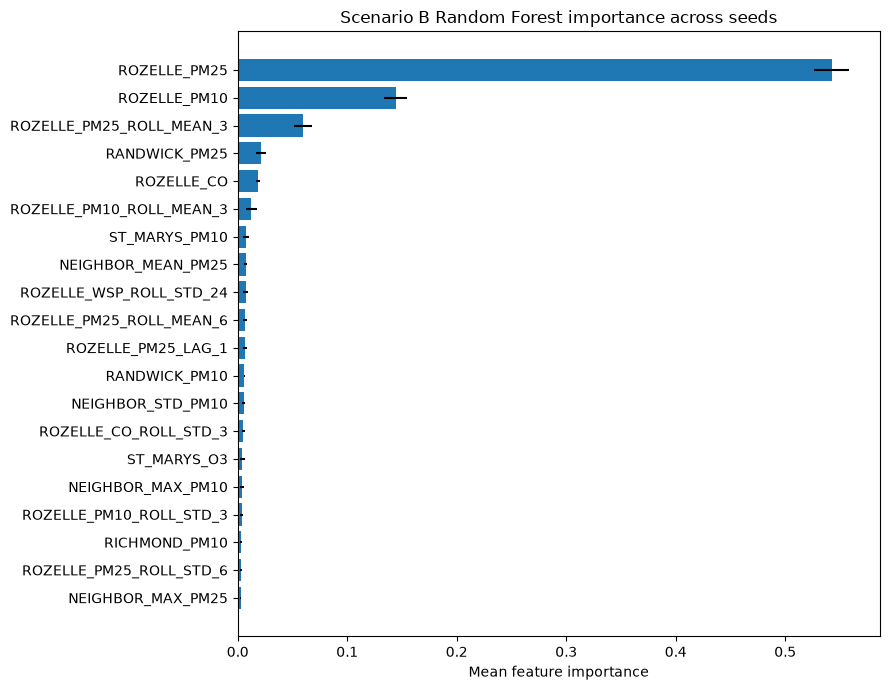

In [ ]:
fi=[]
for seed in SEEDS:
    pipe,_,_=run_tabular_model(train_rf(seed, RF_BEST_PARAMS),Xb_train,yb_train,Xb_test); model=pipe.named_steps["model"]
    for feature,importance in zip(Xb_train.columns,model.feature_importances_): fi.append({"seed":seed,"feature":feature,"importance":importance})
fi_df=pd.DataFrame(fi); fi_summary=fi_df.groupby("feature",as_index=False).agg(importance_mean=("importance","mean"),importance_std=("importance","std")).sort_values("importance_mean",ascending=False); display(fi_summary.head(25)); fi_summary.to_csv(exports_dir / "rf_feature_importance_across_seeds.csv",index=False)
top=fi_summary.head(20).sort_values("importance_mean"); plt.figure(figsize=(9,7)); plt.barh(top["feature"],top["importance_mean"],xerr=top["importance_std"].fillna(0)); plt.xlabel("Mean feature importance"); plt.title("Scenario B Random Forest importance across seeds"); plt.tight_layout(); plt.show()

### 13.1 SHAP — why this XAI method is used

SHAP is the only XAI method implemented in the main experiment.

The research question requires more than explaining one isolated prediction. It asks which **local pollution, meteorological, neighbouring and contextual variables are consistently important across the test data**.

SHAP is used because it provides:

1. **global evidence** — mean absolute SHAP values rank influential predictors across many observations;
2. **local evidence** — an individual forecast can be decomposed into positive and negative feature contributions;
3. **directional evidence** — SHAP values show whether a feature pushes a prediction upward or downward;
4. **stability evidence** — feature attributions can be aggregated across repeated random seeds;
5. **efficient tree-model explanation** — TreeSHAP is directly suited to RF/XGBoost-style tree ensembles.

LIME is not implemented because its original purpose is primarily **local surrogate explanation around an individual observation**, and its explanation depends on the locally sampled/perturbed neighbourhood. That is useful for case-level explanation, but it is less direct for the main objective here: producing a stable global comparison of predictive factors across the test set and repeated runs.

**Evidence basis**
- Ribeiro, Singh & Guestrin (2016): LIME explains an individual prediction using a locally interpretable surrogate model.
- Lundberg & Lee (2017): SHAP provides additive feature-attribution values with consistency properties.
- Le et al. (2026) use SHAP for global air-quality feature attribution and repeated-run uncertainty reporting.
- Yenkikar et al. (2025) use SHAP with the RF–ARIMA air-quality framework.

SHAP explains **model behaviour**, not environmental causation.

```text
baseline prediction
+ positive SHAP contributions
- negative SHAP contributions
= final model prediction
```

The notebook reports:
- mean |SHAP| across seeds;
- SHAP standard deviation across seeds;
- beeswarm direction/spread;
- feature-value vs SHAP directional association;
- one high-PM2.5 local explanation.

SHAP model: B_local_plus_neighbours / XGBoost
Mean absolute SHAP influence across seeds:


,feature,mean_abs_shap,std_abs_shap
231,ROZELLE_PM25,2.260471,0.046693
217,ROZELLE_PM10,0.763720,0.009697
163,ROZELLE_CO,0.307791,0.005938
232,ROZELLE_PM25_LAG_1,0.238131,0.022606
87,NEIGHBOR_MEAN_PM25,0.183376,0.009039
190,ROZELLE_NO2,0.168778,0.003202
239,ROZELLE_PM25_ROLL_MEAN_3,0.133598,0.069651
238,ROZELLE_PM25_ROLL_MEAN_24,0.118033,0.009967
33,HOUR_COS,0.093952,0.004464
309,ST_MARYS_TEMP,0.085646,0.006469


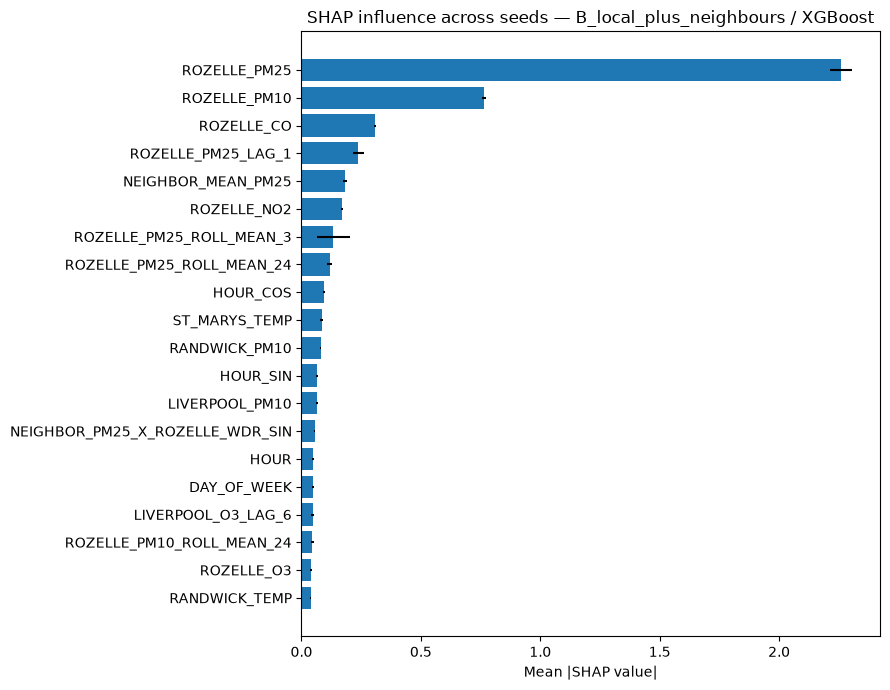

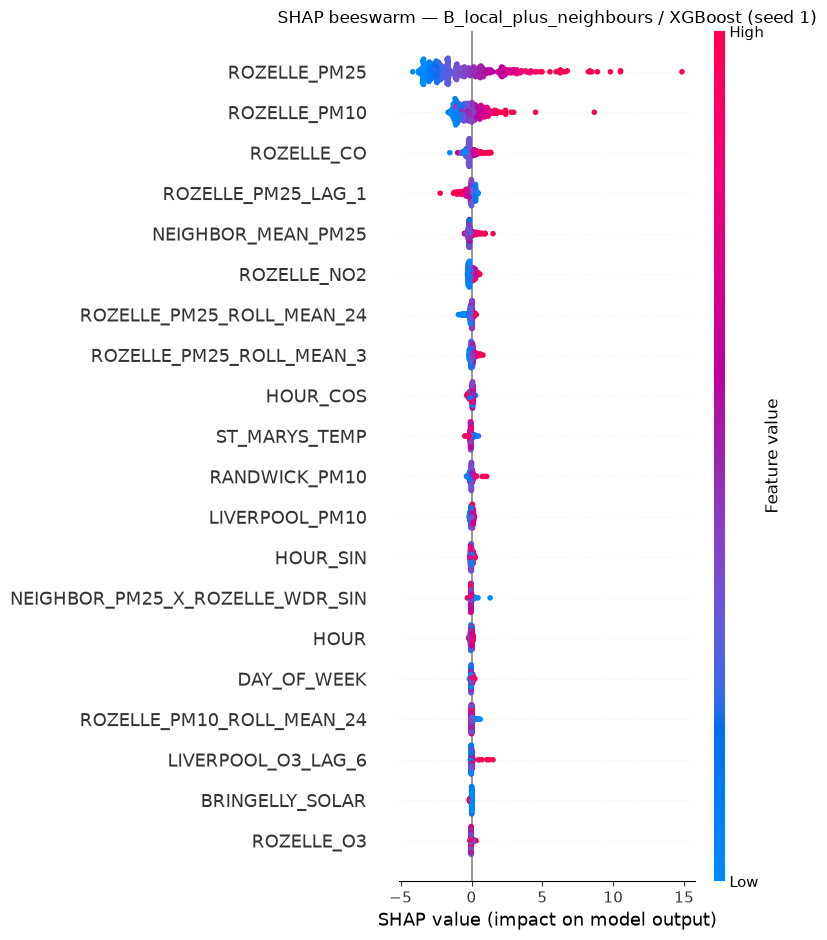

Directional SHAP evidence:


,feature,mean_abs_shap,feature_value_vs_shap_spearman,interpretation
3,ROZELLE_PM25,2.292997,0.996785,Higher values generally push prediction upward
4,ROZELLE_PM10,0.755848,0.949859,Higher values generally push prediction upward
7,ROZELLE_CO,0.312709,0.879602,Higher values generally push prediction upward
83,ROZELLE_PM25_LAG_1,0.235013,-0.977606,Higher values generally push prediction downward
179,NEIGHBOR_MEAN_PM25,0.186090,0.728006,Higher values generally push prediction upward
8,ROZELLE_NO2,0.167110,0.947193,Higher values generally push prediction upward
27,ROZELLE_PM25_ROLL_MEAN_24,0.122042,0.877161,Higher values generally push prediction upward
21,ROZELLE_PM25_ROLL_MEAN_3,0.114481,0.928928,Higher values generally push prediction upward
14,HOUR_COS,0.097198,-0.104641,Mixed / non-linear directional effect
154,ST_MARYS_TEMP,0.089423,-0.702418,Higher values generally push prediction downward


Local SHAP example — high actual PM2.5 case
Actual PM2.5: 25.3


,feature,feature_value_after_preprocessing,shap_contribution,abs_shap
3,ROZELLE_PM25,18.200000,9.797589,9.797589
4,ROZELLE_PM10,171.800000,8.662152,8.662152
30,ROZELLE_PM10_ROLL_STD_3,84.480846,1.721631,1.721631
7,ROZELLE_CO,0.300000,-0.964934,0.964934
83,ROZELLE_PM25_LAG_1,12.900000,-0.621441,0.621441
179,NEIGHBOR_MEAN_PM25,17.520000,0.574366,0.574366
154,ST_MARYS_TEMP,13.150000,0.492826,0.492826
21,ROZELLE_PM25_ROLL_MEAN_3,14.633333,0.361994,0.361994
180,NEIGHBOR_MAX_PM25,41.800000,0.351871,0.351871
13,HOUR_SIN,0.965926,0.266183,0.266183


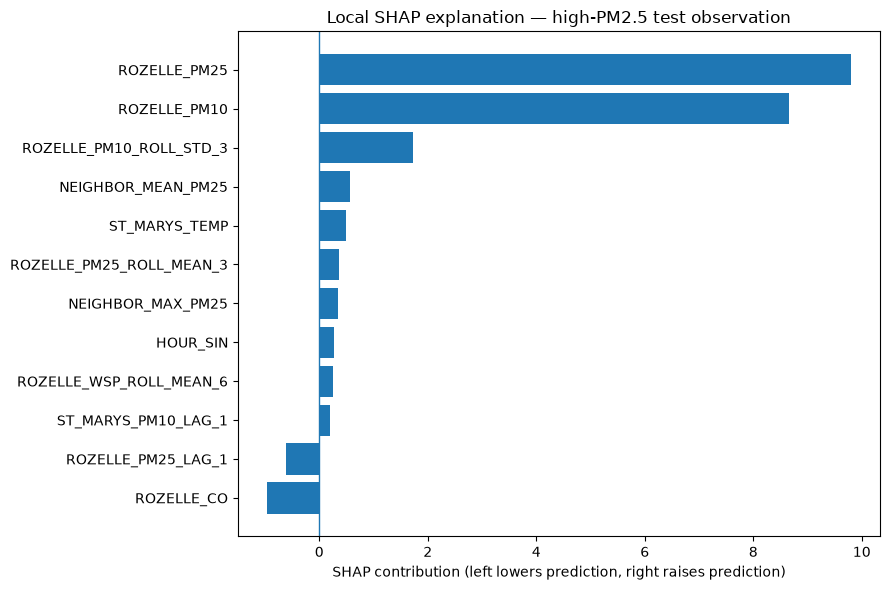

In [ ]:
if HAS_SHAP:
    candidates = scenario_only[
        scenario_only["model"].isin(["RandomForest", "XGBoost", "HistGradientBoosting"])
    ].sort_values("RMSE_mean")

    if len(candidates):
        row = candidates.iloc[0]
        sc = row.scenario
        model_name = row.model

        if sc == "A_local_only":
            Xtr, ytr, Xv, yv, Xte, yte = Xa_train, ya_train, Xa_val, ya_val, Xa_test, ya_test
        elif sc == "B_local_plus_neighbours":
            Xtr, ytr, Xv, yv, Xte, yte = Xb_train, yb_train, Xb_val, yb_val, Xb_test, yb_test
        else:
            Xtr, ytr, Xv, yv, Xte, yte = Xc_train, yc_train, Xc_val, yc_val, Xc_test, yc_test

        Xtrainval = pd.concat([Xtr, Xv], axis=0).reset_index(drop=True)
        ytrainval = pd.concat([ytr, yv], axis=0).reset_index(drop=True)

        sample = Xte.sample(min(400, len(Xte)), random_state=42)
        sample_y = yte.loc[sample.index]

        shap_seed_rows = []
        shap_arrays = {}
        transformed_arrays = {}

        for seed in SHAP_SEEDS:
            if model_name == "XGBoost" and HAS_XGBOOST:
                factory_model = train_xgb(seed, XGB_BEST_PARAMS)
            else:
                factory_model = train_rf(seed, RF_BEST_PARAMS)

            pipe, _, _ = run_tabular_model(factory_model, Xtrainval, ytrainval, sample)
            transformed = pipe.named_steps["imputer"].transform(sample)
            arr = np.asarray(transformed, dtype=float)
            model = pipe.named_steps["model"]

            if model_name == "XGBoost" and HAS_XGBOOST:
                dm = xgb.DMatrix(arr, feature_names=list(sample.columns))
                contributions = model.get_booster().predict(dm, pred_contribs=True)
                vals = contributions[:, :-1]
            else:
                vals = np.asarray(shap.TreeExplainer(model).shap_values(arr))

            shap_arrays[seed] = vals
            transformed_arrays[seed] = arr

            for feature, importance in zip(sample.columns, np.mean(np.abs(vals), axis=0)):
                shap_seed_rows.append({
                    "seed": seed,
                    "feature": feature,
                    "mean_abs_shap": float(importance),
                })

        shap_seed_df = pd.DataFrame(shap_seed_rows)
        shap_summary_df = (
            shap_seed_df.groupby("feature", as_index=False)
            .agg(
                mean_abs_shap=("mean_abs_shap", "mean"),
                std_abs_shap=("mean_abs_shap", "std"),
            )
            .sort_values("mean_abs_shap", ascending=False)
        )

        print("SHAP model:", sc, "/", model_name)
        print("Mean absolute SHAP influence across seeds:")
        display(shap_summary_df.head(25))
        shap_summary_df.to_csv(exports_dir / "shap_mean_abs_across_seeds.csv", index=False)

        top = shap_summary_df.head(20).sort_values("mean_abs_shap")
        plt.figure(figsize=(9, 7))
        plt.barh(
            top["feature"],
            top["mean_abs_shap"],
            xerr=top["std_abs_shap"].fillna(0),
        )
        plt.xlabel("Mean |SHAP value|")
        plt.title(f"SHAP influence across seeds — {sc} / {model_name}")
        plt.tight_layout()
        plt.show()

        representative_seed = next(iter(shap_arrays))
        rep_vals = shap_arrays[representative_seed]
        rep_X = transformed_arrays[representative_seed]

        shap.summary_plot(
            rep_vals,
            rep_X,
            feature_names=sample.columns,
            show=False,
        )
        plt.title(f"SHAP beeswarm — {sc} / {model_name} (seed {representative_seed})")
        plt.tight_layout()
        plt.show()

        # Directional evidence: positive rho means higher feature values generally
        # correspond to more positive SHAP contributions.
        direction_rows = []
        for i, feature in enumerate(sample.columns):
            rho = pd.Series(rep_X[:, i]).corr(pd.Series(rep_vals[:, i]), method="spearman")

            if pd.isna(rho):
                interpretation = "No clear direction"
            elif rho >= 0.20:
                interpretation = "Higher values generally push prediction upward"
            elif rho <= -0.20:
                interpretation = "Higher values generally push prediction downward"
            else:
                interpretation = "Mixed / non-linear directional effect"

            direction_rows.append({
                "feature": feature,
                "mean_abs_shap": float(np.mean(np.abs(rep_vals[:, i]))),
                "feature_value_vs_shap_spearman": rho,
                "interpretation": interpretation,
            })

        shap_direction_df = pd.DataFrame(direction_rows).sort_values("mean_abs_shap", ascending=False)
        print("Directional SHAP evidence:")
        display(shap_direction_df.head(20))
        shap_direction_df.to_csv(exports_dir / "shap_directional_evidence.csv", index=False)

        # Local explanation: choose one high actual-PM2.5 case from the SHAP sample.
        high_pos = int(np.argmax(sample_y.values))
        local = pd.DataFrame({
            "feature": sample.columns,
            "feature_value_after_preprocessing": rep_X[high_pos],
            "shap_contribution": rep_vals[high_pos],
        })
        local["abs_shap"] = local["shap_contribution"].abs()
        local = local.sort_values("abs_shap", ascending=False).head(12)

        print("Local SHAP example — high actual PM2.5 case")
        print("Actual PM2.5:", float(sample_y.iloc[high_pos]))
        display(local)

        local_plot = local.sort_values("shap_contribution")
        plt.figure(figsize=(9, 6))
        plt.barh(local_plot["feature"], local_plot["shap_contribution"])
        plt.axvline(0, linewidth=1)
        plt.xlabel("SHAP contribution (left lowers prediction, right raises prediction)")
        plt.title("Local SHAP explanation — high-PM2.5 test observation")
        plt.tight_layout()
        plt.show()
else:
    print("SHAP unavailable")


## 14. Research-methodology map

The final pipeline is:

1. **Data audit and physical validity** — inspect missingness/gaps; only impossible measurements become missing.
2. **Leakage-safe filling** — complete gaps of `<=3 h` are filled causally; remaining predictor medians are fitted on 2019–2022 TRAIN only.
3. **Extreme screening** — TRAIN-derived IQR flags candidates across all six stations.
4. **Outlier ablation** — the same fixed RF compares KEEP, plain-IQR mask-all and coherence-aware MASK policies on 2023 validation RMSE.
5. **Feature engineering and A/B/C scenarios** — lags/rolling features are causal; neighbour and traffic information are added by scenario.
6. **Scenario-specific screening and shared tuning** — 2024 TEST data do not select features, preprocessing or hyperparameters.
7. **Final evaluation** — Persistence, ARIMA, RF, XGBoost, LSTM, GRU and RF→ARIMA; final RF/XGBoost results use 30 seeds and report mean ± std.
8. **Practical/XAI analysis** — TRAIN-p95 regression diagnostics, NSW Poor-or-worse hourly alert precision/recall, learning curves, significance tests and SHAP.

### Interpretation

- IQR identifies statistical candidates, not proven sensor errors.
- The fixed RF evaluates preprocessing policies; it is not the final tuned RF or an outlier detector.
- Correlation, feature importance and SHAP show predictive association/model reliance, not environmental causation.

### Methodology references used

- **Ghose, Rehena & Anthopoulos (2022):** 24-hour temporal context and neighbouring-station information.
- **Le et al. (2026):** chronological split, TRAIN-only scaling, repeated-run uncertainty, SHAP and health-alert framing.
- **Yenkikar et al. (2025):** RF→ARIMA residual correction and SHAP.
- **Lundberg & Lee (2017):** SHAP; **Ribeiro, Singh & Guestrin (2016):** LIME comparison.
- **NSW DCCEEW Air Quality Categories:** official one-hour PM2.5 thresholds for practical alert scoring.
